
<style>
.phnx-card {
    background: #f6f0e5;
    border: 1px solid #e2d6c4;
    border-left: 5px solid #a86f44;
    border-radius: 9px;
    padding: 14px 18px 12px 18px;
    margin: 8px 0 16px 0;
    line-height: 1.52;
    color: #2b2b2b;
}
.phnx-card h1, .phnx-card h2, .phnx-card h3, .phnx-card h4 {
    color: #253746;
    margin-top: 0.45em;
}
.phnx-card code {
    background: #fffaf1;
    padding: 1px 4px;
    border-radius: 4px;
}
.phnx-card blockquote {
    background: #fbf7ef;
    border-left: 4px solid #c59b72;
    margin-left: 0;
    padding: 8px 14px;
}
.phnx-formula {
    background: #fffaf2;
    border: 1px solid #e3d7c5;
    border-radius: 7px;
    padding: 9px 12px;
    margin: 10px auto;
    text-align: center;
    font-family: Georgia, "Times New Roman", serif;
    font-size: 1.08em;
    max-width: 92%;
}
.phnx-small {
    font-size: 0.92em;
    color: #5a5a5a;
}
</style>

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h1>Claims Reserving on Run-off Triangles — an explained notebook</h1>
<h3><code>reserving_triangles.ipynb</code> · v2.8.0</h3>
<p>Takes a <strong>loss development triangle</strong>, estimates the money an insurer still owes but hasn't paid (the <strong>reserve</strong>),
puts an honest distribution and a <strong>capital</strong> number (VaR / TVaR) around it, and <strong>backtests</strong> the prediction.</p>
<p><strong>Why it exists.</strong> §12 of the <strong>Car Insurance notebook</strong> hit a wall: <code>freMTPL2</code> is a <em>settled, one-year, fully-paid</em>
pricing dataset, so it structurally cannot show <strong>claims-development</strong> risk — the divergence <strong>Prof. Denuit</strong>
pointed at. Reserving is that missing piece; this notebook works on data that genuinely develops over time.</p>
<p><strong>Three layers.</strong> §1–§6 introduce classical triangle reserving on the canonical RAA example; §7 uses real CAS
Schedule-P data. §8 onward uses one <strong>SynthETIC transaction history</strong> as a controlled experiment: the paid triangle,
the claim-level RBNS/IBNR view, and the hidden future reserve all come from the <strong>same simulated claims</strong>. The bundled SynthETIC example uses quarterly periods, so four simulator periods are aggregated to one actuarial year. In v2.8.0 the micro model is upgraded with <strong>historical pseudo-valuations</strong>: older claims are viewed as they would have looked at earlier dates, allowing remaining RBNS cost and IBNR behavior to be learned without using the hidden future.</p>
<p><strong>Structure.</strong> All environment checks are in <strong>CELL 01</strong>; every input from the outside world is in <strong>CELL 02</strong>
and documented there. The rest of the notebook is pure computation.</p>
<p><strong>v2.8.0:</strong> after §17 diagnoses informative maturity censoring, §18 tests a censoring-aware inverse-probability-weighted RBNS regression. All explanatory Markdown is also rendered as styled HTML to avoid LaTeX-renderer problems.</p>

</div>

<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>Run switchboard</h2>
<p>This notebook contains the full research trail, including several deliberately retained failed model branches.
A kernel restart should not force every expensive experiment to run again.</p>

<p>Set the switches in the next cell before <strong>Run All</strong>. The default configuration runs the core paid
triangle work, the censoring diagnostics, and the new case-estimate/OCL study, while skipping the computationally
expensive paid-only model branches that have already served their diagnostic purpose.</p>

<p><strong>Important:</strong> skipped sections remain in the notebook as documented research evidence. Some later
sections depend on earlier objects; the case-estimate study has been written to be self-contained with respect to
<code>synthetic_transactions.csv</code> and <code>synthetic_incurred.csv</code>.</p>
</div>


In [1]:
# RUN SWITCHBOARD — edit these booleans before Run All

RUN_CORE_MACRO = True                  # RAA + SynthETIC annual triangle + Chain Ladder/Mack/bootstrap
RUN_BASE_MICRO = True                  # original age-aware complete-case micro model
RUN_ROLLING_BACKTEST = True            # years 6–10 best-estimate comparison
RUN_CENSORING_DIAGNOSTICS = True       # informative-censoring evidence

RUN_IPCW = False                       # failed correction; retained for research history
RUN_SURVIVAL_RATE = False              # failed duration × rate model
RUN_MEANFIELD_PROCESS = False          # catastrophically unstable recursive model
RUN_STOCHASTIC_PROCESS = False         # experimental stochastic-path branch

RUN_CASE_ESTIMATE_STUDY = True         # NEW: SPLICE OCL/incurred information axis
RUN_CASE_ROLLING = True                # rolling paid vs incurred / case-estimate comparisons
RUN_CASE_DIAGNOSTICS = True            # NEW: claim-level predictive value of OCL
RUN_OCL_RECALIBRATION = True          # §24: diagnose and safely recalibrate OCL
RUN_OCL_SMEARING = True              # §25: mean-correct log predictions by smearing
RUN_COMMON_WINDOW_HORSERACE = True    # §26: apples-to-apples years 7–10 comparison

print("Switchboard")
for name, value in sorted({
    k:v for k,v in globals().items()
    if k.startswith("RUN_") and isinstance(v, bool)
}.items()):
    print(f"  {name:30s} = {value}")

RUN_YEAR10_DIAGNOSTIC = True          # §28: anatomy of year-10 case-aware overshoot

RUN_LOG_RESIDUAL_DIAGNOSTIC = True    # §29: distinguish mean-function vs retransformation failure

RUN_INCREMENTAL_OCL_INFO = True       # §30: OCL incremental information diagnostic


Switchboard
  RUN_BASE_MICRO                 = True
  RUN_CASE_DIAGNOSTICS           = True
  RUN_CASE_ESTIMATE_STUDY        = True
  RUN_CASE_ROLLING               = True
  RUN_CENSORING_DIAGNOSTICS      = True
  RUN_COMMON_WINDOW_HORSERACE    = True
  RUN_CORE_MACRO                 = True
  RUN_IPCW                       = False
  RUN_MEANFIELD_PROCESS          = False
  RUN_OCL_RECALIBRATION          = True
  RUN_OCL_SMEARING               = True
  RUN_ROLLING_BACKTEST           = True
  RUN_STOCHASTIC_PROCESS         = False
  RUN_SURVIVAL_RATE              = False


In [2]:
# ══════════════════════════════════════════════════════════════════════
# CELL 01 · §0 · environment & version check             v0.3.0
# provides: np, pd, plt, stats, cl, scalar()   ·   requires: —
# ══════════════════════════════════════════════════════════════════════

import importlib, warnings
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import chainladder as cl

for p in ("numpy", "pandas", "scipy", "matplotlib", "chainladder"):
    print(f"  {p:12s} {importlib.import_module(p).__version__}")
assert tuple(int(x) for x in cl.__version__.split(".")[:2]) >= (0, 8), "need chainladder >= 0.8"

np.random.seed(42)
rng = np.random.default_rng(11)
NAVY, OCHRE, GREY = "#1f2d3d", "#C1652F", "#8b95a1"
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.grid": True, "grid.color": "#eef1f4",
                     "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white"})

def scalar(x):
    try:    return float(np.asarray(x.values).flatten()[0])
    except: return float(np.asarray(x).flatten()[0])


  numpy        2.1.3
  pandas       3.0.3
  scipy        1.15.3
  matplotlib   3.10.0
  chainladder  0.10.0


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>External inputs — everything that touches the outside world lives below</h2>
<p>The RAA and CLRD datasets ship <strong>inside the <code>chainladder</code> package</strong> as sample data. The third input,
<strong><code>synthetic_transactions.csv</code></strong>, is a fixed export generated once with R package <strong>SynthETIC 1.1.1</strong>.
No live API or network fetch is used; once the CSV is beside this notebook, the complete analysis runs offline.</p>
<ul>
<li><p><strong><code>raa</code></strong> — the canonical teaching triangle. 10 accident years (1981–1990), <strong>cumulative paid losses</strong>, one
line of business. Rows = accident year (when the loss happened); columns = development lag (12, 24, … months);
cell = cumulative paid to date. The <strong>upper-left triangle is observed</strong>; the blank lower-right is the future to
predict. Used throughout §1–§13.</p>
</li>
<li><p><strong><code>clrd</code></strong> — the <strong>CAS Loss Reserving Database</strong> (Meyers–Shi, from U.S. NAIC Schedule P): real run-off triangles
for <strong>six lines of business</strong> across hundreds of insurers. We take the market-level <strong>workers'-compensation</strong>
paid triangle (<code>wc</code>) in §7. The bundled copy is the <strong>observed</strong> triangle only; the full CAS download adds the
realized lower triangle for a true out-of-sample backtest.</p>
</li>
<li><p><strong><code>synthetic_transactions.csv</code></strong> — 18,983 claim-payment transactions generated by SynthETIC. Each row identifies
a claim, occurrence time, notification delay, settlement delay, payment time and payment amount. §8 onward
uses SynthETIC's default <strong>quarterly</strong> time unit (<code>time_unit = 1/4</code>). The 40 occurrence periods therefore span
ten years. We value at <strong>T = 40 quarters</strong> (the end of year 10), aggregate four quarters to one actuarial year,
hide payments after T from the models, and use them only as ground truth.</p>
</li>
</ul>

</div>

In [3]:
# ══════════════════════════════════════════════════════════════════════
# CELL 02 · §0 · external inputs — all data loading consolidated herev0.3.0
# provides: raa, C, n, clrd, wc, tx   ·   requires: cl
# ══════════════════════════════════════════════════════════════════════

raa  = cl.load_sample('raa')                                   # teaching triangle, cumulative paid
C    = np.asarray(raa.to_frame().values, dtype=float)          # upper triangle filled, lower = NaN
n    = C.shape[0]

clrd = cl.load_sample('clrd')                                  # CAS Schedule P database (Meyers–Shi)
wc   = clrd[clrd['LOB'] == 'wkcomp']['CumPaidLoss'].sum()      # market-level workers' comp triangle
tx   = pd.read_csv('synthetic_transactions.csv')               # SynthETIC payment transactions

print(f"raa  : {C.shape} accident-years x development-lags, {int(np.isnan(C).sum())} cells still to predict")
print(f"clrd : {len(clrd.index)} (LOB, company) triangles; lines = {clrd.index['LOB'].unique().tolist()}")
print(f"wc   : workers' comp market triangle {wc.shape[-2:]}")
print(f"tx   : SynthETIC transaction table {tx.shape[0]:,} rows x {tx.shape[1]} columns")


raa  : (10, 10) accident-years x development-lags, 45 cells still to predict
clrd : 775 (LOB, company) triangles; lines = ['othliab', 'ppauto', 'comauto', 'wkcomp', 'prodliab', 'medmal']
wc   : workers' comp market triangle (10, 10)
tx   : SynthETIC transaction table 18,983 rows x 12 columns


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>A first look at the CAS data</h3>
<p>Before using it: what <code>clrd</code> actually holds, and the one triangle we pull from it. Note that <code>wc</code> is <strong>just another
10×10 run-off triangle like RAA</strong> — same shape and the same NaN lower-right of future development, only real
Schedule P numbers and a much larger scale.</p>

</div>

In [4]:
# ══════════════════════════════════════════════════════════════════════
# CELL 03 · §0 · inspect the CAS data before using it              v0.4.2
# provides: (display)   ·   requires: clrd, wc
# ══════════════════════════════════════════════════════════════════════
print("CLRD value fields:", list(clrd.columns))
print("\ntriangles per line of business:")
print(clrd.index['LOB'].value_counts().to_string())
print("\ninsurer x line index (first rows):")
print(clrd.index.head(6).to_string(index=False))

print("\nCAS workers' compensation — market cumulative paid losses  (the `wc` triangle used in §7):")
print(wc.to_frame().round(0))

CLRD value fields: ['IncurLoss', 'CumPaidLoss', 'BulkLoss', 'EarnedPremDIR', 'EarnedPremCeded', 'EarnedPremNet']

triangles per line of business:
LOB
othliab     236
comauto     157
ppauto      146
wkcomp      132
prodliab     70
medmal       34

insurer x line index (first rows):
                 GRNAME     LOB
        Adriatic Ins Co othliab
        Adriatic Ins Co  ppauto
              Aegis Grp comauto
              Aegis Grp othliab
              Aegis Grp  ppauto
Agency Ins Co Of MD Inc  ppauto

CAS workers' compensation — market cumulative paid losses  (the `wc` triangle used in §7):
                 12        24         36         48         60         72   \
1988-01-01  285804.0  638532.0   865100.0   996363.0  1084351.0  1133188.0   
1989-01-01  307720.0  684140.0   916996.0  1065674.0  1154072.0  1210479.0   
1990-01-01  320124.0  757479.0  1017144.0  1169014.0  1258975.0  1315368.0   
1991-01-01  347417.0  793749.0  1053414.0  1209556.0  1307164.0  1381645.0   
1992-01-01  

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§1 · The run-off (development) triangle</h2>
<p>Claims aren't paid at once — a crash pays over years. Row = <strong>accident year</strong> (when it happened), column =
<strong>development lag</strong> (how long after), cell = <strong>cumulative paid</strong>. We observe the upper-left; the lower-right is
the future to predict. The <strong>latest diagonal</strong> is today; everything past it is the reserve.</p>

</div>

In [5]:
# ══════════════════════════════════════════════════════════════════════
# CELL 04 · §1 · view the triangle                       v0.3.0
# provides: (display)   ·   requires: raa, C
# ══════════════════════════════════════════════════════════════════════

print(raa.to_frame().round(0))
print(f"\nNaN cells (the future we must fill in): {int(np.isnan(C).sum())} of {C.size}")


               12       24       36       48       60       72       84   \
1981-01-01  5012.0   8269.0  10907.0  11805.0  13539.0  16181.0  18009.0   
1982-01-01   106.0   4285.0   5396.0  10666.0  13782.0  15599.0  15496.0   
1983-01-01  3410.0   8992.0  13873.0  16141.0  18735.0  22214.0  22863.0   
1984-01-01  5655.0  11555.0  15766.0  21266.0  23425.0  26083.0  27067.0   
1985-01-01  1092.0   9565.0  15836.0  22169.0  25955.0  26180.0      NaN   
1986-01-01  1513.0   6445.0  11702.0  12935.0  15852.0      NaN      NaN   
1987-01-01   557.0   4020.0  10946.0  12314.0      NaN      NaN      NaN   
1988-01-01  1351.0   6947.0  13112.0      NaN      NaN      NaN      NaN   
1989-01-01  3133.0   5395.0      NaN      NaN      NaN      NaN      NaN   
1990-01-01  2063.0      NaN      NaN      NaN      NaN      NaN      NaN   

                96       108      120  
1981-01-01  18608.0  18662.0  18834.0  
1982-01-01  16169.0  16704.0      NaN  
1983-01-01  23466.0      NaN      NaN  
198

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§2 · Chain-ladder — the workhorse, by hand first</h2>
<p>One idea: each accident year develops in roughly the same proportion from one lag to the next.
Those multipliers are the <strong>age-to-age factors</strong>:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
f<sub>j</sub> = Σ<sub>i</sub> C<sub>i,j+1</sub> / Σ<sub>i</sub> C<sub>i,j</sub>
</div>

<p>Multiply each row forward to its <strong>ultimate</strong>. The reserve is <code>ultimate − paid-so-far</code>.
In triangle terminology this quantity is often reported as <strong>IBNR</strong> (<em>Incurred But Not Reported</em>),
although in practice the triangle reserve also contains development on already reported claims.
Coded by hand once, then checked against the library.</p>

</div>

In [6]:
# ══════════════════════════════════════════════════════════════════════
# CELL 05 · §2 · chain-ladder by hand (factors → ultimate → IBNR)v0.3.0
# provides: f, ult, ibnr   ·   requires: C, n
# ══════════════════════════════════════════════════════════════════════

def age_to_age(Mtri):
    m = Mtri.shape[0]; f = np.full(m-1, np.nan)
    for j in range(m-1):
        num = np.nansum([Mtri[i,j+1] for i in range(m) if not np.isnan(Mtri[i,j]) and not np.isnan(Mtri[i,j+1])])
        den = np.nansum([Mtri[i,j]   for i in range(m) if not np.isnan(Mtri[i,j]) and not np.isnan(Mtri[i,j+1])])
        f[j] = num/den
    return f

def to_ultimate(Mtri, f):
    m = Mtri.shape[0]; F = Mtri.copy()
    for i in range(m):
        k = np.where(~np.isnan(F[i]))[0].max()
        for j in range(k, m-1):
            F[i, j+1] = F[i, j] * f[j]
    return F

f   = age_to_age(C)
ult = to_ultimate(C, f)[:, -1]
latest = np.array([C[i, np.where(~np.isnan(C[i]))[0].max()] for i in range(n)])
ibnr = ult - latest

print("age-to-age factors:", np.round(f, 3))
print(f"total paid {latest.sum():,.0f} | ultimate {ult.sum():,.0f} | RESERVE (IBNR) {ibnr.sum():,.0f}")
print(f"library cross-check: {scalar(cl.Chainladder().fit(raa).ibnr_.sum()):,.0f}")


age-to-age factors: [2.999 1.624 1.271 1.172 1.113 1.042 1.033 1.017 1.009]
total paid 160,987 | ultimate 213,122 | RESERVE (IBNR) 52,135
library cross-check: 52,135


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§3 · Mack — how <em>uncertain</em> is the reserve?</h2>
<p>Mack (1993) derives, distribution-free, the reserve's <strong>standard error</strong> — splitting <strong>process</strong> risk (claims are
random) from <strong>parameter</strong> risk (the factors are estimated). The newest accident years carry the least data and
the most uncertainty.</p>

</div>

In [7]:
# ══════════════════════════════════════════════════════════════════════
# CELL 06 · §3 · Mack standard error                     v0.3.0
# provides: mack   ·   requires: raa
# ══════════════════════════════════════════════════════════════════════

mack = cl.MackChainladder().fit(raa)
print(mack.summary_.to_frame().round(0))
ti, se = scalar(mack.ibnr_.sum()), scalar(mack.total_mack_std_err_)
print(f"\nTOTAL reserve {ti:,.0f} ± {se:,.0f}  (CV {se/ti:.0%})")


             Latest     IBNR  Ultimate  Mack Std Err
1981-01-01  18834.0      NaN   18834.0           NaN
1982-01-01  16704.0    154.0   16858.0         143.0
1983-01-01  23466.0    617.0   24083.0         592.0
1984-01-01  27067.0   1636.0   28703.0         713.0
1985-01-01  26180.0   2747.0   28927.0        1452.0
1986-01-01  15852.0   3649.0   19501.0        1995.0
1987-01-01  12314.0   5435.0   17749.0        2204.0
1988-01-01  13112.0  10907.0   24019.0        5354.0
1989-01-01   5395.0  10650.0   16045.0        6332.0
1990-01-01   2063.0  16339.0   18402.0       24566.0

TOTAL reserve 52,135 ± 26,881  (CV 52%)


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§4 · Bootstrap — the full distribution</h2>
<p>Capital needs the whole shape, not ± one number. The <strong>ODP bootstrap</strong> (England–Verrall 2002) refits the triangle
on resampled residuals thousands of times — a <strong>Monte Carlo</strong>, the same cross-check role it plays across the
portfolio. Its histogram is the predictive reserve distribution.</p>

</div>

In [8]:
# ══════════════════════════════════════════════════════════════════════
# CELL 07 · §4 · ODP bootstrap → reserve distribution    v0.3.0
# provides: sims   ·   requires: raa
# ══════════════════════════════════════════════════════════════════════

boot = cl.BootstrapODPSample(n_sims=5000, random_state=42).fit_transform(raa)
sims = np.asarray(cl.Chainladder().fit(boot).ibnr_.sum('origin').values).flatten()
sims = sims[~np.isnan(sims)]
print(f"{sims.size} sims | mean {sims.mean():,.0f} | sd {sims.std():,.0f}")
for p in (50, 95, 99, 99.5): print(f"  {p:>4}th: {np.percentile(sims, p):,.0f}")


5000 sims | mean 53,826 | sd 19,059
    50th: 51,587
    95th: 87,589
    99th: 104,307
  99.5th: 111,466


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§5 · From distribution to <strong>capital</strong></h2>
<p><strong>VaR₉₉</strong>: the reserve exceeded 1% of the time. <strong>TVaR₉₉</strong>: the average reserve <em>given</em> you're in that worst 1%.
(Solvency II reserve risk is the 99.5% <em>one-year</em> figure — flagged as the regulatory next step; here the
ultimate-view tail makes the machinery visible.)</p>

</div>

best estimate 51,587 | VaR99 104,307 | TVaR99 119,452 | buffer 67,865


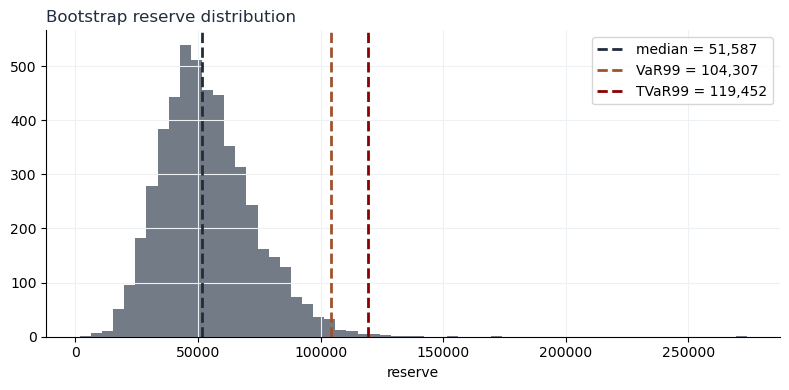

In [9]:
# ══════════════════════════════════════════════════════════════════════
# CELL 08 · §5 · reserve capital: VaR99 / TVaR99         v0.3.0
# provides: var99, tvar99   ·   requires: sims
# ══════════════════════════════════════════════════════════════════════

var99, tvar99, best = np.percentile(sims, 99), sims[sims >= np.percentile(sims, 99)].mean(), np.percentile(sims, 50)
print(f"best estimate {best:,.0f} | VaR99 {var99:,.0f} | TVaR99 {tvar99:,.0f} | buffer {tvar99-best:,.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sims, bins=60, color="#5b6472", alpha=.85)
for x, c, l in [(best, NAVY, "median"), (var99, "#A0522D", "VaR99"), (tvar99, "#8B0000", "TVaR99")]:
    ax.axvline(x, color=c, lw=2, ls="--", label=f"{l} = {x:,.0f}")
ax.set_title("Bootstrap reserve distribution", color=NAVY, loc="left"); ax.set_xlabel("reserve"); ax.legend()
plt.tight_layout(); plt.show()


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§6 · Does it predict? A self-contained backtest</h2>
<p>Hide the latest diagonal (stand one year in the past), refit, predict it, compare to what happened. Honest limit:
the <strong>newest</strong> year can't be backtested — nothing to predict from — and that's the year with the most risk.</p>

</div>

In [10]:
# ══════════════════════════════════════════════════════════════════════
# CELL 09 · §6 · leave-out-latest-diagonal backtest      v0.3.0
# provides: bt   ·   requires: C, n, age_to_age
# ══════════════════════════════════════════════════════════════════════

Cr = C.copy(); held = []
for i in range(n):
    j = n-1-i
    if j >= 1: held.append((i, j, C[i, j]))
    Cr[i, j] = np.nan
f_r = age_to_age(Cr)
rows = [(1981+i, a, Cr[i,j-1]*f_r[j-1], Cr[i,j-1]*f_r[j-1]-a) for (i,j,a) in held if not np.isnan(Cr[i,j-1])]
bt = pd.DataFrame(rows, columns=["accident_yr","actual","predicted","error"])
print(bt.round(0).to_string(index=False))
print(f"\nheld-out total: actual {bt.actual.sum():,.0f} predicted {bt.predicted.sum():,.0f} "
      f"({(bt.predicted.sum()-bt.actual.sum())/bt.actual.sum():+.1%})")


 accident_yr  actual  predicted   error
        1981 18834.0        NaN     NaN
        1982 16704.0    16216.0  -488.0
        1983 23466.0    23731.0   265.0
        1984 27067.0    27230.0   163.0
        1985 26180.0    29913.0  3733.0
        1986 15852.0    15046.0  -806.0
        1987 12314.0    14149.0  1835.0
        1988 13112.0    11039.0 -2073.0
        1989  5395.0    10068.0  4673.0

held-out total: actual 158,924 predicted 147,391 (-7.3%)


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§7 · The same code on real CAS data</h2>
<p>The identical pipeline on the pre-loaded workers'-comp Schedule P triangle (§0). Real run-off, real reserve.</p>

</div>

In [11]:
# ══════════════════════════════════════════════════════════════════════
# CELL 10 · §7 · real CAS Schedule P (workers' comp)     v0.3.0
# provides: (report)   ·   requires: wc
# ══════════════════════════════════════════════════════════════════════

m = cl.MackChainladder().fit(wc)
print(f"paid to date   {scalar(wc.latest_diagonal.sum()):,.0f}")
print(f"reserve (Mack) {scalar(m.ibnr_.sum()):,.0f} ± {scalar(m.total_mack_std_err_):,.0f}")


paid to date   11,029,320
reserve (Mack) 2,777,813 ± 163,477


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§8 · Where this sits in the portfolio</h2>
<ul>
<li><strong>It closes §12.</strong> The claims-development divergence <strong>Prof. Denuit</strong> named — the one <code>freMTPL2</code> couldn't
express — is exactly what a development triangle measures.</li>
<li><strong>Engine reuse, stated precisely.</strong> The §4 reserve distribution is a <strong>bootstrap (Monte Carlo)</strong>. The exact
<strong>FFT</strong> engine re-enters at the <strong>micro level</strong> below, where the reserve becomes a genuine compound object.</li>
<li><strong>Individual-vs-collective, one level up.</strong> Macro (triangle) vs micro (individual claim) reserving is the same
bottom-up/top-down tension from §12, now on the time axis — squarely <strong>Prof. Denuit's</strong> research territory.</li>
</ul>

</div>

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§9 · One portfolio, one year-end valuation date, one hidden future</h2>
<p>The earlier versions switched from the RAA triangle to an invented claim-level model. That illustrated FFT
aggregation, but it did <strong>not</strong> mean that macro and micro analyses described the same underlying claims.</p>
<p>Here both views use one fixed <strong>SynthETIC</strong> transaction history. The standard example uses quarterly periods:
40 occurrence periods = 10 calendar years. We therefore value at:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">T = 40 quarters = 10 years</div>

<p>Information dated after T is hidden from the reserving models and retained only as <strong>ground truth</strong>.</p>
<p>For every claim with occurrence time ≤ T:</p>
<ul>
<li>payments at or before T are observed;</li>
<li>payments after T form the true outstanding reserve;</li>
<li>notification time = <code>occurrence_time + notidel</code>;</li>
<li>closure time = <code>occurrence_time + notidel + setldel</code>;</li>
<li>reported but still open at T = <strong>RBNS</strong>;</li>
<li>occurred but not yet reported at T = <strong>IBNR</strong>.</li>
</ul>
<p>Thus the triangle view and claim-level view are genuinely two representations of the <strong>same simulated portfolio</strong>.</p>

</div>

In [12]:
# CELL 11 · §9 · valuation cut and ground truth
T = 40.0
QUARTERS_PER_YEAR = 4

claim_cols = ['claim_no','occurrence_period','occurrence_time','claim_size','notidel','setldel']
claims_df = tx[claim_cols].drop_duplicates('claim_no').copy()
claims_df['notification_time'] = claims_df['occurrence_time'] + claims_df['notidel']
claims_df['closure_time'] = claims_df['occurrence_time'] + claims_df['notidel'] + claims_df['setldel']

incurred = claims_df[claims_df['occurrence_time'] <= T].copy()
tx_incurred = tx[tx['claim_no'].isin(incurred['claim_no'])].copy()

observed_tx = tx_incurred[tx_incurred['payment_time'] <= T].copy()
future_tx   = tx_incurred[tx_incurred['payment_time'] >  T].copy()

# Future amounts are retained only for validation.
future_by_claim = future_tx.groupby('claim_no')['payment_size'].sum()
incurred['future_payment'] = incurred['claim_no'].map(future_by_claim).fillna(0.0)

# Observable claim status at T.
incurred['reported_at_T'] = incurred['notification_time'] <= T
incurred['open_at_T'] = incurred['reported_at_T'] & (incurred['closure_time'] > T)

true_reserve = future_tx['payment_size'].sum()
true_rbns = incurred.loc[incurred['open_at_T'], 'future_payment'].sum()
true_ibnr = incurred.loc[~incurred['reported_at_T'], 'future_payment'].sum()

print(f"valuation time T = {T:g} quarters = {T/QUARTERS_PER_YEAR:g} years")
print(f"claims incurred by T        : {len(incurred):,}")
print(f"reported by T               : {incurred['reported_at_T'].sum():,}")
print(f"open RBNS claims at T       : {incurred['open_at_T'].sum():,}")
print(f"true IBNR claims            : {(~incurred['reported_at_T']).sum():,}")
print(f"observed payments by T      : {observed_tx['payment_size'].sum():,.0f}")
print(f"TRUE future reserve         : {true_reserve:,.0f}")
print(f"  RBNS future               : {true_rbns:,.0f}")
print(f"  IBNR future               : {true_ibnr:,.0f}")


valuation time T = 40 quarters = 10 years
claims incurred by T        : 3,624
reported by T               : 3,439
open RBNS claims at T       : 846
true IBNR claims            : 185
observed payments by T      : 380,549,967
TRUE future reserve         : 193,959,141
  RBNS future               : 173,999,071
  IBNR future               : 19,960,070


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§10 · Build a conventional annual paid triangle from those same claims</h2>
<p>SynthETIC operates quarterly, but classical Schedule-P-style reserving is naturally read as an annual triangle.
We aggregate <strong>four simulator quarters into one accident year and one development year</strong>.</p>
<p>At T = 40 quarters we have exactly ten accident years. The first accident year has ten years of observed
development; the tenth has one. This produces a standard <strong>10×10 upper triangle</strong>, directly comparable in shape
to RAA, while preserving every payment observed by the valuation date.</p>
<p>The annual aggregation also removes the structural zero problem in the quarterly first-development cells that
made the ODP bootstrap numerically unstable in v0.5.0.</p>

</div>

In [13]:
# CELL 12 · §10 · annual SynthETIC paid development triangle
tri_tx = observed_tx.copy()

# SynthETIC period numbers are quarters. Collapse quarters 1..4 -> year 1, etc.
tri_tx['origin_year'] = ((tri_tx['occurrence_period'].astype(int) - 1)
                         // QUARTERS_PER_YEAR) + 1
tri_tx['payment_year'] = ((tri_tx['payment_period'].astype(int) - 1)
                          // QUARTERS_PER_YEAR) + 1
tri_tx['dev_year'] = tri_tx['payment_year'] - tri_tx['origin_year'] + 1

N_YEARS = int(T // QUARTERS_PER_YEAR)

inc_tri = (tri_tx.groupby(['origin_year','dev_year'])['payment_size']
                 .sum().unstack('dev_year').fillna(0.0)
                 .reindex(index=range(1, N_YEARS+1),
                          columns=range(1, N_YEARS+1)))

# Standard valuation diagonal: origin + development - 1 <= N_YEARS.
for origin in inc_tri.index:
    max_dev = N_YEARS - origin + 1
    inc_tri.loc[origin, inc_tri.columns > max_dev] = np.nan

cum_tri = inc_tri.cumsum(axis=1)

print("SynthETIC cumulative paid triangle — annual aggregation:")
print(cum_tri.round(0))
print(f"\ntriangle shape: {cum_tri.shape}; observed cells: {cum_tri.notna().sum().sum()}")
print(f"zero cumulative cells inside observed triangle: {(cum_tri.fillna(-1) == 0).sum().sum()}")


SynthETIC cumulative paid triangle — annual aggregation:
dev_year            1           2           3           4           5   \
origin_year                                                              
1             974532.0   8370740.0  15961670.0  24630933.0  34223055.0   
2            1239365.0   7290391.0  19390178.0  27009711.0  34066355.0   
3            2478936.0  11621966.0  25224762.0  34512319.0  40836519.0   
4            1377530.0   9299063.0  20782149.0  31521723.0  37461801.0   
5            1130319.0  12490132.0  24027910.0  36683728.0  44651509.0   
6            2294666.0  11807078.0  24108156.0  33999552.0  44353033.0   
7            1002399.0  11187028.0  21067551.0  32668964.0         NaN   
8            1719307.0  10335437.0  20177395.0         NaN         NaN   
9             882514.0  11113640.0         NaN         NaN         NaN   
10           1063558.0         NaN         NaN         NaN         NaN   

dev_year             6           7           8        

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>Convert to a <code>chainladder.Triangle</code></h3>
<p><code>chainladder</code> wants an origin date and a <strong>valuation date</strong>, not a numerical development age.
We map the ten synthetic accident years to 1991–2000 purely as labels.</p>
<p>If <em>i</em> is the origin year and <em>d</em> the development year, the valuation year is:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">valuation year = origin year + development year − 1</div>

<p><code>chainladder</code> then derives 12, 24, … month development ages itself.</p>

</div>

In [14]:
# CELL 13 · §10 · chainladder object from annual SynthETIC triangle
long_rows = []

for origin in cum_tri.index:
    origin_calendar_year = 1990 + int(origin)

    for dev in cum_tri.columns:
        val = cum_tri.loc[origin, dev]
        if pd.notna(val):
            valuation_year = origin_calendar_year + int(dev) - 1
            long_rows.append({
                "origin": origin_calendar_year,
                "development": valuation_year,
                "value": float(val),
            })

synth_long = pd.DataFrame(long_rows)

synth_tri = cl.Triangle(
    synth_long,
    origin="origin",
    development="development",
    columns="value",
    cumulative=True,
)

print(synth_tri.to_frame().round(0))


                  12          24          36          48          60   \
1991-01-01   974532.0   8370740.0  15961670.0  24630933.0  34223055.0   
1992-01-01  1239365.0   7290391.0  19390178.0  27009711.0  34066355.0   
1993-01-01  2478936.0  11621966.0  25224762.0  34512319.0  40836519.0   
1994-01-01  1377530.0   9299063.0  20782149.0  31521723.0  37461801.0   
1995-01-01  1130319.0  12490132.0  24027910.0  36683728.0  44651509.0   
1996-01-01  2294666.0  11807078.0  24108156.0  33999552.0  44353033.0   
1997-01-01  1002399.0  11187028.0  21067551.0  32668964.0         NaN   
1998-01-01  1719307.0  10335437.0  20177395.0         NaN         NaN   
1999-01-01   882514.0  11113640.0         NaN         NaN         NaN   
2000-01-01  1063558.0         NaN         NaN         NaN         NaN   

                   72          84          96          108         120  
1991-01-01  45724746.0  50785168.0  55882922.0  59256264.0  61091263.0  
1992-01-01  41123110.0  45846954.0  48362862.0  54

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§11 · Top-down reserve on SynthETIC: Chain Ladder, Mack and bootstrap</h2>
<p>The macro methods now see the <strong>annual 10×10 triangle</strong> generated from the SynthETIC transactions available at
year-end 10. The hidden payments after that date are not used in fitting.</p>
<p>The key comparison is therefore against the <strong>actual future payments of those same claims</strong>, not against another
calibrated model.</p>

</div>

In [15]:
# CELL 14 · §11 · macro reserving on annual SynthETIC triangle
s_cl = cl.Chainladder().fit(synth_tri)
s_mack = cl.MackChainladder().fit(synth_tri)

cl_reserve = scalar(s_cl.ibnr_.sum())
mack_se = scalar(s_mack.total_mack_std_err_)

# Independent hand calculation of age-to-age factors as a transparent diagnostic.
C_synth = cum_tri.to_numpy(dtype=float)
f_synth = age_to_age(C_synth)

print("annual age-to-age factors:", np.round(f_synth, 3))
print(f"Chain-Ladder reserve : {cl_reserve:,.0f}")
print(f"Mack std. error      : {mack_se:,.0f}")
print(f"TRUE hidden reserve  : {true_reserve:,.0f}")
print(f"CL error             : {cl_reserve-true_reserve:,.0f} ({(cl_reserve/true_reserve-1):+.1%})")


annual age-to-age factors: [7.139 2.072 1.468 1.251 1.205 1.099 1.08  1.09  1.031]
Chain-Ladder reserve : 237,781,966
Mack std. error      : 36,103,691
TRUE hidden reserve  : 193,959,141
CL error             : 43,822,825 (+22.6%)


In [16]:
if RUN_CORE_MACRO:
    # CELL 15 · §11 · ODP bootstrap predictive distribution
    s_boot = cl.BootstrapODPSample(n_sims=5000, random_state=42).fit_transform(synth_tri)
    s_sims = np.asarray(cl.Chainladder().fit(s_boot).ibnr_.sum('origin').values).flatten()
    s_sims = s_sims[np.isfinite(s_sims)]

    q50, q95, q99, q995 = np.percentile(s_sims, [50,95,99,99.5])
    boot_mean = s_sims.mean()

    print(f"bootstrap sims       : {len(s_sims):,}")
    print(f"mean / median        : {boot_mean:,.0f} / {q50:,.0f}")
    print(f"95% / 99% / 99.5%    : {q95:,.0f} / {q99:,.0f} / {q995:,.0f}")
    print(f"true reserve percentile ≈ {(s_sims <= true_reserve).mean():.1%}")

    if boot_mean > 1.5 * q50:
        print("WARNING: bootstrap mean is far above its median; inspect tail stability before interpreting capital.")
else:
    print('Skipped: ODP bootstrap (RUN_CORE_MACRO=False)')


bootstrap sims       : 5,000
mean / median        : 239,995,580 / 237,618,553
95% / 99% / 99.5%    : 306,755,920 / 337,051,374 / 348,387,651
true reserve percentile ≈ 10.7%


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§12 · Bottom-up reserving — learn from historical claim snapshots</h2>
<p>The top-down triangle model knows only totals by accident year and development year. A claim handler sees
something more concrete: <em>this claim was reported three years ago, has already paid €120,000 in four instalments,
and is still open</em>. A micro-level reserving model should use that information.</p>
<p>The earlier benchmark assigned essentially one severity scale to every open claim. That ignored the fact that
<strong>each open claim is at a different stage of development</strong>.</p>
<h3>The key device: a historical pseudo-valuation</h3>
<p>We cannot train on the hidden future after today's valuation date T = 40. Instead we move backwards and ask:</p>
<blockquote>
<p>Suppose the valuation date had been quarter 20. What would the insurer have known about each open claim then,
and how much did that claim subsequently pay before it closed?</p>
</blockquote>
<p>At an old snapshot <em>s</em> we record only information available then:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
X<sub>i</sub>(s) = claim age, time since report, paid to date, number of payments,
time since last payment, …
</div>

<p>The target is:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
Y<sub>i</sub>(s) = payments after s until closure
</div>

<p>The same physical claim may appear at more than one historical snapshot. That is intentional: a claim at age one
year is a different reserving state from the same claim at age three years.</p>

</div>

In [17]:
# CELL 16 · §12 · current claim populations at T
rbns_claims = incurred[incurred['open_at_T']].copy()
ibnr_claims = incurred[~incurred['reported_at_T']].copy()

paid_by_claim = observed_tx.groupby('claim_no')['payment_size'].sum()
rbns_claims['paid_to_T'] = rbns_claims['claim_no'].map(paid_by_claim).fillna(0.0)

print(f"open RBNS count at T : {len(rbns_claims):,}")
print(f"IBNR truth count     : {len(ibnr_claims):,}  (hidden truth; validation only)")
print(f"true RBNS future     : {true_rbns:,.0f}")
print(f"true IBNR future     : {true_ibnr:,.0f}")
print(f"true split           : {true_rbns/true_reserve:.1%} RBNS / {true_ibnr/true_reserve:.1%} IBNR")


open RBNS count at T : 846
IBNR truth count     : 185  (hidden truth; validation only)
true RBNS future     : 173,999,071
true IBNR future     : 19,960,070
true split           : 89.7% RBNS / 10.3% IBNR


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>12.1 · Constructing the RBNS training table</h3>
<p>At an old pseudo-valuation <em>s</em>, we initially keep claims that were already reported, still open at <em>s</em>, and fully
closed by the later observation horizon. This gives a fully observed remaining-cost target.</p>
<p>That last condition later proves important: claims still open at the horizon are <strong>right-censored</strong>. Their final
remaining cost is not yet completely observed.</p>
<p>The predictors exclude SynthETIC's latent <code>claim_size</code> and the numerical future closure time. Those belong to the
simulator's hidden future, not to the insurer's information set.</p>
<p><code>log_paid</code> and <code>log_avg_payment</code> compress highly skewed monetary amounts.</p>

</div>

In [18]:
# CELL 17 · §12 · build historical pseudo-valuations for RBNS
def rbns_snapshot(snapshot, horizon=T):
    # Claims reported/open at snapshot whose subsequent outcome is fully known by horizon.
    hist = claims_df[
        (claims_df['occurrence_time'] <= snapshot) &
        (claims_df['notification_time'] <= snapshot) &
        (claims_df['closure_time'] > snapshot) &
        (claims_df['closure_time'] <= horizon)
    ].copy()

    ids = hist['claim_no'].to_numpy()

    obs = tx[
        tx['claim_no'].isin(ids) &
        (tx['payment_time'] <= snapshot)
    ]
    obs_stats = obs.groupby('claim_no').agg(
        paid_to_date=('payment_size', 'sum'),
        n_payments=('payment_size', 'size'),
        last_payment_time=('payment_time', 'max'),
        avg_payment=('payment_size', 'mean')
    )

    fut = tx[
        tx['claim_no'].isin(ids) &
        (tx['payment_time'] > snapshot) &
        (tx['payment_time'] <= horizon)
    ].groupby('claim_no')['payment_size'].sum()

    d = hist.set_index('claim_no').join(obs_stats)
    d['paid_to_date'] = d['paid_to_date'].fillna(0.0)
    d['n_payments'] = d['n_payments'].fillna(0)
    d['avg_payment'] = d['avg_payment'].fillna(0.0)

    d['age_occ'] = snapshot - d['occurrence_time']
    d['age_report'] = snapshot - d['notification_time']
    d['since_last_payment'] = snapshot - d['last_payment_time']
    d['since_last_payment'] = d['since_last_payment'].fillna(d['age_report'])

    d['log_paid'] = np.log1p(d['paid_to_date'])
    d['log_avg_payment'] = np.log1p(d['avg_payment'])
    d['remaining'] = fut.reindex(d.index).fillna(0.0)
    d['snapshot'] = snapshot

    return d.reset_index()

SNAPSHOTS = [8., 12., 16., 20., 24., 28.]
snapshot_tables = {s: rbns_snapshot(s) for s in SNAPSHOTS}

for s in SNAPSHOTS:
    print(f"snapshot {s:>4.0f}: {len(snapshot_tables[s]):4d} fully-observed open-claim states")


snapshot    8:  413 fully-observed open-claim states
snapshot   12:  607 fully-observed open-claim states
snapshot   16:  706 fully-observed open-claim states
snapshot   20:  750 fully-observed open-claim states
snapshot   24:  745 fully-observed open-claim states
snapshot   28:  665 fully-observed open-claim states


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>12.2 · An interpretable remaining-cost model</h3>
<p>Remaining claim cost is positive and strongly right-skewed. A <strong>Gamma regression with a log link</strong> is a standard
actuarial benchmark for such positive skewed costs.</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
E[Y<sub>i</sub> | X<sub>i</sub>] =
exp(β<sub>0</sub> + β<sub>1</sub>x<sub>i1</sub> + … + β<sub>p</sub>x<sub>ip</sub>)
</div>

<p>The exponential form guarantees a positive prediction. The predictors are standardised so variables measured in
euros and variables measured in quarters can coexist numerically.</p>
<p>Predictors include claim age, time since report, cumulative paid amount, number of payments, time since the latest
payment and average payment size so far.</p>

</div>

In [19]:
if RUN_BASE_MICRO:
    # CELL 18 · §12 · out-of-time validation of the RBNS regression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import GammaRegressor

    RBNS_FEATURES = [
        'age_occ', 'age_report', 'log_paid',
        'n_payments', 'since_last_payment', 'log_avg_payment'
    ]

    train_old = pd.concat(
        [snapshot_tables[s] for s in [8., 12., 16., 20., 24.]],
        ignore_index=True
    )
    valid_28 = snapshot_tables[28.].copy()

    rbns_check = make_pipeline(
        StandardScaler(),
        GammaRegressor(alpha=0.20, max_iter=5000)
    )
    rbns_check.fit(train_old[RBNS_FEATURES], train_old['remaining'])

    valid_28['predicted'] = rbns_check.predict(valid_28[RBNS_FEATURES])

    baseline_per_claim = train_old['remaining'].mean()
    baseline_total = baseline_per_claim * len(valid_28)

    mae_model = np.mean(np.abs(valid_28['predicted'] - valid_28['remaining']))
    mae_base  = np.mean(np.abs(baseline_per_claim - valid_28['remaining']))

    print("Out-of-time check at pseudo-valuation 28")
    print(f"  actual remaining total : {valid_28['remaining'].sum():,.0f}")
    print(f"  Gamma predicted total  : {valid_28['predicted'].sum():,.0f}")
    print(f"  one-number baseline    : {baseline_total:,.0f}")
    print(f"  claim-level MAE Gamma  : {mae_model:,.0f}")
    print(f"  claim-level MAE base   : {mae_base:,.0f}")
else:
    print('Skipped: base micro validation (RUN_BASE_MICRO=False)')


Out-of-time check at pseudo-valuation 28
  actual remaining total : 120,784,486
  Gamma predicted total  : 133,352,992
  one-number baseline    : 127,418,294
  claim-level MAE Gamma  : 168,375
  claim-level MAE base   : 171,058


  File "C:\Tools\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Tools\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Tools\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Tools\anaconda3\Lib\subprocess.py", line 1554, in _exec

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<p>The validation is shown even if the Gamma model does not win on every aggregate statistic. The purpose is not to tune a
model until it reproduces the simulated future; it is to demonstrate a genuine model-development workflow using an old
valuation date that was not part of fitting.</p>
<p>After that check, all six historical snapshots through quarter 28 are used to fit the final RBNS model for today's
valuation at <span>T=40</span>.</p>

</div>

In [20]:
if RUN_BASE_MICRO:
    # CELL 19 · §12 · fit final RBNS model and predict today's open claims
    rbns_train = pd.concat(
        [snapshot_tables[s] for s in SNAPSHOTS],
        ignore_index=True
    )

    rbns_model = make_pipeline(
        StandardScaler(),
        GammaRegressor(alpha=0.20, max_iter=5000)
    )
    rbns_model.fit(rbns_train[RBNS_FEATURES], rbns_train['remaining'])

    current = rbns_claims.set_index('claim_no').copy()
    ids = current.index.to_numpy()

    obs_now = observed_tx[observed_tx['claim_no'].isin(ids)]
    obs_now_stats = obs_now.groupby('claim_no').agg(
        paid_to_date=('payment_size', 'sum'),
        n_payments=('payment_size', 'size'),
        last_payment_time=('payment_time', 'max'),
        avg_payment=('payment_size', 'mean')
    )

    current = current.join(obs_now_stats)
    current['paid_to_date'] = current['paid_to_date'].fillna(0.0)
    current['n_payments'] = current['n_payments'].fillna(0)
    current['avg_payment'] = current['avg_payment'].fillna(0.0)

    current['age_occ'] = T - current['occurrence_time']
    current['age_report'] = T - current['notification_time']
    current['since_last_payment'] = T - current['last_payment_time']
    current['since_last_payment'] = current['since_last_payment'].fillna(current['age_report'])
    current['log_paid'] = np.log1p(current['paid_to_date'])
    current['log_avg_payment'] = np.log1p(current['avg_payment'])

    current['pred_remaining'] = rbns_model.predict(current[RBNS_FEATURES])
    rbns_mean_ageaware = current['pred_remaining'].sum()

    train_pred = rbns_model.predict(rbns_train[RBNS_FEATURES])
    ratio = rbns_train['remaining'].to_numpy() / train_pred
    rbns_residual_cv = ratio.std(ddof=1) / ratio.mean()

    print(f"RBNS training states       : {len(rbns_train):,}")
    print(f"current open RBNS claims   : {len(current):,}")
    print(f"age-aware RBNS mean        : {rbns_mean_ageaware:,.0f}")
    print(f"conditional residual CV    : {rbns_residual_cv:.2f}")
    print(f"TRUE RBNS future           : {true_rbns:,.0f}  (validation only)")
    print(f"RBNS mean error            : {rbns_mean_ageaware-true_rbns:,.0f} "
          f"({rbns_mean_ageaware/true_rbns-1:+.1%})")
else:
    print('Skipped: base RBNS model (RUN_BASE_MICRO=False)')


RBNS training states       : 3,886
current open RBNS claims   : 846
age-aware RBNS mean        : 165,776,003
conditional residual CV    : 1.42
TRUE RBNS future           : 173,999,071  (validation only)
RBNS mean error            : -8,223,068 (-4.7%)


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§13 · IBNR without knowing the hidden claims</h2>
<p>IBNR is harder than RBNS because the insurer does not even know which individual claims exist yet.</p>
<h3>13.1 Frequency: expected claims × probability still unreported</h3>
<p>Historical quarters estimate average claim frequency. Historical reporting delays estimate the probability that
a claim of a given age is still unreported.</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
E[N<sub>IBNR</sub>] = Σ<sub>q</sub> λ̂<sub>F</sub> × P(reporting delay &gt; age<sub>q</sub>)
</div>

<h3>13.2 Severity: condition on being late-reported</h3>
<p>Late-reported claims need not have the same severity as promptly reported claims. For each accident quarter we
therefore use mature historical claims with a comparable reporting delay as the severity analogue.</p>

</div>

In [21]:
if RUN_BASE_MICRO:
    # CELL 20 · §13 · causal IBNR frequency and age-conditioned severity
    MATURE_PERIODS = range(1, 25)

    reported_hist = claims_df[
        (claims_df['occurrence_period'] <= 24) &
        (claims_df['notification_time'] <= T)
    ].copy()

    freq_counts = (
        reported_hist.groupby('occurrence_period')['claim_no'].nunique()
        .reindex(MATURE_PERIODS, fill_value=0)
    )
    freq_per_quarter = freq_counts.mean()
    delay_hist = reported_hist['notidel'].to_numpy()

    severity_hist = reported_hist[reported_hist['closure_time'] <= T].copy()
    hist_ids = severity_hist['claim_no'].to_numpy()
    hist_total_paid = (
        observed_tx[observed_tx['claim_no'].isin(hist_ids)]
        .groupby('claim_no')['payment_size'].sum()
    )
    severity_hist = severity_hist.set_index('claim_no')
    severity_hist['total_paid'] = hist_total_paid.reindex(severity_hist.index).fillna(0.0)

    ibnr_count_hat = 0.0
    ibnr_cost_hat = 0.0
    ibnr_second_moment_weighted = 0.0

    for period in range(1, 41):
        age = T - (period - 0.5)
        p_still_unreported = np.mean(delay_hist > age)
        expected_count = freq_per_quarter * p_still_unreported

        analogous = severity_hist.loc[severity_hist['notidel'] > age, 'total_paid'].to_numpy()
        if analogous.size == 0:
            analogous = severity_hist['total_paid'].to_numpy()

        sev_mean = analogous.mean()
        sev_second = np.mean(analogous**2)

        ibnr_count_hat += expected_count
        ibnr_cost_hat += expected_count * sev_mean
        ibnr_second_moment_weighted += expected_count * sev_second

    ibnr_mean_sev = ibnr_cost_hat / ibnr_count_hat
    ibnr_second = ibnr_second_moment_weighted / ibnr_count_hat
    ibnr_cv = np.sqrt(max(ibnr_second - ibnr_mean_sev**2, 0.0)) / ibnr_mean_sev

    print(f"historical claim frequency  : {freq_per_quarter:.1f} per quarter")
    print(f"estimated IBNR count        : {ibnr_count_hat:.1f}")
    print(f"age-conditioned severity    : mean {ibnr_mean_sev:,.0f}, CV {ibnr_cv:.2f}")
    print(f"estimated IBNR mean reserve : {ibnr_cost_hat:,.0f}")
    print(f"true IBNR count             : {len(ibnr_claims):,}  (validation only)")
    print(f"true IBNR reserve           : {true_ibnr:,.0f}  (validation only)")
else:
    print('Skipped: base IBNR model (RUN_BASE_MICRO=False)')


historical claim frequency  : 91.3 per quarter
estimated IBNR count        : 195.0
age-conditioned severity    : mean 103,369, CV 1.70
estimated IBNR mean reserve : 20,152,576
true IBNR count             : 185  (validation only)
true IBNR reserve           : 19,960,070  (validation only)


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§14 · Put heterogeneous claim estimates through the FFT</h2>
<p>The 846 current RBNS claims no longer all have the same expected remaining cost. An exact FFT with 846 distinct severity
distributions would be unnecessarily heavy for an explanatory notebook, so claims are sorted into <strong>12 groups by
predicted remaining cost</strong>. Within each group we use the group's average predicted mean and the historical conditional
CV. Multiplying the groups' characteristic functions is equivalent to convolving their aggregate distributions.</p>
<p>The IBNR component remains compound Poisson, with frequency and severity now estimated from historical information.
The FFT still assumes conditional independence; dependence, common inflation shocks and parameter uncertainty remain
explicit extensions.</p>

</div>

In [22]:
# CELL 21 · §14 · FFT primitives
H_LAT, M = 5000.0, 1 << 17
grid = np.arange(M) * H_LAT

def sev_pmf(mean, cv):
    s = np.sqrt(np.log(1 + cv**2))
    sc = mean / np.exp(0.5*s*s)
    edges = np.concatenate([[0.0], (np.arange(M)+0.5)*H_LAT])
    f = np.diff(stats.lognorm(s=s, scale=sc).cdf(edges))
    f = np.clip(f, 0, None)
    return f / f.sum()

def aggregate_cf_to_pmf(cf):
    p = np.real(np.fft.ifft(cf))
    p = np.clip(p, 0, None)
    return p / p.sum()

def var_tvar(pmf, p=0.99):
    j = np.searchsorted(np.cumsum(pmf), p)
    tail = pmf[j:]
    return grid[j], (grid[j:] * tail).sum() / tail.sum()


In [23]:
if RUN_BASE_MICRO:
    # CELL 22 · §14 · grouped RBNS FFT + compound-Poisson IBNR
    group_labels = pd.qcut(current['pred_remaining'], q=12, duplicates='drop')
    groups = (
        current.assign(group=group_labels)
        .groupby('group', observed=True)['pred_remaining']
        .agg(['count', 'mean'])
    )

    cf_total = np.ones(M, dtype=complex)

    for _, row in groups.iterrows():
        f_group = sev_pmf(row['mean'], max(rbns_residual_cv, 0.05))
        cf_total *= np.fft.fft(f_group) ** int(row['count'])

    f_ibnr = sev_pmf(ibnr_mean_sev, max(ibnr_cv, 0.05))
    cf_total *= np.exp(ibnr_count_hat * (np.fft.fft(f_ibnr) - 1.0))

    micro_total = aggregate_cf_to_pmf(cf_total)
    micro_mean = (grid * micro_total).sum()
    micro_var99, micro_tvar99 = var_tvar(micro_total, 0.99)

    print("RBNS prediction groups:")
    print(groups.round(0).to_string())
    print()
    print(f"age-aware RBNS mean      : {rbns_mean_ageaware:,.0f}")
    print(f"causal IBNR mean         : {ibnr_cost_hat:,.0f}")
    print(f"micro total mean         : {micro_mean:,.0f}")
    print(f"micro VaR99 / TVaR99     : {micro_var99:,.0f} / {micro_tvar99:,.0f}")
    print(f"Chain-Ladder mean        : {cl_reserve:,.0f}")
    print(f"macro bootstrap VaR99    : {q99:,.0f}")
    print(f"TRUE hidden reserve      : {true_reserve:,.0f}")
else:
    print('Skipped: base micro FFT (RUN_BASE_MICRO=False)')


RBNS prediction groups:
                          count      mean
group                                    
(100969.841, 133980.012]     71  125903.0
(133980.012, 150886.142]     70  141142.0
(150886.142, 165367.945]     71  159129.0
(165367.945, 173564.304]     70  169810.0
(173564.304, 181895.068]     71  177824.0
(181895.068, 188193.246]     70  184917.0
(188193.246, 197030.951]     70  192708.0
(197030.951, 206626.142]     71  202090.0
(206626.142, 218370.977]     70  212267.0
(218370.977, 231500.481]     71  225233.0
(231500.481, 258250.015]     70  244052.0
(258250.015, 592687.145]     71  315923.0

age-aware RBNS mean      : 165,776,003
causal IBNR mean         : 20,152,576
micro total mean         : 185,929,003
micro VaR99 / TVaR99     : 208,110,000 / 212,072,332
Chain-Ladder mean        : 237,781,966
macro bootstrap VaR99    : 337,051,374
TRUE hidden reserve      : 193,959,141


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>Interpreting the comparison</h3>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
Macro reserve &nbsp;↔&nbsp; Micro reserve &nbsp;↔&nbsp; Realised hidden future
</div>

<p>The <strong>macro</strong> model extrapolates aggregate development patterns. The <strong>micro</strong> model predicts remaining payments
on specific open claims plus an allowance for claims not yet reported. The <strong>hidden future</strong> is one realised
outcome from the simulator; it is not itself an expected value.</p>
<p>Neither model should equal that one realised future exactly. The important questions are whether the information
boundary is respected, whether predictive distributions are plausible, and whether repeated historical backtests
reveal systematic bias.</p>

</div>

In [24]:
# CELL 23 · §14 · compact macro / micro / truth comparison
comparison = pd.DataFrame({
    'quantity': [
        'true hidden reserve',
        'Chain-Ladder mean',
        'bootstrap mean',
        'bootstrap VaR99',
        'age-aware micro mean',
        'age-aware micro VaR99'
    ],
    'value': [
        true_reserve,
        cl_reserve,
        boot_mean,
        q99,
        micro_mean,
        micro_var99
    ]
})
comparison['error_vs_truth'] = comparison['value'] - true_reserve
comparison['relative_error'] = comparison['value'] / true_reserve - 1

print(
    comparison.round({
        'value': 0,
        'error_vs_truth': 0,
        'relative_error': 3
    }).to_string(index=False)
)


             quantity       value  error_vs_truth  relative_error
  true hidden reserve 193959141.0             0.0           0.000
    Chain-Ladder mean 237781966.0      43822825.0           0.226
       bootstrap mean 239995580.0      46036439.0           0.237
      bootstrap VaR99 337051374.0     143092233.0           0.738
 age-aware micro mean 185929003.0      -8030138.0          -0.041
age-aware micro VaR99 208110000.0      14150859.0           0.073


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§15 · What would be the next actuarial upgrade?</h2>
<p>The important conceptual problem has now been solved: macro and micro reserving use the <strong>same underlying claims</strong>, and
both respect the valuation-date information boundary.</p>
<p>The next improvements are conventional modelling questions: richer claim covariates, explicit modelling of future
payment counts and timing, accident-cohort frequency trends, calendar-year inflation, parameter uncertainty, and
dependence between claims.</p>
<p>Section §16 now implements a <strong>rolling-origin backtest</strong>. Once those results are satisfactory, the next substantive
extension is parameter uncertainty in the micro model: uncertainty in the Gamma coefficients, claim frequency,
reporting-delay distribution and severity estimates should be propagated into the predictive tail.</p>

</div>

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§16 · Rolling-origin backtest — does the improvement persist?</h2>
<p>A single valuation date can flatter or punish a model by chance. We therefore repeat the reserving exercise at:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">T = 24, 28, 32, 36, 40 quarters</div>

<p>At each historical valuation date, only information then available is used. Future payments are hidden and opened
only for validation. The micro model is retrained using only still-earlier pseudo-valuations.</p>
<p>This is a <strong>rolling-origin</strong> or <strong>walk-forward</strong> backtest. In ordinary language: instead of asking
<em>“Did the model work once?”</em>, ask <em>“Would it have worked repeatedly if we had used it earlier?”</em></p>

</div>

In [25]:
# CELL 24 · §16 · helper functions for rolling-origin backtesting

def make_truth_at(T_star):
    inc = claims_df[claims_df['occurrence_time'] <= T_star].copy()
    tx_inc = tx[tx['claim_no'].isin(inc['claim_no'])].copy()

    obs = tx_inc[tx_inc['payment_time'] <= T_star].copy()
    fut = tx_inc[tx_inc['payment_time'] > T_star].copy()

    inc['reported_at_T'] = inc['notification_time'] <= T_star
    inc['open_at_T'] = inc['reported_at_T'] & (inc['closure_time'] > T_star)

    fut_by_claim = fut.groupby('claim_no')['payment_size'].sum()
    inc['future_payment'] = inc['claim_no'].map(fut_by_claim).fillna(0.0)

    truth_total = fut['payment_size'].sum()
    truth_rbns = inc.loc[inc['open_at_T'], 'future_payment'].sum()
    truth_ibnr = inc.loc[~inc['reported_at_T'], 'future_payment'].sum()

    return inc, obs, fut, truth_total, truth_rbns, truth_ibnr


def annual_triangle_at(T_star, obs):
    n_years = int(T_star // QUARTERS_PER_YEAR)

    d = obs.copy()
    d['origin_year'] = ((d['occurrence_period'].astype(int) - 1) // QUARTERS_PER_YEAR) + 1
    d['payment_year'] = ((d['payment_period'].astype(int) - 1) // QUARTERS_PER_YEAR) + 1
    d['dev_year'] = d['payment_year'] - d['origin_year'] + 1

    inc_tri_bt = (
        d.groupby(['origin_year','dev_year'])['payment_size']
         .sum().unstack('dev_year').fillna(0.0)
         .reindex(index=range(1, n_years+1), columns=range(1, n_years+1))
    )

    for origin in inc_tri_bt.index:
        max_dev = n_years - origin + 1
        inc_tri_bt.loc[origin, inc_tri_bt.columns > max_dev] = np.nan

    cum_tri_bt = inc_tri_bt.cumsum(axis=1)

    long_rows = []
    for origin in cum_tri_bt.index:
        origin_calendar_year = 1990 + int(origin)
        for dev in cum_tri_bt.columns:
            value = cum_tri_bt.loc[origin, dev]
            if pd.notna(value):
                long_rows.append({
                    "origin": origin_calendar_year,
                    "development": origin_calendar_year + int(dev) - 1,
                    "value": float(value),
                })

    tri = cl.Triangle(
        pd.DataFrame(long_rows),
        origin="origin",
        development="development",
        columns="value",
        cumulative=True,
    )
    return tri, cum_tri_bt


def rbns_snapshot_for_backtest(snapshot, horizon):
    # Claims reported and still open at `snapshot`, but fully closed by the
    # historical backtest horizon. Their old remaining cost is therefore known.
    hist = claims_df[
        (claims_df['occurrence_time'] <= snapshot) &
        (claims_df['notification_time'] <= snapshot) &
        (claims_df['closure_time'] > snapshot) &
        (claims_df['closure_time'] <= horizon)
    ].copy()

    ids = hist['claim_no'].to_numpy()

    obs = tx[
        tx['claim_no'].isin(ids) &
        (tx['payment_time'] <= snapshot)
    ]
    stats_obs = obs.groupby('claim_no').agg(
        paid_to_date=('payment_size', 'sum'),
        n_payments=('payment_size', 'size'),
        last_payment_time=('payment_time', 'max'),
        avg_payment=('payment_size', 'mean')
    )

    fut = tx[
        tx['claim_no'].isin(ids) &
        (tx['payment_time'] > snapshot) &
        (tx['payment_time'] <= horizon)
    ].groupby('claim_no')['payment_size'].sum()

    d = hist.set_index('claim_no').join(stats_obs)
    d['paid_to_date'] = d['paid_to_date'].fillna(0.0)
    d['n_payments'] = d['n_payments'].fillna(0)
    d['avg_payment'] = d['avg_payment'].fillna(0.0)

    d['age_occ'] = snapshot - d['occurrence_time']
    d['age_report'] = snapshot - d['notification_time']
    d['since_last_payment'] = snapshot - d['last_payment_time']
    d['since_last_payment'] = d['since_last_payment'].fillna(d['age_report'])
    d['log_paid'] = np.log1p(d['paid_to_date'])
    d['log_avg_payment'] = np.log1p(d['avg_payment'])
    d['remaining'] = fut.reindex(d.index).fillna(0.0)
    d['snapshot'] = snapshot

    return d.reset_index()


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>16.1 · Refit the micro model separately at every historical date</h3>
<p>This is the crucial anti-leakage rule. If the backtest date is quarter 28, the model cannot train on a
pseudo-valuation at quarter 28 because the subsequent outcome would not yet be known.</p>
<p>Training snapshots are therefore chosen sufficiently before each backtest date. Earlier backtests naturally have
less mature training data; that faithfully represents the information scarcity an actuary would have faced then.</p>

</div>

In [26]:
# CELL 25 · §16 · one complete historical backtest

def run_backtest(T_star):
    inc, obs, fut, truth, truth_rbns, truth_ibnr = make_truth_at(T_star)

    # Macro: Chain Ladder.
    tri, cum = annual_triangle_at(T_star, obs)
    cl_fit = cl.Chainladder().fit(tri)
    cl_mean = scalar(cl_fit.ibnr_.sum())

    # Micro RBNS: train only on pseudo-valuations sufficiently earlier than T_star.
    candidate_snapshots = [8., 12., 16., 20., 24., 28., 32.]
    train_snapshots = [s for s in candidate_snapshots if s <= T_star - 8]

    snap_tables = [rbns_snapshot_for_backtest(s, T_star) for s in train_snapshots]
    snap_tables = [d for d in snap_tables if len(d) > 0]

    rbns_now = inc[inc['open_at_T']].copy()

    if len(snap_tables) == 0 or len(rbns_now) == 0:
        micro_rbns_mean = np.nan
    else:
        rbns_train_bt = pd.concat(snap_tables, ignore_index=True)

        model = make_pipeline(
            StandardScaler(),
            GammaRegressor(alpha=0.20, max_iter=5000)
        )
        model.fit(rbns_train_bt[RBNS_FEATURES], rbns_train_bt['remaining'])

        ids = rbns_now['claim_no'].to_numpy()
        obs_now = obs[obs['claim_no'].isin(ids)]
        obs_stats = obs_now.groupby('claim_no').agg(
            paid_to_date=('payment_size', 'sum'),
            n_payments=('payment_size', 'size'),
            last_payment_time=('payment_time', 'max'),
            avg_payment=('payment_size', 'mean')
        )

        cur = rbns_now.set_index('claim_no').join(obs_stats)
        cur['paid_to_date'] = cur['paid_to_date'].fillna(0.0)
        cur['n_payments'] = cur['n_payments'].fillna(0)
        cur['avg_payment'] = cur['avg_payment'].fillna(0.0)
        cur['age_occ'] = T_star - cur['occurrence_time']
        cur['age_report'] = T_star - cur['notification_time']
        cur['since_last_payment'] = T_star - cur['last_payment_time']
        cur['since_last_payment'] = cur['since_last_payment'].fillna(cur['age_report'])
        cur['log_paid'] = np.log1p(cur['paid_to_date'])
        cur['log_avg_payment'] = np.log1p(cur['avg_payment'])

        micro_rbns_mean = model.predict(cur[RBNS_FEATURES]).sum()

    # Micro IBNR: historical frequency, reporting delays, and mature severities.
    mature_limit = max(int(T_star) - 16, 4)
    mature_periods = range(1, mature_limit + 1)

    hist_claims = claims_df[
        (claims_df['occurrence_period'] <= mature_limit) &
        (claims_df['notification_time'] <= T_star)
    ].copy()

    freq_counts = (
        hist_claims.groupby('occurrence_period')['claim_no'].nunique()
        .reindex(mature_periods, fill_value=0)
    )
    freq_hat = freq_counts.mean() if len(freq_counts) else np.nan
    delay_hist = hist_claims['notidel'].to_numpy()

    sev_hist = hist_claims[hist_claims['closure_time'] <= T_star].copy()
    sev_ids = sev_hist['claim_no'].to_numpy()
    sev_paid = (
        obs[obs['claim_no'].isin(sev_ids)]
        .groupby('claim_no')['payment_size'].sum()
    )
    sev_hist = sev_hist.set_index('claim_no')
    sev_hist['total_paid'] = sev_paid.reindex(sev_hist.index).fillna(0.0)

    ibnr_count_hat = 0.0
    ibnr_cost_hat = 0.0

    if len(delay_hist) and len(sev_hist) and np.isfinite(freq_hat):
        for period in range(1, int(T_star) + 1):
            age = T_star - (period - 0.5)
            p_unreported = np.mean(delay_hist > age)
            expected_count = freq_hat * p_unreported

            analog = sev_hist.loc[sev_hist['notidel'] > age, 'total_paid'].to_numpy()
            if analog.size == 0:
                analog = sev_hist['total_paid'].to_numpy()

            ibnr_count_hat += expected_count
            ibnr_cost_hat += expected_count * analog.mean()

    micro_mean = micro_rbns_mean + ibnr_cost_hat

    return {
        'T_quarters': T_star,
        'T_years': T_star / 4,
        'truth': truth,
        'truth_RBNS': truth_rbns,
        'truth_IBNR': truth_ibnr,
        'CL_mean': cl_mean,
        'micro_RBNS': micro_rbns_mean,
        'micro_IBNR': ibnr_cost_hat,
        'micro_mean': micro_mean,
        'n_train_snapshots': len(train_snapshots),
        'n_RBNS': int(rbns_now.shape[0]),
        'true_IBNR_count': int((~inc['reported_at_T']).sum()),
        'estimated_IBNR_count': ibnr_count_hat
    }


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>16.2 · Results across five historical valuation dates</h3>
<p>The first comparison concerns <strong>best estimates</strong>, not capital tails.</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
relative error = (estimated reserve − realised reserve) / realised reserve
</div>

<p>Positive values mean over-reserving relative to subsequently realised payments; negative values mean
under-reserving.</p>

</div>

In [27]:
if RUN_ROLLING_BACKTEST:
    # CELL 26 · §16 · run rolling-origin backtest
    BACKTEST_DATES = [24., 28., 32., 36., 40.]

    bt = pd.DataFrame([run_backtest(t) for t in BACKTEST_DATES])

    bt['CL_rel_error'] = bt['CL_mean'] / bt['truth'] - 1
    bt['micro_rel_error'] = bt['micro_mean'] / bt['truth'] - 1
    bt['CL_abs_pct_error'] = bt['CL_rel_error'].abs()
    bt['micro_abs_pct_error'] = bt['micro_rel_error'].abs()

    display_cols = [
        'T_years', 'truth', 'CL_mean', 'micro_mean',
        'CL_rel_error', 'micro_rel_error',
        'n_train_snapshots', 'n_RBNS'
    ]

    print(
        bt[display_cols].round({
            'truth': 0,
            'CL_mean': 0,
            'micro_mean': 0,
            'CL_rel_error': 3,
            'micro_rel_error': 3
        }).to_string(index=False)
    )
else:
    print('Skipped: rolling backtest (RUN_ROLLING_BACKTEST=False)')


 T_years       truth     CL_mean  micro_mean  CL_rel_error  micro_rel_error  n_train_snapshots  n_RBNS
     6.0 205809320.0 211762612.0 154762865.0         0.029           -0.248                  3     865
     7.0 209873594.0 172948533.0 169757416.0        -0.176           -0.191                  4     847
     8.0 202377244.0 224763552.0 163089671.0         0.111           -0.194                  5     824
     9.0 203049774.0 199884028.0 164291883.0        -0.016           -0.191                  6     799
    10.0 193959141.0 237781966.0 182142704.0         0.226           -0.061                  7     846


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>16.3 · Summarise accuracy: bias and MAPE</h3>
<p><strong>Bias</strong> asks whether a method systematically reserves too high or too low:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
Bias = (1 / n) × Σ<sub>t</sub> [(R̂<sub>t</sub> − R<sub>t</sub>) / R<sub>t</sub>]
</div>

<p><strong>MAPE</strong> (<em>mean absolute percentage error</em>) ignores direction and asks how far the estimate is from the realised
reserve on average:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
MAPE = (1 / n) × Σ<sub>t</sub> |(R̂<sub>t</sub> − R<sub>t</sub>) / R<sub>t</sub>|
</div>

<p>A method can have near-zero average bias because over- and under-estimates cancel while still having poor MAPE.</p>

</div>

In [28]:
if RUN_ROLLING_BACKTEST:
    # CELL 27 · §16 · rolling-origin accuracy summary
    summary_bt = pd.DataFrame({
        'model': ['Chain Ladder', 'Age-aware micro'],
        'mean_relative_bias': [
            bt['CL_rel_error'].mean(),
            bt['micro_rel_error'].mean()
        ],
        'MAPE': [
            bt['CL_abs_pct_error'].mean(),
            bt['micro_abs_pct_error'].mean()
        ],
        'median_absolute_pct_error': [
            bt['CL_abs_pct_error'].median(),
            bt['micro_abs_pct_error'].median()
        ]
    })

    print(summary_bt.round(3).to_string(index=False))
else:
    print('Skipped: rolling summary (RUN_ROLLING_BACKTEST=False)')


          model  mean_relative_bias  MAPE  median_absolute_pct_error
   Chain Ladder               0.035 0.111                      0.111
Age-aware micro              -0.177 0.177                      0.191


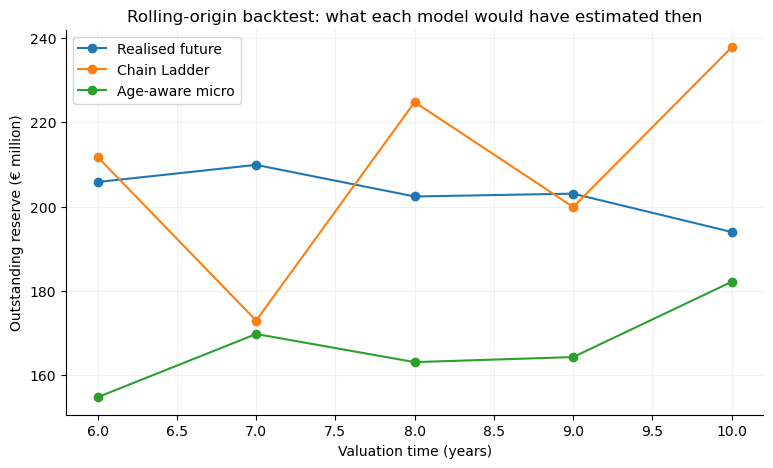

In [29]:
if RUN_ROLLING_BACKTEST:
    # CELL 28 · §16 · visual backtest
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(bt['T_years'], bt['truth'] / 1e6, marker='o', label='Realised future')
    ax.plot(bt['T_years'], bt['CL_mean'] / 1e6, marker='o', label='Chain Ladder')
    ax.plot(bt['T_years'], bt['micro_mean'] / 1e6, marker='o', label='Age-aware micro')

    ax.set_xlabel('Valuation time (years)')
    ax.set_ylabel('Outstanding reserve (€ million)')
    ax.set_title('Rolling-origin backtest: what each model would have estimated then')
    ax.legend()
    plt.show()
else:
    print('Skipped: rolling plot (RUN_ROLLING_BACKTEST=False)')


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>How to read the backtest</h3>
<p>A rolling backtest does <strong>not</strong> prove that one method is universally superior. Five dates all come from the same
simulated portfolio, so they are related observations rather than five independent insurance companies.</p>
<p>What it can reveal is more modest but still useful: whether a method persistently sits above or below the realised
future, whether the good result at year 10 is typical or exceptional, whether the micro model deteriorates with less
historical data, and whether macro and micro methods fail in different directions.</p>
<p>If the micro model consistently improves MAPE without merely switching from one systematic bias to another, the
claim-level information is demonstrably adding useful reserving information in this simulated experiment.</p>

</div>

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§17 · Why is the RBNS model systematically low?</h2>
<p>The rolling-origin backtest found something much more informative than a single good or bad prediction. The
claim-level model under-reserves RBNS at every tested valuation date, especially at the earlier dates.</p>
<p>Before changing the regression, we test a specific statistical explanation: <strong>maturity-selection bias</strong>.</p>
<p>The RBNS training table used in §16 requires a claim to satisfy two conditions:</p>
<ol>
<li>it was reported and still open at an old pseudo-valuation; and</li>
<li>it had completely closed by the later historical backtest date.</li>
</ol>
<p>Condition 2 is necessary if we want a fully observed remaining-cost target. But it can also distort the training
sample. Long-lived claims are less likely to have closed by the backtest horizon, and long-lived claims may also be
claims with unusually large remaining payments.</p>
<p>The prediction population at the backtest date does not have this restriction: it contains <em>all</em> claims still open
then. The model may therefore be trained on relatively fast-closing claims and asked to predict slower, more expensive
ones.</p>
<p>This section does <strong>not</strong> correct that problem yet. It first asks whether the data support the hypothesis.</p>

</div>

In [30]:
# CELL 29 · §17 · quantify which historical open claims enter or miss RBNS training

def censoring_snapshot(snapshot, horizon):
    # Every claim that was known and open at the old pseudo-valuation.
    open_then = claims_df[
        (claims_df['occurrence_time'] <= snapshot) &
        (claims_df['notification_time'] <= snapshot) &
        (claims_df['closure_time'] > snapshot)
    ].copy()

    # "Eligible" means its full remaining outcome had become observable by horizon.
    open_then['eligible_for_training'] = open_then['closure_time'] <= horizon

    # Because this is a simulation, we may inspect the eventual future AFTER the
    # diagnostic horizon as hidden truth. These quantities are NEVER model inputs.
    ids = open_then['claim_no'].to_numpy()

    paid_before = (
        tx[tx['claim_no'].isin(ids) & (tx['payment_time'] <= snapshot)]
        .groupby('claim_no')['payment_size'].sum()
    )
    paid_after = (
        tx[tx['claim_no'].isin(ids) & (tx['payment_time'] > snapshot)]
        .groupby('claim_no')['payment_size'].sum()
    )

    open_then = open_then.set_index('claim_no')
    open_then['paid_to_snapshot'] = paid_before.reindex(open_then.index).fillna(0.0)
    open_then['eventual_remaining'] = paid_after.reindex(open_then.index).fillna(0.0)
    open_then['age_at_snapshot'] = snapshot - open_then['occurrence_time']
    open_then['report_age_at_snapshot'] = snapshot - open_then['notification_time']
    open_then['remaining_lifetime'] = open_then['closure_time'] - snapshot
    open_then['snapshot'] = snapshot
    open_then['horizon'] = horizon

    return open_then.reset_index()


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>17.1 · How much of the historical open-claim population is excluded?</h3>
<p>For each rolling backtest date, we recreate its permitted pseudo-valuations and compare:</p>
<ul>
<li><strong>eligible claims</strong> — open at the pseudo-valuation and closed by the backtest horizon;</li>
<li><strong>censored/excluded claims</strong> — open at the pseudo-valuation but still not closed at that horizon.</li>
</ul>
<p>If the second group is tiny, censoring is unlikely to explain a 20% reserve bias. If it is material, the next question
is whether the excluded claims are systematically more expensive.</p>

</div>

In [31]:
if RUN_CENSORING_DIAGNOSTICS:
    # CELL 30 · §17 · exclusion rates by backtest horizon

    candidate_snapshots = [8., 12., 16., 20., 24., 28., 32.]
    censor_rows = []

    for T_star in BACKTEST_DATES:
        train_snapshots = [s for s in candidate_snapshots if s <= T_star - 8]

        for s in train_snapshots:
            d = censoring_snapshot(s, T_star)
            n_all = len(d)
            n_eligible = int(d['eligible_for_training'].sum())
            n_excluded = n_all - n_eligible

            censor_rows.append({
                'T_years': T_star / 4,
                'snapshot_years': s / 4,
                'open_states': n_all,
                'eligible': n_eligible,
                'excluded': n_excluded,
                'excluded_pct': n_excluded / n_all if n_all else np.nan
            })

    censor_table = pd.DataFrame(censor_rows)

    print(
        censor_table.round({'excluded_pct': 3}).to_string(index=False)
    )
else:
    print('Skipped: censoring exclusion rates (RUN_CENSORING_DIAGNOSTICS=False)')


 T_years  snapshot_years  open_states  eligible  excluded  excluded_pct
     6.0             2.0          425       331        94         0.221
     6.0             3.0          632       443       189         0.299
     6.0             4.0          748       413       335         0.448
     7.0             2.0          425       361        64         0.151
     7.0             3.0          632       510       122         0.193
     7.0             4.0          748       541       207         0.277
     7.0             5.0          823       465       358         0.435
     8.0             2.0          425       386        39         0.092
     8.0             3.0          632       558        74         0.117
     8.0             4.0          748       627       121         0.162
     8.0             5.0          823       603       220         0.267
     8.0             6.0          865       515       350         0.405
     9.0             2.0          425       403        22       

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>17.2 · Are the excluded claims more expensive?</h3>
<p>The simulation gives us a luxury unavailable in real reserving data: after the experiment is over, we can inspect the
eventual future of claims that were censored at an old valuation date.</p>
<p>That allows a direct diagnostic comparison. For every historical open-claim state we calculate its <strong>eventual remaining
payments after the pseudo-valuation</strong>. This future amount is used only here to understand the mechanism; it is not fed
back into the reserving model.</p>
<p>The important comparison is the average and median eventual remaining cost of eligible versus excluded claims. A large
positive ratio would support the hypothesis that complete-case training preferentially retains cheaper, faster-settling
claims.</p>

</div>

In [32]:
if RUN_CENSORING_DIAGNOSTICS:
    # CELL 31 · §17 · cost and lifetime comparison: eligible versus excluded

    selection_rows = []

    for T_star in BACKTEST_DATES:
        train_snapshots = [s for s in candidate_snapshots if s <= T_star - 8]

        pieces = [censoring_snapshot(s, T_star) for s in train_snapshots]
        d = pd.concat(pieces, ignore_index=True)

        eligible = d[d['eligible_for_training']]
        excluded = d[~d['eligible_for_training']]

        selection_rows.append({
            'T_years': T_star / 4,
            'states_total': len(d),
            'excluded_pct': len(excluded) / len(d),
            'eligible_mean_remaining': eligible['eventual_remaining'].mean(),
            'excluded_mean_remaining': excluded['eventual_remaining'].mean(),
            'remaining_mean_ratio': (
                excluded['eventual_remaining'].mean() /
                eligible['eventual_remaining'].mean()
            ),
            'eligible_median_remaining': eligible['eventual_remaining'].median(),
            'excluded_median_remaining': excluded['eventual_remaining'].median(),
            'eligible_mean_lifetime': eligible['remaining_lifetime'].mean(),
            'excluded_mean_lifetime': excluded['remaining_lifetime'].mean()
        })

    selection_diag = pd.DataFrame(selection_rows)

    print(
        selection_diag.round({
            'excluded_pct': 3,
            'eligible_mean_remaining': 0,
            'excluded_mean_remaining': 0,
            'remaining_mean_ratio': 2,
            'eligible_median_remaining': 0,
            'excluded_median_remaining': 0,
            'eligible_mean_lifetime': 2,
            'excluded_mean_lifetime': 2
        }).to_string(index=False)
    )
else:
    print('Skipped: censoring cost comparison (RUN_CENSORING_DIAGNOSTICS=False)')


 T_years  states_total  excluded_pct  eligible_mean_remaining  excluded_mean_remaining  remaining_mean_ratio  eligible_median_remaining  excluded_median_remaining  eligible_mean_lifetime  excluded_mean_lifetime
     6.0          1805         0.342                 145206.0                 326491.0                  2.25                    71812.0                   205583.0                    5.09                   18.12
     7.0          2628         0.286                 158527.0                 337297.0                  2.13                    77272.0                   211090.0                    5.57                   18.68
     8.0          3493         0.230                 163263.0                 375423.0                  2.30                    81753.0                   266312.0                    6.02                   19.13
     9.0          4340         0.183                 171709.0                 405259.0                  2.36                    88984.0                   28

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>17.3 · Does the bias diminish as censoring diminishes?</h3>
<p>A useful diagnostic should explain not only the sign of the error but also its pattern through time.</p>
<p>The micro RBNS errors found in §16 improve from strongly negative at early valuations toward a much smaller error at
year 10. If maturity-selection bias is important, we would expect the proportion or severity of excluded historical
claims to decline as the available history lengthens.</p>
<p>The next table puts the two quantities side by side. With only five rolling dates this is descriptive evidence, not a
formal causal test.</p>

</div>

In [33]:
if RUN_CENSORING_DIAGNOSTICS:
    # CELL 32 · §17 · connect training selection to observed RBNS backtest error

    horizon_selection = (
        censor_table.groupby('T_years')
        .apply(
            lambda g: pd.Series({
                'open_states': g['open_states'].sum(),
                'excluded_states': g['excluded'].sum(),
                'weighted_excluded_pct': g['excluded'].sum() / g['open_states'].sum()
            }),
            include_groups=False
        )
        .reset_index()
    )

    rbns_diag = bt[['T_years', 'truth_RBNS', 'micro_RBNS']].copy()
    rbns_diag['RBNS_error'] = rbns_diag['micro_RBNS'] / rbns_diag['truth_RBNS'] - 1

    selection_vs_error = rbns_diag.merge(
        horizon_selection[['T_years', 'weighted_excluded_pct']],
        on='T_years',
        how='left'
    ).merge(
        selection_diag[['T_years', 'remaining_mean_ratio']],
        on='T_years',
        how='left'
    )

    print(
        selection_vs_error.round({
            'truth_RBNS': 0,
            'micro_RBNS': 0,
            'RBNS_error': 3,
            'weighted_excluded_pct': 3,
            'remaining_mean_ratio': 2
        }).to_string(index=False)
    )
else:
    print('Skipped: censoring vs error (RUN_CENSORING_DIAGNOSTICS=False)')


 T_years  truth_RBNS  micro_RBNS  RBNS_error  weighted_excluded_pct  remaining_mean_ratio
     6.0 189987945.0 138146193.0      -0.273                  0.342                  2.25
     7.0 190034473.0 151661440.0      -0.202                  0.286                  2.13
     8.0 181685033.0 144897198.0      -0.202                  0.230                  2.30
     9.0 179444132.0 145158595.0      -0.191                  0.183                  2.36
    10.0 173999071.0 161990127.0      -0.069                  0.148                  2.04


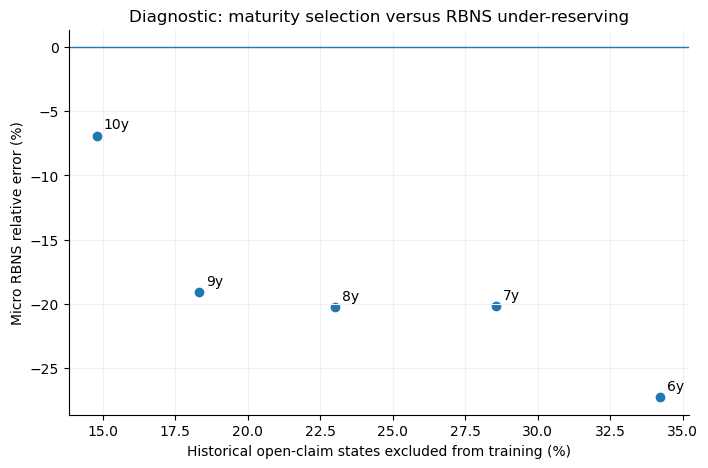

In [34]:
if RUN_CENSORING_DIAGNOSTICS:
    # CELL 33 · §17 · visual diagnostic: censoring versus RBNS error

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        selection_vs_error['weighted_excluded_pct'] * 100,
        selection_vs_error['RBNS_error'] * 100
    )

    for _, row in selection_vs_error.iterrows():
        ax.annotate(
            f"{row['T_years']:.0f}y",
            (
                row['weighted_excluded_pct'] * 100,
                row['RBNS_error'] * 100
            ),
            xytext=(5, 5),
            textcoords='offset points'
        )

    ax.axhline(0, linewidth=1)
    ax.set_xlabel('Historical open-claim states excluded from training (%)')
    ax.set_ylabel('Micro RBNS relative error (%)')
    ax.set_title('Diagnostic: maturity selection versus RBNS under-reserving')
    plt.show()
else:
    print('Skipped: censoring plot (RUN_CENSORING_DIAGNOSTICS=False)')


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>17.4 · Interpretation rule</h3>
<p>The diagnostic has three possible outcomes.</p>
<p><strong>Strong support for maturity-selection bias.</strong> Excluded claims form a material share of historical open-claim states,
have substantially larger eventual remaining costs, and the selection problem weakens as the RBNS backtest error
improves. In that case, simply tuning the Gamma regression would address the symptom rather than the mechanism. A
censoring-aware model becomes the natural next step.</p>
<p><strong>Weak or mixed support.</strong> Excluded claims are somewhat different but not enough to explain the reserve gap. Then the
RBNS specification itself needs investigation: nonlinear age effects, interaction between age and paid-to-date,
zero-versus-positive future payments, and omitted claim characteristics become plausible explanations.</p>
<p><strong>No support.</strong> If excluded and eligible claims have similar eventual costs, the censoring hypothesis should be rejected
for this experiment. The failed hypothesis remains worth reporting because it was motivated by the rolling validation
and tested directly rather than assumed.</p>
<p>This distinction matters for the eventual technical note. The objective is not to manufacture a model that matches the
simulated answer. It is to show how out-of-time validation exposes a structural weakness, how transaction-level
synthetic data permit that weakness to be diagnosed, and how the evidence determines the next modelling step.</p>

</div>

<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2>§18 · Correct the maturity-selection bias — inverse probability of censoring weighting</h2>
<h3>First: what does “censoring” mean here?</h3>
<p>Imagine standing at historical year 6 and looking at a claim that was still open at year 4.</p>
<p>If the claim has closed by year 6, we can reconstruct its <strong>complete remaining cost after year 4</strong>. That claim can be
used directly as a regression target.</p>
<p>If it is <strong>still open at year 6</strong>, however, its eventual remaining cost is not yet fully known. We only know that the
claim has remained open <em>at least</em> that long. Statisticians call this <strong>right censoring</strong>: observation stops before the
quantity of interest is completely revealed.</p>
<p>Simply deleting censored claims is safe only if they are essentially a random subset. §17 showed the opposite here:
the excluded claims have roughly twice the eventual remaining cost of the claims that happened to close in time.
Therefore the availability of the target is <strong>informative</strong>.</p>
<h3>The correction used here: IPCW</h3>
<p>A standard response to informative censoring is <strong>inverse probability of censoring weighting (IPCW)</strong>.</p>
<p>The intuition is straightforward:</p>
<ol>
<li>Use <em>all</em> historical open-claim states — both complete and censored — to estimate the probability that a claim with
those observed characteristics will become fully observable by the horizon.</li>
<li>Fit the remaining-cost Gamma regression only where the target is actually complete.</li>
<li>Give a complete claim more weight when claims like it had a <strong>low probability of becoming complete</strong>.</li>
</ol>
<p>If a difficult, long-lived claim had only a 25% estimated chance of closing by the horizon, a comparable observed claim
represents roughly four such claim states and receives weight about 1 / 0.25 = 4.</p>
<p>This does not recover information magically. It relies on an important assumption: after conditioning on the variables
in the censoring model, the remaining unobserved censoring mechanism is not still related to remaining cost. The method
is therefore a principled correction, not a guarantee.</p>
<p>The implementation below estimates the observation probability with logistic regression and passes the resulting
inverse-probability weights to <code>GammaRegressor</code>. Probabilities are floored at 0.05, limiting any one weight to 20; this
prevents a handful of near-zero fitted probabilities from dominating the regression.</p>
<p><strong>Methodological lineage.</strong> IPCW is a standard family of methods for regression with censored/missing outcomes; see
Robins, Rotnitzky &amp; Zhao (1995), <em>JASA</em> 90, 106–121, and Robins &amp; Finkelstein (2000), <em>Biometrics</em> 56, 779–788.</p>

</div>

In [35]:
# CELL 34 · §18 · build all historical open-claim states, including censored ones

from sklearn.linear_model import LogisticRegression

CENSOR_FEATURES = [
    'age_occ',
    'age_report',
    'log_paid',
    'n_payments',
    'since_last_payment',
    'log_avg_payment',
    'followup_available'
]

def open_state_table(snapshot, horizon):
    # All claims known and open at the old snapshot: complete OR censored by horizon.
    states = claims_df[
        (claims_df['occurrence_time'] <= snapshot) &
        (claims_df['notification_time'] <= snapshot) &
        (claims_df['closure_time'] > snapshot)
    ].copy()

    ids = states['claim_no'].to_numpy()

    obs = tx[
        tx['claim_no'].isin(ids) &
        (tx['payment_time'] <= snapshot)
    ]
    obs_stats = obs.groupby('claim_no').agg(
        paid_to_date=('payment_size', 'sum'),
        n_payments=('payment_size', 'size'),
        last_payment_time=('payment_time', 'max'),
        avg_payment=('payment_size', 'mean')
    )

    # A target is complete only when the claim closes by the historical horizon.
    states['complete_target'] = states['closure_time'] <= horizon

    # Remaining payments are used as a regression target ONLY for complete_target == True.
    fut_complete = tx[
        tx['claim_no'].isin(ids) &
        (tx['payment_time'] > snapshot) &
        (tx['payment_time'] <= horizon)
    ].groupby('claim_no')['payment_size'].sum()

    d = states.set_index('claim_no').join(obs_stats)
    d['paid_to_date'] = d['paid_to_date'].fillna(0.0)
    d['n_payments'] = d['n_payments'].fillna(0)
    d['avg_payment'] = d['avg_payment'].fillna(0.0)

    d['age_occ'] = snapshot - d['occurrence_time']
    d['age_report'] = snapshot - d['notification_time']
    d['since_last_payment'] = snapshot - d['last_payment_time']
    d['since_last_payment'] = d['since_last_payment'].fillna(d['age_report'])
    d['log_paid'] = np.log1p(d['paid_to_date'])
    d['log_avg_payment'] = np.log1p(d['avg_payment'])
    d['followup_available'] = horizon - snapshot

    d['remaining'] = fut_complete.reindex(d.index)
    d.loc[~d['complete_target'], 'remaining'] = np.nan
    d['snapshot'] = snapshot
    d['horizon'] = horizon

    return d.reset_index()


def current_rbns_features(T_star, obs, inc):
    rbns_now = inc[inc['open_at_T']].copy()
    ids = rbns_now['claim_no'].to_numpy()

    obs_stats = obs[obs['claim_no'].isin(ids)].groupby('claim_no').agg(
        paid_to_date=('payment_size', 'sum'),
        n_payments=('payment_size', 'size'),
        last_payment_time=('payment_time', 'max'),
        avg_payment=('payment_size', 'mean')
    )

    cur = rbns_now.set_index('claim_no').join(obs_stats)
    cur['paid_to_date'] = cur['paid_to_date'].fillna(0.0)
    cur['n_payments'] = cur['n_payments'].fillna(0)
    cur['avg_payment'] = cur['avg_payment'].fillna(0.0)

    cur['age_occ'] = T_star - cur['occurrence_time']
    cur['age_report'] = T_star - cur['notification_time']
    cur['since_last_payment'] = T_star - cur['last_payment_time']
    cur['since_last_payment'] = cur['since_last_payment'].fillna(cur['age_report'])
    cur['log_paid'] = np.log1p(cur['paid_to_date'])
    cur['log_avg_payment'] = np.log1p(cur['avg_payment'])

    return cur


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>18.1 · Fit the censoring model and the weighted Gamma model</h3>
<p>The first model predicts <strong>whether the remaining-cost target becomes fully observable by the backtest horizon</strong>.
Its predictors are deliberately the same claim-state variables available to the reserving model, plus the amount of
follow-up time between the pseudo-valuation and the horizon.</p>
<p>Only complete rows enter the Gamma regression, because only they have a known final remaining cost. But they no longer
all count equally. Their weights are:</p>
<div class="phnx-formula" style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
weight = 1 / estimated probability that the target becomes complete
</div>

<p>A claim that was easy to observe receives a weight near 1. A rare observed example of a state that was usually censored
receives more influence.</p>

</div>

In [36]:
# CELL 35 · §18 · IPCW RBNS estimator for one historical horizon

def fit_ipcw_rbns(T_star):
    candidate_snapshots = [8., 12., 16., 20., 24., 28., 32.]
    train_snapshots = [s for s in candidate_snapshots if s <= T_star - 8]

    all_states = pd.concat(
        [open_state_table(s, T_star) for s in train_snapshots],
        ignore_index=True
    )

    # Selection/censoring model uses BOTH complete and censored states.
    censor_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, C=1.0)
    )
    censor_model.fit(
        all_states[CENSOR_FEATURES],
        all_states['complete_target'].astype(int)
    )

    p_complete = censor_model.predict_proba(all_states[CENSOR_FEATURES])[:, 1]
    all_states['p_complete'] = np.clip(p_complete, 0.05, 1.0)

    complete = all_states[all_states['complete_target']].copy()
    complete['ipcw'] = 1.0 / complete['p_complete']

    # Weighted outcome regression. sample_weight is supported by GammaRegressor.
    scaler = StandardScaler()
    X_complete = scaler.fit_transform(complete[RBNS_FEATURES])

    gamma_ipcw = GammaRegressor(alpha=0.20, max_iter=5000)
    gamma_ipcw.fit(
        X_complete,
        complete['remaining'],
        sample_weight=complete['ipcw']
    )

    inc, obs, fut, truth, truth_rbns, truth_ibnr = make_truth_at(T_star)
    cur = current_rbns_features(T_star, obs, inc)
    X_cur = scaler.transform(cur[RBNS_FEATURES])
    cur['pred_ipcw'] = gamma_ipcw.predict(X_cur)

    diagnostics = {
        'n_states': len(all_states),
        'complete_pct': all_states['complete_target'].mean(),
        'weight_median': complete['ipcw'].median(),
        'weight_p95': complete['ipcw'].quantile(0.95),
        'weight_max': complete['ipcw'].max(),
    }

    return cur['pred_ipcw'].sum(), diagnostics


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>18.2 · First check at year 10</h3>
<p>We first apply the correction to the same year-10 valuation that motivated the investigation. This is <strong>not</strong> the main
test, because year 10 has already been examined repeatedly. The decisive test remains the rolling backtest in §18.3.</p>
<p>The weight diagnostics matter. If the maximum or 95th-percentile weight is enormous, the correction may be numerically
unstable and overly dependent on a few observations.</p>

</div>

In [37]:
if RUN_IPCW:
    # CELL 36 · §18 · year-10 IPCW diagnostic

    rbns_ipcw_40, wdiag_40 = fit_ipcw_rbns(40.0)

    print(f"complete historical states : {wdiag_40['complete_pct']:.1%}")
    print(f"IPCW median / p95 / max    : "
          f"{wdiag_40['weight_median']:.2f} / "
          f"{wdiag_40['weight_p95']:.2f} / "
          f"{wdiag_40['weight_max']:.2f}")
    print()
    print(f"complete-case RBNS mean    : {bt.loc[bt['T_years']==10.0, 'micro_RBNS'].iloc[0]:,.0f}")
    print(f"IPCW-corrected RBNS mean   : {rbns_ipcw_40:,.0f}")
    print(f"TRUE RBNS future           : {bt.loc[bt['T_years']==10.0, 'truth_RBNS'].iloc[0]:,.0f}")
else:
    print('Skipped: IPCW year-10 (RUN_IPCW=False)')


Skipped: IPCW year-10 (RUN_IPCW=False)


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>18.3 · The real test: repeat the rolling-origin backtest</h3>
<p>A correction motivated by the year-10 result is convincing only if it helps at the earlier dates where the original
micro model failed.</p>
<p>For each valuation date we therefore compare:</p>
<ul>
<li><strong>Chain Ladder</strong> — macro benchmark;</li>
<li><strong>complete-case micro</strong> — the model that showed systematic RBNS under-reserving;</li>
<li><strong>IPCW micro</strong> — identical IBNR methodology, but RBNS regression corrected for differential observability;</li>
<li><strong>realised future</strong> — hidden until validation.</li>
</ul>
<p>No calibration factor is fitted to the realised reserves.</p>

</div>

In [38]:
if RUN_IPCW:
    # CELL 37 · §18 · rolling IPCW backtest

    ipcw_rows = []

    for T_star in BACKTEST_DATES:
        rbns_ipcw, wdiag = fit_ipcw_rbns(T_star)

        base_row = bt.loc[bt['T_quarters'] == T_star].iloc[0]

        # Keep the same causal IBNR estimate from the rolling backtest.
        ibnr_mean = base_row['micro_IBNR']
        total_ipcw = rbns_ipcw + ibnr_mean

        ipc_row = {
            'T_years': T_star / 4,
            'truth': base_row['truth'],
            'CL_mean': base_row['CL_mean'],
            'complete_case_micro': base_row['micro_mean'],
            'IPCW_micro': total_ipcw,
            'truth_RBNS': base_row['truth_RBNS'],
            'complete_case_RBNS': base_row['micro_RBNS'],
            'IPCW_RBNS': rbns_ipcw,
            'micro_IBNR': ibnr_mean,
            'complete_pct': wdiag['complete_pct'],
            'weight_p95': wdiag['weight_p95'],
            'weight_max': wdiag['weight_max']
        }
        ipcw_rows.append(ipc_row)

    bt_ipcw = pd.DataFrame(ipcw_rows)

    bt_ipcw['CL_error'] = bt_ipcw['CL_mean'] / bt_ipcw['truth'] - 1
    bt_ipcw['complete_case_error'] = bt_ipcw['complete_case_micro'] / bt_ipcw['truth'] - 1
    bt_ipcw['IPCW_error'] = bt_ipcw['IPCW_micro'] / bt_ipcw['truth'] - 1

    print(
        bt_ipcw[[
            'T_years', 'truth',
            'CL_mean', 'complete_case_micro', 'IPCW_micro',
            'CL_error', 'complete_case_error', 'IPCW_error',
            'weight_p95'
        ]].round({
            'truth': 0,
            'CL_mean': 0,
            'complete_case_micro': 0,
            'IPCW_micro': 0,
            'CL_error': 3,
            'complete_case_error': 3,
            'IPCW_error': 3,
            'weight_p95': 2
        }).to_string(index=False)
    )
else:
    print('Skipped: IPCW rolling (RUN_IPCW=False)')


Skipped: IPCW rolling (RUN_IPCW=False)


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>18.4 · Compare systematic accuracy</h3>
<p>The correction succeeds only if it improves the <strong>out-of-time pattern</strong>, not merely the terminal point.</p>
<p>We again report bias and MAPE. The complete-case micro result is deliberately retained: a failed intermediate method
is part of the scientific argument because it shows why the censoring correction was introduced.</p>

</div>

In [39]:
if RUN_IPCW:
    # CELL 38 · §18 · bias / MAPE comparison after censoring correction

    metric_rows = []

    for label, col in [
        ('Chain Ladder', 'CL_error'),
        ('Complete-case micro', 'complete_case_error'),
        ('IPCW micro', 'IPCW_error')
    ]:
        e = bt_ipcw[col]
        metric_rows.append({
            'model': label,
            'mean_relative_bias': e.mean(),
            'MAPE': e.abs().mean(),
            'median_absolute_pct_error': e.abs().median()
        })

    ipcw_metrics = pd.DataFrame(metric_rows)
    print(ipcw_metrics.round(3).to_string(index=False))
else:
    print('Skipped: IPCW metrics (RUN_IPCW=False)')


Skipped: IPCW metrics (RUN_IPCW=False)


In [40]:
if RUN_IPCW:
    # CELL 39 · §18 · visual comparison of the correction

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(bt_ipcw['T_years'], bt_ipcw['truth'] / 1e6, marker='o', label='Realised future')
    ax.plot(bt_ipcw['T_years'], bt_ipcw['CL_mean'] / 1e6, marker='o', label='Chain Ladder')
    ax.plot(bt_ipcw['T_years'], bt_ipcw['complete_case_micro'] / 1e6,
            marker='o', label='Complete-case micro')
    ax.plot(bt_ipcw['T_years'], bt_ipcw['IPCW_micro'] / 1e6,
            marker='o', label='IPCW micro')

    ax.set_xlabel('Valuation time (years)')
    ax.set_ylabel('Outstanding reserve (€ million)')
    ax.set_title('Rolling-origin backtest: effect of censoring correction')
    ax.legend()
    plt.show()
else:
    print('Skipped: IPCW plot (RUN_IPCW=False)')


Skipped: IPCW plot (RUN_IPCW=False)


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>18.5 · What IPCW does — and does not — establish</h3>
<p>If IPCW materially reduces the persistent downward bias, the experiment supports the mechanism diagnosed in §17:
complete-case training was under-representing difficult, long-lived claims.</p>
<p>If it does not improve the rolling backtest, we should <strong>not</strong> tune the weights to force improvement. That would mean
either:</p>
<ul>
<li>the censoring model does not capture enough of the informative selection;</li>
<li>the conditional-independent-censoring assumption is inadequate;</li>
<li>or other RBNS model misspecification matters as much as censoring.</li>
</ul>
<p>Possible next methods would then include an explicit survival/time-to-closure model, joint modelling of payment process
and settlement, or richer non-linear claim-state effects.</p>
<p>This is deliberately a staged investigation: diagnose first, apply a statistically motivated correction second, and
judge it only by out-of-time performance.</p>

</div>

<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§19 · A survival-aware RBNS model — use the fact that a claim is still open</h2>
<p><strong>Why move beyond IPCW?</strong> Section §17 showed that censoring is informative: long-lived claims are
more likely to be excluded from complete-case training and have much larger eventual remaining cost. Section §18 then
tested IPCW, a standard reweighting correction. It failed the rolling backtest and made the downward bias slightly
worse.</p>

<p>That suggests that “still being open” is not merely a nuisance to be corrected away. It is itself useful actuarial
information. A claim that has survived open for another three years is telling us something about its development.</p>

<p>v1.0 therefore models the problem structurally in two pieces:</p>

<ol>
<li><strong>Time to closure.</strong> How long is a currently open claim expected to remain open?</li>
<li><strong>Cost rate while open.</strong> How much future payment is associated, on average, with each remaining
quarter of open lifetime?</li>
</ol>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;
padding:9px 12px !important;margin:10px auto !important;text-align:center !important;
font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
Predicted remaining cost ≈ predicted remaining open lifetime × predicted cost per open quarter
</div>

<p>The first component is a <strong>discrete-time survival model</strong>. A censored claim contributes valid
information: it tells us that closure did <em>not</em> occur during each observed quarter. We no longer need to delete
that claim simply because its final closure lies beyond the historical horizon.</p>

<p>The second component still needs fully observed remaining cost, but it models a <em>rate</em> rather than the whole
remaining amount. If the main selection problem operates through duration, separating duration from payment rate should
reduce the maturity bias.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>19.1 · What is a survival model?</h2>
<p>A survival model was developed for questions such as “how long until death?”, but the mathematics applies to any
time-to-event problem. Here the event is simply <strong>claim closure</strong>.</p>

<p>At the start of a future quarter, an open claim has a probability of closing during that quarter. This is called the
<strong>hazard</strong>. We estimate that probability from historical claim states using logistic regression.</p>

<p>If the estimated closure hazards for the next quarters are h<sub>1</sub>, h<sub>2</sub>, …, then the probability
that the claim is still open at the start of quarter k is obtained by repeatedly surviving the previous quarters:</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;
padding:9px 12px !important;margin:10px auto !important;text-align:center !important;
font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
S<sub>1</sub> = 1, &nbsp;
S<sub>2</sub> = (1 − h<sub>1</sub>), &nbsp;
S<sub>3</sub> = (1 − h<sub>1</sub>)(1 − h<sub>2</sub>), …
</div>

<p>Adding those survival probabilities over future quarters gives the expected number of additional open quarters.
A claim still open at the observation horizon is therefore not thrown away: every quarter in which it remained open
contributes a “did not close yet” observation.</p>
</div>


In [41]:
# CELL 40 · §19 · create discrete-time survival training rows

SURVIVAL_FEATURES = [
    'age_occ',
    'age_report',
    'log_paid',
    'n_payments',
    'since_last_payment',
    'log_avg_payment',
    'elapsed_since_snapshot'
]

def survival_rows_from_state_table(states, horizon):
    rows = []

    for _, r in states.iterrows():
        # Observed follow-up after the pseudo-valuation.
        end_time = min(r['closure_time'], horizon)
        followup = max(end_time - r['snapshot'], 0.0)

        # At least one interval if some positive follow-up is observed.
        n_intervals = int(np.ceil(followup))
        if n_intervals <= 0:
            continue

        closed_by_horizon = r['closure_time'] <= horizon

        for k in range(n_intervals):
            interval_start = r['snapshot'] + k

            # If true closure occurs during this interval, event_close = 1.
            event_close = int(
                closed_by_horizon and
                (r['closure_time'] > interval_start) and
                (r['closure_time'] <= interval_start + 1.0)
            )

            rows.append({
                'claim_no': r['claim_no'],
                'snapshot': r['snapshot'],
                'age_occ': r['age_occ'] + k,
                'age_report': r['age_report'] + k,
                'log_paid': r['log_paid'],
                'n_payments': r['n_payments'],
                'since_last_payment': r['since_last_payment'] + k,
                'log_avg_payment': r['log_avg_payment'],
                'elapsed_since_snapshot': float(k),
                'event_close': event_close
            })

            if event_close:
                break

    return pd.DataFrame(rows)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>19.2 · Cost per remaining open quarter</h2>
<p>For historical states whose full outcome is known, we can divide eventual remaining payments by the actual remaining
open lifetime. This gives a simple <strong>remaining cost rate</strong>.</p>

<p>Example: if a claim paid €300,000 after the pseudo-valuation and remained open for 12 more quarters, its average
remaining cost rate is €25,000 per open quarter.</p>

<p>This decomposition is intentionally simple. Payments do not truly arrive smoothly each quarter. The rate is only a
device for separating <strong>how long the claim remains active</strong> from <strong>how expensive its active period
is</strong>. If the censoring problem mainly removed long-duration claims, this decomposition should be more robust than
predicting total remaining cost directly.</p>
</div>


In [42]:
# CELL 41 · §19 · build survival-aware RBNS training data

def fit_survival_aware_rbns(T_star):
    candidate_snapshots = [8., 12., 16., 20., 24., 28., 32.]
    train_snapshots = [s for s in candidate_snapshots if s <= T_star - 8]

    state_tables = [open_state_table(s, T_star) for s in train_snapshots]
    states = pd.concat(state_tables, ignore_index=True)

    # ----- 1) Discrete-time closure model: ALL states, including censored -----
    surv_rows = survival_rows_from_state_table(states, T_star)

    closure_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, C=1.0)
    )
    closure_model.fit(
        surv_rows[SURVIVAL_FEATURES],
        surv_rows['event_close']
    )

    # ----- 2) Remaining-cost-rate model: fully observed states only -----
    complete = states[states['complete_target']].copy()

    actual_remaining_lifetime = complete['closure_time'] - complete['snapshot']
    complete['remaining_lifetime'] = np.maximum(actual_remaining_lifetime, 0.25)
    complete['cost_rate'] = complete['remaining'] / complete['remaining_lifetime']

    # Positive Gamma target; zero-rate cases are extremely rare, but floor safely.
    complete['cost_rate'] = np.maximum(complete['cost_rate'], 1.0)

    rate_model = make_pipeline(
        StandardScaler(),
        GammaRegressor(alpha=0.20, max_iter=5000)
    )
    rate_model.fit(
        complete[RBNS_FEATURES],
        complete['cost_rate']
    )

    # ----- Current open RBNS states -----
    inc, obs, fut, truth, truth_rbns, truth_ibnr = make_truth_at(T_star)
    current = current_rbns_features(T_star, obs, inc)

    # Expected remaining lifetime from the survival model.
    MAX_FUTURE_Q = 60
    expected_lifetimes = []

    for _, r in current.iterrows():
        survival_prob = 1.0
        expected_q = 0.0

        for k in range(MAX_FUTURE_Q):
            # Probability claim is still open at the start of this future quarter.
            expected_q += survival_prob

            Xk = pd.DataFrame([{
                'age_occ': r['age_occ'] + k,
                'age_report': r['age_report'] + k,
                'log_paid': r['log_paid'],
                'n_payments': r['n_payments'],
                'since_last_payment': r['since_last_payment'] + k,
                'log_avg_payment': r['log_avg_payment'],
                'elapsed_since_snapshot': float(k)
            }])

            h = closure_model.predict_proba(Xk[SURVIVAL_FEATURES])[:, 1][0]
            survival_prob *= (1.0 - h)

            if survival_prob < 1e-5:
                break

        expected_lifetimes.append(expected_q)

    current['pred_remaining_lifetime'] = expected_lifetimes
    current['pred_cost_rate'] = rate_model.predict(current[RBNS_FEATURES])
    current['pred_survival_rbns'] = (
        current['pred_remaining_lifetime'] * current['pred_cost_rate']
    )

    diagnostics = {
        'n_states': len(states),
        'n_survival_rows': len(surv_rows),
        'complete_pct': states['complete_target'].mean(),
        'mean_pred_lifetime': current['pred_remaining_lifetime'].mean(),
        'max_pred_lifetime': current['pred_remaining_lifetime'].max(),
    }

    return current['pred_survival_rbns'].sum(), current, diagnostics


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>19.3 · First check at year 10</h2>
<p>As before, year 10 is only a diagnostic because we have already looked at that hidden future many times. The more
important evidence is the rolling-origin backtest in §19.4.</p>

<p>Two intermediate quantities are worth inspecting:</p>

<ul>
<li>the predicted mean remaining lifetime of current RBNS claims;</li>
<li>whether the 60-quarter forecasting cap is being hit.</li>
</ul>

<p>If many claims hit the cap, the survival forecast is not long enough and must be extended before interpreting the
reserve.</p>
</div>


In [43]:
if RUN_SURVIVAL_RATE:
    # CELL 42 · §19 · year-10 survival-aware RBNS diagnostic

    rbns_surv_40, current_surv_40, surv_diag_40 = fit_survival_aware_rbns(40.0)

    print(f"historical open states       : {surv_diag_40['n_states']:,}")
    print(f"survival person-quarter rows : {surv_diag_40['n_survival_rows']:,}")
    print(f"complete outcome share       : {surv_diag_40['complete_pct']:.1%}")
    print(f"mean predicted life remaining: {surv_diag_40['mean_pred_lifetime']:.2f} quarters")
    print(f"max predicted life remaining : {surv_diag_40['max_pred_lifetime']:.2f} quarters")
    print()
    print(f"complete-case RBNS mean      : {bt.loc[bt['T_years']==10.0, 'micro_RBNS'].iloc[0]:,.0f}")
    print(f"IPCW RBNS mean               : {bt_ipcw.loc[bt_ipcw['T_years']==10.0, 'IPCW_RBNS'].iloc[0]:,.0f}")
    print(f"survival-aware RBNS mean     : {rbns_surv_40:,.0f}")
    print(f"TRUE RBNS future             : {bt.loc[bt['T_years']==10.0, 'truth_RBNS'].iloc[0]:,.0f}")
else:
    print('Skipped: survival-rate year-10 (RUN_SURVIVAL_RATE=False)')


Skipped: survival-rate year-10 (RUN_SURVIVAL_RATE=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>19.4 · The decisive test: rolling-origin backtest</h2>
<p>The survival-aware model was motivated <em>before</em> seeing these results: the censoring diagnostic showed that
complete-case training preferentially removed long-duration, expensive claims, while IPCW failed to repair the outcome
model.</p>

<p>We now repeat the same five historical valuations. The IBNR component is unchanged so that any improvement can be
attributed to the RBNS methodology rather than to simultaneously changing several parts of the model.</p>
</div>


In [44]:
if RUN_SURVIVAL_RATE:
    # CELL 43 · §19 · rolling survival-aware RBNS backtest

    surv_rows_out = []

    for T_star in BACKTEST_DATES:
        rbns_surv, current_surv, diag = fit_survival_aware_rbns(T_star)
        base = bt_ipcw.loc[bt_ipcw['T_years'] == T_star / 4].iloc[0]

        total_surv = rbns_surv + base['micro_IBNR']

        surv_rows_out.append({
            'T_years': T_star / 4,
            'truth': base['truth'],
            'CL_mean': base['CL_mean'],
            'complete_case_micro': base['complete_case_micro'],
            'IPCW_micro': base['IPCW_micro'],
            'survival_micro': total_surv,
            'truth_RBNS': base['truth_RBNS'],
            'complete_case_RBNS': base['complete_case_RBNS'],
            'IPCW_RBNS': base['IPCW_RBNS'],
            'survival_RBNS': rbns_surv,
            'micro_IBNR': base['micro_IBNR'],
            'mean_pred_lifetime': diag['mean_pred_lifetime']
        })

    bt_surv = pd.DataFrame(surv_rows_out)

    for name, col in [
        ('CL_error', 'CL_mean'),
        ('complete_case_error', 'complete_case_micro'),
        ('IPCW_error', 'IPCW_micro'),
        ('survival_error', 'survival_micro')
    ]:
        bt_surv[name] = bt_surv[col] / bt_surv['truth'] - 1

    print(
        bt_surv[[
            'T_years', 'truth',
            'CL_mean', 'complete_case_micro', 'IPCW_micro', 'survival_micro',
            'CL_error', 'complete_case_error', 'IPCW_error', 'survival_error',
            'mean_pred_lifetime'
        ]].round({
            'truth': 0,
            'CL_mean': 0,
            'complete_case_micro': 0,
            'IPCW_micro': 0,
            'survival_micro': 0,
            'CL_error': 3,
            'complete_case_error': 3,
            'IPCW_error': 3,
            'survival_error': 3,
            'mean_pred_lifetime': 2
        }).to_string(index=False)
    )
else:
    print('Skipped: survival-rate rolling (RUN_SURVIVAL_RATE=False)')


Skipped: survival-rate rolling (RUN_SURVIVAL_RATE=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>19.5 · Compare bias and MAPE across all four approaches</h2>
<p>The model should be judged by the rolling-origin pattern, not by whether year 10 happens to look attractive.</p>

<p>The table retains every major step in the investigation:</p>

<ul>
<li><strong>Chain Ladder</strong> — aggregate benchmark;</li>
<li><strong>complete-case micro</strong> — systematically low;</li>
<li><strong>IPCW micro</strong> — statistically motivated but empirically worse;</li>
<li><strong>survival-aware micro</strong> — structural use of censored open-claim information.</li>
</ul>
</div>


In [45]:
if RUN_SURVIVAL_RATE:
    # CELL 44 · §19 · rolling accuracy summary

    metric_rows = []

    for label, col in [
        ('Chain Ladder', 'CL_error'),
        ('Complete-case micro', 'complete_case_error'),
        ('IPCW micro', 'IPCW_error'),
        ('Survival-aware micro', 'survival_error')
    ]:
        e = bt_surv[col]
        metric_rows.append({
            'model': label,
            'mean_relative_bias': e.mean(),
            'MAPE': e.abs().mean(),
            'median_absolute_pct_error': e.abs().median()
        })

    surv_metrics = pd.DataFrame(metric_rows)
    print(surv_metrics.round(3).to_string(index=False))
else:
    print('Skipped: survival-rate metrics (RUN_SURVIVAL_RATE=False)')


Skipped: survival-rate metrics (RUN_SURVIVAL_RATE=False)


In [46]:
if RUN_SURVIVAL_RATE:
    # CELL 45 · §19 · visual comparison

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(bt_surv['T_years'], bt_surv['truth'] / 1e6, marker='o', label='Realised future')
    ax.plot(bt_surv['T_years'], bt_surv['CL_mean'] / 1e6, marker='o', label='Chain Ladder')
    ax.plot(bt_surv['T_years'], bt_surv['complete_case_micro'] / 1e6,
            marker='o', label='Complete-case micro')
    ax.plot(bt_surv['T_years'], bt_surv['IPCW_micro'] / 1e6,
            marker='o', label='IPCW micro')
    ax.plot(bt_surv['T_years'], bt_surv['survival_micro'] / 1e6,
            marker='o', label='Survival-aware micro')

    ax.set_xlabel('Valuation time (years)')
    ax.set_ylabel('Outstanding reserve (€ million)')
    ax.set_title('Rolling-origin backtest: structural treatment of censoring')
    ax.legend()
    plt.show()
else:
    print('Skipped: survival-rate plot (RUN_SURVIVAL_RATE=False)')


Skipped: survival-rate plot (RUN_SURVIVAL_RATE=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>19.6 · Interpretation discipline</h2>
<p>If the survival-aware model improves the rolling MAPE and reduces the persistent negative bias, that supports the
idea that <strong>duration itself was carrying reserve information that complete-case regression and IPCW were not using
adequately</strong>.</p>

<p>If it fails, the result remains useful. It would tell us that separating duration and cost rate is too crude, and the
next step should be a genuinely joint payment-process model: probability of a payment, payment amount, and closure
evolving together quarter by quarter.</p>

<p>No multiplicative calibration to the hidden realised reserve is introduced. The point of the experiment is to let
out-of-time evidence decide whether each statistically motivated change helps.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§20 · Model the payment process itself</h2>
<p>The previous experiments progressively revealed why predicting one ultimate RBNS number is difficult:</p>
<ul>
<li>the complete-case Gamma model under-reserved because long-lived claims were under-represented;</li>
<li>IPCW reweighted completed claims but did not recover the missing outcome structure;</li>
<li>the survival × cost-rate decomposition over-reserved because duration and payment intensity were not separable.</li>
</ul>
<p>The transaction data suggest a more natural formulation. Claims generate a <strong>sequence of payments over time</strong>.</p>
<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
Expected reserve for one open claim ≈ Σ over future quarters
[ probability still open × probability of payment × expected payment amount ]
</div>
<p>For every historically observed claim-quarter we construct three targets: payment/no payment next quarter,
payment amount conditional on a positive payment, and closure/no closure. Censored claims contribute every observed
quarter before the horizon instead of being discarded.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>20.1 · Turn claim histories into one row per open quarter</h2>
<p>At the beginning of each observed quarter we record only information then available: claim age, time since
notification, cumulative paid amount, number of payments, time since last payment and average payment size so far.</p>
<p>The target concerns the <em>next</em> quarter. No latent `claim_size`, future payment or future closure date is used
as a predictor.</p>
</div>


In [47]:
# CELL 46 · §20 · fast transaction-level person-quarter training rows

# Pre-index transaction histories ONCE. This avoids re-scanning the full tx DataFrame
# for every claim and every historical valuation.
TX_BY_CLAIM = {}
for claim_no, g in tx.groupby('claim_no', sort=False):
    gg = g.sort_values('payment_time')
    TX_BY_CLAIM[int(claim_no)] = {
        'time': gg['payment_time'].to_numpy(dtype=float),
        'size': gg['payment_size'].to_numpy(dtype=float),
    }

def claim_state_from_arrays(claim_row, q_start, times, sizes):
    k = np.searchsorted(times, q_start, side='right')

    if k > 0:
        past_sizes = sizes[:k]
        paid = past_sizes.sum()
        n_pmt = k
        avg_pmt = paid / n_pmt
        last_time = times[k-1]
        since_last = q_start - last_time
    else:
        paid = 0.0
        n_pmt = 0
        avg_pmt = 0.0
        since_last = max(q_start - claim_row['notification_time'], 0.0)

    return {
        'age_occ': q_start - claim_row['occurrence_time'],
        'age_report': q_start - claim_row['notification_time'],
        'paid_to_date': paid,
        'log_paid': np.log1p(paid),
        'n_payments': float(n_pmt),
        'since_last_payment': since_last,
        'avg_payment': avg_pmt,
        'log_avg_payment': np.log1p(avg_pmt)
    }


def build_process_rows(T_star, show_progress=False):
    hist_claims = claims_df[
        (claims_df['notification_time'] < T_star) &
        (claims_df['occurrence_time'] <= T_star)
    ].copy()

    rows = []

    iterator = hist_claims.itertuples(index=False)
    if show_progress and 'tqdm' in globals() and tqdm is not None:
        iterator = tqdm(
            iterator,
            total=len(hist_claims),
            desc=f"Build process rows T={T_star:g}",
            unit="claim",
            dynamic_ncols=True
        )

    for claim in iterator:
        claim_no = int(claim.claim_no)
        h = TX_BY_CLAIM.get(claim_no)
        if h is None:
            continue

        times = h['time']
        sizes = h['size']

        claim_row = {
            'occurrence_time': claim.occurrence_time,
            'notification_time': claim.notification_time,
            'closure_time': claim.closure_time
        }

        q = np.floor(claim.notification_time)
        last_start = min(claim.closure_time, T_star) - 1e-9

        while q < last_start and q < T_star:
            q_end = min(q + 1.0, T_star)

            if q >= claim.notification_time:
                state = claim_state_from_arrays(claim_row, q, times, sizes)

                i0 = np.searchsorted(times, q, side='right')
                i1 = np.searchsorted(times, q_end, side='right')
                next_pmt = sizes[i0:i1].sum() if i1 > i0 else 0.0

                closes_next = int(
                    (claim.closure_time > q) &
                    (claim.closure_time <= q_end) &
                    (claim.closure_time <= T_star)
                )

                rows.append({
                    'claim_no': claim_no,
                    'quarter_start': q,
                    **state,
                    'has_payment': int(next_pmt > 0),
                    'payment_amount': float(next_pmt),
                    'closes_next': closes_next
                })

            q += 1.0

    return pd.DataFrame(rows)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>20.2 · Three small models rather than one huge target</h2>
<p><strong>Payment occurrence:</strong> logistic regression estimates whether at least one payment occurs next quarter.</p>
<p><strong>Payment severity:</strong> Gamma regression estimates total payment in that quarter, conditional on a payment.</p>
<p><strong>Closure:</strong> logistic regression estimates whether the claim closes during that quarter.</p>
<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
Expected payment next quarter =
P(still open at quarter start) × P(payment) × E(payment amount | payment)
</div>
</div>


In [48]:
# CELL 47 · §20 · fit quarterly payment and closure models

def fit_payment_process_models(T_star, show_progress=False):
    t0 = time.perf_counter() if 'time' in globals() else None

    process = build_process_rows(T_star, show_progress=show_progress)

    if show_progress:
        print(f"  process rows built: {len(process):,}")

    pay_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, C=1.0)
    )
    pay_model.fit(process[PROCESS_FEATURES], process['has_payment'])

    positive = process[process['has_payment'] == 1].copy()
    amount_model = make_pipeline(
        StandardScaler(),
        GammaRegressor(alpha=0.20, max_iter=5000)
    )
    amount_model.fit(
        positive[PROCESS_FEATURES],
        np.maximum(positive['payment_amount'], 1.0)
    )

    closure_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, C=1.0)
    )
    closure_model.fit(process[PROCESS_FEATURES], process['closes_next'])

    if show_progress and t0 is not None:
        print(f"  model fitting complete in {time.perf_counter()-t0:.1f}s")

    return process, pay_model, amount_model, closure_model


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>20.3 · Forecast an open claim quarter by quarter</h2>
<p>Prediction is recursive. At each future quarter the model estimates payment probability, payment amount and closure
probability.</p>
<p>The future claim state is not known exactly, so we use a transparent <strong>mean-field update</strong>: cumulative
paid amount increases by the expected payment, expected payment count increases by the payment probability, and time
since last payment evolves using its expected reset/no-reset value.</p>
<p>This is still an approximation. If it fails, the next candidate would be a full stochastic path simulation rather
than another correction to an ultimate-cost regression.</p>
</div>


In [49]:
# CELL 48 · §20 · recursive mean-field forecast for current RBNS claims

def forecast_rbns_payment_process(T_star, obs, inc, models, max_future_q=60):
    process, pay_model, amount_model, closure_model = models
    current = current_rbns_features(T_star, obs, inc).copy()

    total_reserve = 0.0
    claim_predictions = []

    for claim_no, r in current.iterrows():
        state = {
            'age_occ': float(r['age_occ']),
            'age_report': float(r['age_report']),
            'paid_to_date': float(r['paid_to_date']),
            'log_paid': float(r['log_paid']),
            'n_payments': float(r['n_payments']),
            'since_last_payment': float(r['since_last_payment']),
            'avg_payment': float(r['avg_payment']),
            'log_avg_payment': float(r['log_avg_payment'])
        }

        alive = 1.0
        reserve_i = 0.0

        for k in range(max_future_q):
            X = pd.DataFrame([{f: state[f] for f in PROCESS_FEATURES}])

            p_pay = pay_model.predict_proba(X)[:, 1][0]
            mean_amt = amount_model.predict(X)[0]
            p_close = closure_model.predict_proba(X)[:, 1][0]

            expected_pmt = alive * p_pay * mean_amt
            reserve_i += expected_pmt

            state['paid_to_date'] += p_pay * mean_amt
            state['n_payments'] += p_pay

            if state['n_payments'] > 1e-9:
                state['avg_payment'] = state['paid_to_date'] / state['n_payments']
            else:
                state['avg_payment'] = 0.0

            state['log_paid'] = np.log1p(state['paid_to_date'])
            state['log_avg_payment'] = np.log1p(state['avg_payment'])

            state['since_last_payment'] = (
                (1.0 - p_pay) * (state['since_last_payment'] + 1.0)
                + p_pay * 0.5
            )

            state['age_occ'] += 1.0
            state['age_report'] += 1.0

            alive *= (1.0 - p_close)

            if alive < 1e-5:
                break

        total_reserve += reserve_i
        claim_predictions.append({
            'claim_no': claim_no,
            'pred_process_rbns': reserve_i,
            'survival_tail_after_cap': alive
        })

    pred = pd.DataFrame(claim_predictions).set_index('claim_no')
    return total_reserve, pred


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>20.4 · Diagnostic at year 10</h2>
<p>Year 10 is only a diagnostic. We inspect the size of the person-quarter training set and whether meaningful open-claim
probability remains after the 60-quarter forecast cap.</p>
</div>


In [50]:
if RUN_MEANFIELD_PROCESS:
    # CELL 49 · §20 · year-10 transaction-process diagnostic

    inc40, obs40, fut40, truth40, truth_rbns40, truth_ibnr40 = make_truth_at(40.0)
    models40 = fit_payment_process_models(40.0, show_progress=True)

    process40 = models40[0]
    rbns_process_40, pred_process_40 = forecast_rbns_payment_process(
        40.0, obs40, inc40, models40
    )

    print(f"person-quarter training rows : {len(process40):,}")
    print(f"positive-payment quarters    : {process40['has_payment'].sum():,} "
          f"({process40['has_payment'].mean():.1%})")
    print(f"closure-event quarters       : {process40['closes_next'].sum():,} "
          f"({process40['closes_next'].mean():.1%})")
    print(f"mean residual survival at cap: {pred_process_40['survival_tail_after_cap'].mean():.6f}")
    print(f"max residual survival at cap : {pred_process_40['survival_tail_after_cap'].max():.6f}")
    print()
    print(f"complete-case RBNS mean      : {bt.loc[bt['T_years']==10.0, 'micro_RBNS'].iloc[0]:,.0f}")
    print(f"IPCW RBNS mean               : {bt_ipcw.loc[bt_ipcw['T_years']==10.0, 'IPCW_RBNS'].iloc[0]:,.0f}")
    print(f"survival x rate RBNS mean    : {bt_surv.loc[bt_surv['T_years']==10.0, 'survival_RBNS'].iloc[0]:,.0f}")
    print(f"payment-process RBNS mean    : {rbns_process_40:,.0f}")
    print(f"TRUE RBNS future             : {truth_rbns40:,.0f}")
else:
    print('Skipped: mean-field year-10 (RUN_MEANFIELD_PROCESS=False)')


Skipped: mean-field year-10 (RUN_MEANFIELD_PROCESS=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>20.5 · Rolling-origin test of the transaction-process model</h2>
<p>The decisive test repeats the model at years 6–10. At every historical valuation date the person-quarter training
table is rebuilt using only information then observable. The IBNR component is unchanged so the comparison isolates
the RBNS methodology.</p>
</div>


In [51]:
if RUN_MEANFIELD_PROCESS:
    # CELL 50 · §20 · rolling transaction-process backtest

    process_rows_out = []

    for T_star in BACKTEST_DATES:
        inc, obs, fut, truth, truth_rbns, truth_ibnr = make_truth_at(T_star)

        models = fit_payment_process_models(T_star, show_progress=True)
        rbns_process, pred_process = forecast_rbns_payment_process(
            T_star, obs, inc, models
        )

        base = bt_surv.loc[bt_surv['T_years'] == T_star / 4].iloc[0]
        total_process = rbns_process + base['micro_IBNR']

        process_rows_out.append({
            'T_years': T_star / 4,
            'truth': base['truth'],
            'CL_mean': base['CL_mean'],
            'complete_case_micro': base['complete_case_micro'],
            'IPCW_micro': base['IPCW_micro'],
            'survival_micro': base['survival_micro'],
            'process_micro': total_process,
            'truth_RBNS': base['truth_RBNS'],
            'process_RBNS': rbns_process,
            'micro_IBNR': base['micro_IBNR'],
            'train_rows': len(models[0]),
            'tail_survival_max': pred_process['survival_tail_after_cap'].max()
        })

    bt_process = pd.DataFrame(process_rows_out)

    for name, col in [
        ('CL_error', 'CL_mean'),
        ('complete_case_error', 'complete_case_micro'),
        ('IPCW_error', 'IPCW_micro'),
        ('survival_error', 'survival_micro'),
        ('process_error', 'process_micro')
    ]:
        bt_process[name] = bt_process[col] / bt_process['truth'] - 1

    print(
        bt_process[[
            'T_years', 'truth',
            'CL_mean', 'complete_case_micro', 'IPCW_micro',
            'survival_micro', 'process_micro',
            'CL_error', 'complete_case_error', 'IPCW_error',
            'survival_error', 'process_error',
            'train_rows', 'tail_survival_max'
        ]].round({
            'truth': 0,
            'CL_mean': 0,
            'complete_case_micro': 0,
            'IPCW_micro': 0,
            'survival_micro': 0,
            'process_micro': 0,
            'CL_error': 3,
            'complete_case_error': 3,
            'IPCW_error': 3,
            'survival_error': 3,
            'process_error': 3,
            'tail_survival_max': 5
        }).to_string(index=False)
    )
else:
    print('Skipped: mean-field rolling (RUN_MEANFIELD_PROCESS=False)')


Skipped: mean-field rolling (RUN_MEANFIELD_PROCESS=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>20.6 · Compare bias and MAPE</h2>
<p>This is the main best-estimate scorecard. A method should not be preferred because year 10 happens to look good; it
should reduce systematic bias and absolute error across the rolling dates.</p>
</div>


In [52]:
if RUN_MEANFIELD_PROCESS:
    # CELL 51 · §20 · all-model rolling accuracy summary

    metric_rows = []

    for label, col in [
        ('Chain Ladder', 'CL_error'),
        ('Complete-case micro', 'complete_case_error'),
        ('IPCW micro', 'IPCW_error'),
        ('Survival x rate micro', 'survival_error'),
        ('Payment-process micro', 'process_error')
    ]:
        e = bt_process[col]
        metric_rows.append({
            'model': label,
            'mean_relative_bias': e.mean(),
            'MAPE': e.abs().mean(),
            'median_absolute_pct_error': e.abs().median()
        })

    process_metrics = pd.DataFrame(metric_rows)
    print(process_metrics.round(3).to_string(index=False))
else:
    print('Skipped: mean-field metrics (RUN_MEANFIELD_PROCESS=False)')


Skipped: mean-field metrics (RUN_MEANFIELD_PROCESS=False)


In [53]:
if RUN_MEANFIELD_PROCESS:
    # CELL 52 · §20 · visual comparison

    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.plot(bt_process['T_years'], bt_process['truth'] / 1e6,
            marker='o', label='Realised future')
    ax.plot(bt_process['T_years'], bt_process['CL_mean'] / 1e6,
            marker='o', label='Chain Ladder')
    ax.plot(bt_process['T_years'], bt_process['complete_case_micro'] / 1e6,
            marker='o', label='Complete-case micro')
    ax.plot(bt_process['T_years'], bt_process['IPCW_micro'] / 1e6,
            marker='o', label='IPCW micro')
    ax.plot(bt_process['T_years'], bt_process['survival_micro'] / 1e6,
            marker='o', label='Survival x rate micro')
    ax.plot(bt_process['T_years'], bt_process['process_micro'] / 1e6,
            marker='o', label='Payment-process micro')

    ax.set_xlabel('Valuation time (years)')
    ax.set_ylabel('Outstanding reserve (€ million)')
    ax.set_title('Rolling-origin backtest: from ultimate targets to payment-process modelling')
    ax.legend()
    plt.show()
else:
    print('Skipped: mean-field plot (RUN_MEANFIELD_PROCESS=False)')


Skipped: mean-field plot (RUN_MEANFIELD_PROCESS=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>20.7 · How to interpret the outcome</h2>
<p>If the payment-process model materially reduces MAPE and persistent downward bias, that supports a specific
conclusion: the useful information was not merely “how long until closure?” but the <strong>joint temporal evolution of
payments and closure</strong>.</p>
<p>If it fails, the mean-field recursion becomes the main suspect. The next step would then be a full stochastic
multi-state simulation that samples payment occurrence, amount and closure jointly path by path.</p>
<p>No multiplicative calibration to the hidden realised reserve is introduced.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§21 · Replace mean-field recursion with stochastic claim paths</h2>
<p>Section §20 exposed a recursive extrapolation failure. The one-step payment models were repeatedly fed their own
<em>expected</em> payments, causing synthetic claim states to drift far outside historical experience. Claim 2027, for
example, moved from a plausible conditional payment prediction to billions.</p>

<p>Here the quarterly models are retained, but the state propagation changes. For every simulated future claim-quarter
we draw payment/no-payment, a payment amount if one occurs, and closure/no-closure. The next-quarter predictors are
updated from that <strong>realised simulated path</strong>, not from fractional expected payments.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
One simulated future path = payment events + payment amounts + closure events, quarter by quarter
</div>

<p>Repeating the paths gives both an expected RBNS reserve and a process-risk distribution.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>21.1 · Explicit historical-support guard</h2>
<p>Even stochastic recursive models can wander into predictor combinations never observed historically. Before each
prediction, every feature is therefore clipped to the minimum and maximum observed in the person-quarter training data.
This is an explicit extrapolation policy, not a hidden numerical fix.</p>

<p>The notebook reports the proportion of feature values that require clipping. Frequent clipping would mean that the
recursive process itself is poorly supported by the historical data.</p>
</div>


In [54]:
# CELL 53 · §21 · fast model evaluation helpers for vectorised simulation

def _pipeline_parts(pipe):
    scaler = pipe.named_steps['standardscaler']
    final_name = list(pipe.named_steps.keys())[-1]
    return scaler, pipe.named_steps[final_name]

def _logistic_prob_fast(X, pipe):
    scaler, model = _pipeline_parts(pipe)
    Z = (X - scaler.mean_) / scaler.scale_
    eta = Z @ model.coef_.reshape(-1) + float(np.asarray(model.intercept_).reshape(-1)[0])
    eta = np.clip(eta, -35, 35)
    return 1.0 / (1.0 + np.exp(-eta))

def _gamma_mean_fast(X, pipe):
    scaler, model = _pipeline_parts(pipe)
    Z = (X - scaler.mean_) / scaler.scale_
    eta = Z @ model.coef_.reshape(-1) + float(np.asarray(model.intercept_).reshape(-1)[0])
    eta = np.clip(eta, -25, 25)
    return np.exp(eta)

def payment_amount_cv(process, amount_model):
    positive = process[process['has_payment'] == 1].copy()
    mu = amount_model.predict(positive[PROCESS_FEATURES])
    ratio = positive['payment_amount'].to_numpy() / np.maximum(mu, 1e-9)
    cv = ratio.std(ddof=1) / ratio.mean()
    return max(float(cv), 0.05)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>21.2 · Vectorised stochastic RBNS simulation</h2>
<p>The simulation runs jointly across current open claims and Monte Carlo paths. Conditional positive payment amounts
are drawn from a Gamma distribution whose mean is supplied by the fitted Gamma regression; its dispersion is estimated
from historical multiplicative residual variation.</p>

<p>Payment is simulated before closure within each quarter, consistent with the quarterly target construction in §20.
Once a simulated claim path closes, it contributes no later payments.</p>
</div>


In [55]:
# CELL 54 · §21 · optimized stochastic RBNS simulation with progress

import time
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

def simulate_rbns_paths(
    T_star, obs, inc, models,
    n_sims=100, max_future_q=80, seed=42,
    show_progress=False, progress_label=None
):
    process, pay_model, amount_model, closure_model = models
    rng_local = np.random.default_rng(seed)

    current = current_rbns_features(T_star, obs, inc).copy()
    n_claims = len(current)

    lo = process[PROCESS_FEATURES].min().to_numpy(dtype=float)
    hi = process[PROCESS_FEATURES].max().to_numpy(dtype=float)

    base = current[['age_occ','age_report','paid_to_date','n_payments',
                    'since_last_payment','avg_payment']].to_numpy(dtype=float)

    age_occ = np.broadcast_to(base[:,0], (n_sims,n_claims)).copy()
    age_report = np.broadcast_to(base[:,1], (n_sims,n_claims)).copy()
    paid = np.broadcast_to(base[:,2], (n_sims,n_claims)).copy()
    n_pay = np.broadcast_to(base[:,3], (n_sims,n_claims)).copy()
    since_last = np.broadcast_to(base[:,4], (n_sims,n_claims)).copy()
    avg_payment = np.broadcast_to(base[:,5], (n_sims,n_claims)).copy()

    alive = np.ones((n_sims,n_claims), dtype=bool)
    aggregate = np.zeros(n_sims, dtype=float)

    cv_amt = payment_amount_cv(process, amount_model)
    gamma_shape = 1.0 / (cv_amt**2)

    clip_cells = 0
    feature_cells = 0
    start = time.perf_counter()

    iterator = range(max_future_q)
    if show_progress and tqdm is not None:
        iterator = tqdm(iterator, desc=progress_label or f"T={T_star:g}",
                        unit="q", dynamic_ncols=True)

    for q in iterator:
        flat_alive = np.flatnonzero(alive.ravel())
        if flat_alive.size == 0:
            break

        claim_idx = flat_alive % n_claims
        sim_idx = flat_alive // n_claims

        X = np.column_stack([
            age_occ[sim_idx, claim_idx],
            age_report[sim_idx, claim_idx],
            np.log1p(paid[sim_idx, claim_idx]),
            n_pay[sim_idx, claim_idx],
            since_last[sim_idx, claim_idx],
            np.log1p(avg_payment[sim_idx, claim_idx])
        ])

        Xc = np.minimum(np.maximum(X, lo), hi)
        clip_cells += np.count_nonzero(Xc != X)
        feature_cells += X.size

        p_pay = _logistic_prob_fast(Xc, pay_model)
        mu_amt = _gamma_mean_fast(Xc, amount_model)
        p_close = _logistic_prob_fast(Xc, closure_model)

        has_pay = rng_local.random(flat_alive.size) < p_pay
        scale = np.maximum(mu_amt, 1e-9) * (cv_amt**2)
        amt = rng_local.gamma(shape=gamma_shape, scale=scale)
        amt = np.where(has_pay, amt, 0.0)

        aggregate += np.bincount(sim_idx, weights=amt, minlength=n_sims)

        paid[sim_idx, claim_idx] += amt
        n_pay[sim_idx, claim_idx] += has_pay.astype(float)
        avg_payment[sim_idx, claim_idx] = (
            paid[sim_idx, claim_idx] / np.maximum(n_pay[sim_idx, claim_idx], 1.0)
        )
        since_last[sim_idx, claim_idx] = np.where(
            has_pay, 0.5, since_last[sim_idx, claim_idx] + 1.0
        )
        age_occ[sim_idx, claim_idx] += 1.0
        age_report[sim_idx, claim_idx] += 1.0

        closes = rng_local.random(flat_alive.size) < p_close
        alive[sim_idx[closes], claim_idx[closes]] = False

        if show_progress and tqdm is not None:
            iterator.set_postfix(open=f"{alive.mean():.1%}",
                                 elapsed=f"{time.perf_counter()-start:.1f}s")

    elapsed = time.perf_counter() - start
    return aggregate, {
        'amount_residual_cv': cv_amt,
        'clip_rate': clip_cells / feature_cells if feature_cells else 0.0,
        'mean_open_fraction_at_cap': alive.mean(),
        'max_claim_open_fraction_at_cap': alive.mean(axis=0).max(),
        'quarters_run': q + 1,
        'elapsed_seconds': elapsed,
        'sim_claim_quarters_processed': feature_cells / len(PROCESS_FEATURES)
    }


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>21.3 · Year-10 stochastic diagnostic</h2>
<p>The first check asks whether the Monte Carlo mean returns to a plausible RBNS scale, whether the hidden realised RBNS
lies inside the simulated distribution, how often the support guard is triggered, and whether substantial open
probability remains at the 80-quarter horizon.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>Performance correction in v2.8.0</h2>
<p>The previous implementation repeatedly filtered the entire transaction table once per claim inside <code>build_process_rows()</code>. At T=40 that creates an avoidable claims × transactions cost. This version indexes each claim's transaction history once and uses NumPy binary search for quarterly payment windows. The process-row build has its own progress bar.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>21.3a · Runtime benchmark before the real diagnostic</h2>
<p>Before any expensive Monte Carlo run, the notebook now performs a small
<strong>20-path × 20-quarter</strong> timing test. This is operational rather than actuarial:
it confirms visible progress and gives a rough idea of runtime before the larger diagnostic starts.</p>
<p>The real year-10 diagnostic is reduced to <strong>100 paths</strong>. Larger simulation counts
should be used only after the specification has proved numerically stable.</p>
</div>


In [56]:
if RUN_STOCHASTIC_PROCESS:
    # CELL 55 · §21 · short runtime benchmark

    inc40, obs40, fut40, truth40, truth_rbns40, truth_ibnr40 = make_truth_at(40.0)

    if 'models40' not in globals():
        print("Fitting year-10 payment-process models...")
        models40 = fit_payment_process_models(40.0, show_progress=True)

    print("Running 20-path x 20-quarter benchmark...")
    bench_sims, bench_diag = simulate_rbns_paths(
        40.0, obs40, inc40, models40,
        n_sims=20, max_future_q=20, seed=123,
        show_progress=True, progress_label="Benchmark"
    )

    print(f"Benchmark elapsed            : {bench_diag['elapsed_seconds']:.2f} s")
    print(f"Claim-quarters processed     : {bench_diag['sim_claim_quarters_processed']:,.0f}")
    print(f"Benchmark RBNS mean          : {bench_sims.mean():,.0f}")
else:
    print('Skipped: stochastic benchmark (RUN_STOCHASTIC_PROCESS=False)')


Skipped: stochastic benchmark (RUN_STOCHASTIC_PROCESS=False)


In [57]:
if RUN_STOCHASTIC_PROCESS:
    # CELL 56 · §21 · year-10 stochastic diagnostic: 100 paths with visible progress

    inc40, obs40, fut40, truth40, truth_rbns40, truth_ibnr40 = make_truth_at(40.0)

    if 'models40' not in globals():
        print("Fitting year-10 payment-process models...")
        models40 = fit_payment_process_models(40.0, show_progress=True)

    print("Starting 100-path stochastic diagnostic...")
    rbns_mc_40, mcdiag_40 = simulate_rbns_paths(
        40.0, obs40, inc40, models40,
        n_sims=100, max_future_q=80, seed=42,
        show_progress=True, progress_label="Year-10 Monte Carlo"
    )

    print()
    print(f"Elapsed time                 : {mcdiag_40['elapsed_seconds']:.1f} s")
    print(f"RBNS simulations             : {len(rbns_mc_40):,}")
    print(f"Monte Carlo mean             : {rbns_mc_40.mean():,.0f}")
    print(f"Monte Carlo median           : {np.median(rbns_mc_40):,.0f}")
    print(f"90% / 95% / 99%              : "
          f"{np.percentile(rbns_mc_40,90):,.0f} / "
          f"{np.percentile(rbns_mc_40,95):,.0f} / "
          f"{np.percentile(rbns_mc_40,99):,.0f}")
    print(f"TRUE RBNS future             : {truth_rbns40:,.0f}")
    print(f"truth percentile in MC       : {(rbns_mc_40 <= truth_rbns40).mean():.1%}")
    print()
    print(f"positive-payment residual CV : {mcdiag_40['amount_residual_cv']:.2f}")
    print(f"feature clipping rate        : {mcdiag_40['clip_rate']:.2%}")
    print(f"mean open fraction at cap    : {mcdiag_40['mean_open_fraction_at_cap']:.4%}")
    print(f"max claim open frac at cap   : {mcdiag_40['max_claim_open_fraction_at_cap']:.4%}")
else:
    print('Skipped: stochastic year-10 (RUN_STOCHASTIC_PROCESS=False)')


Skipped: stochastic year-10 (RUN_STOCHASTIC_PROCESS=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>21.4 · Rolling-origin stochastic backtest</h2>
<p>The rolling table uses 400 simulations per valuation date to keep runtime manageable. The IBNR mean is unchanged so
the comparison isolates the RBNS state-propagation method. If the specification looks stable, simulation counts can be
increased later to reduce Monte Carlo error.</p>
</div>


In [58]:
if RUN_STOCHASTIC_PROCESS:
    # CELL 57 · §21 · exploratory rolling backtest: 50 paths per date, visible progress

    ROLLING_SIMS = 50
    stoch_rows = []

    dates = BACKTEST_DATES
    date_iterator = tqdm(dates, desc="Rolling valuation dates", unit="date",
                         dynamic_ncols=True) if tqdm is not None else dates

    for j, T_star in enumerate(date_iterator):
        if tqdm is None:
            print(f"Starting T={T_star:g} ({j+1}/{len(dates)})")

        inc, obs, fut, truth, truth_rbns, truth_ibnr = make_truth_at(T_star)

        print(f"  fitting payment-process models for T={T_star:g}...")
        models = fit_payment_process_models(T_star, show_progress=True)

        rbns_sims, diag = simulate_rbns_paths(
            T_star, obs, inc, models,
            n_sims=ROLLING_SIMS, max_future_q=80, seed=1000+j,
            show_progress=True, progress_label=f"T={T_star:g}"
        )

        base = bt_process.loc[bt_process['T_years'] == T_star/4].iloc[0]
        rbns_mean = rbns_sims.mean()
        total_mean = rbns_mean + base['micro_IBNR']

        stoch_rows.append({
            'T_years': T_star/4,
            'truth': base['truth'],
            'CL_mean': base['CL_mean'],
            'complete_case_micro': base['complete_case_micro'],
            'IPCW_micro': base['IPCW_micro'],
            'survival_micro': base['survival_micro'],
            'meanfield_process_micro': base['process_micro'],
            'stochastic_process_micro': total_mean,
            'truth_RBNS': base['truth_RBNS'],
            'stochastic_RBNS': rbns_mean,
            'micro_IBNR': base['micro_IBNR'],
            'clip_rate': diag['clip_rate'],
            'open_fraction_cap': diag['mean_open_fraction_at_cap'],
            'elapsed_seconds': diag['elapsed_seconds']
        })

    bt_stoch = pd.DataFrame(stoch_rows)

    for name, col in [
        ('CL_error','CL_mean'),
        ('complete_case_error','complete_case_micro'),
        ('IPCW_error','IPCW_micro'),
        ('survival_error','survival_micro'),
        ('meanfield_error','meanfield_process_micro'),
        ('stochastic_error','stochastic_process_micro')
    ]:
        bt_stoch[name] = bt_stoch[col] / bt_stoch['truth'] - 1

    print()
    print(bt_stoch[[
        'T_years','truth','CL_mean','complete_case_micro','IPCW_micro',
        'survival_micro','meanfield_process_micro','stochastic_process_micro',
        'CL_error','complete_case_error','IPCW_error','survival_error',
        'meanfield_error','stochastic_error','clip_rate','open_fraction_cap',
        'elapsed_seconds'
    ]].round({
        'truth':0,'CL_mean':0,'complete_case_micro':0,'IPCW_micro':0,
        'survival_micro':0,'meanfield_process_micro':0,'stochastic_process_micro':0,
        'CL_error':3,'complete_case_error':3,'IPCW_error':3,'survival_error':3,
        'meanfield_error':3,'stochastic_error':3,'clip_rate':3,'open_fraction_cap':4,
        'elapsed_seconds':1
    }).to_string(index=False))
else:
    print('Skipped: stochastic rolling (RUN_STOCHASTIC_PROCESS=False)')


Skipped: stochastic rolling (RUN_STOCHASTIC_PROCESS=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>21.5 · Accuracy scorecard</h2>
<p>Every failed intermediate model remains visible. The stochastic model counts as an improvement only if it reduces
rolling bias/MAPE without calibration to the hidden realised reserve.</p>
</div>


In [59]:
if RUN_STOCHASTIC_PROCESS:
    # CELL 58 · §21 · all-model rolling accuracy summary

    rows = []
    for label, col in [
        ('Chain Ladder','CL_error'),
        ('Complete-case micro','complete_case_error'),
        ('IPCW micro','IPCW_error'),
        ('Survival x rate micro','survival_error'),
        ('Mean-field payment process','meanfield_error'),
        ('Stochastic payment process','stochastic_error')
    ]:
        e = bt_stoch[col]
        rows.append({
            'model': label,
            'mean_relative_bias': e.mean(),
            'MAPE': e.abs().mean(),
            'median_absolute_pct_error': e.abs().median()
        })

    stoch_metrics = pd.DataFrame(rows)
    print(stoch_metrics.round(3).to_string(index=False))
else:
    print('Skipped: stochastic metrics (RUN_STOCHASTIC_PROCESS=False)')


Skipped: stochastic metrics (RUN_STOCHASTIC_PROCESS=False)


In [60]:
if RUN_STOCHASTIC_PROCESS:
    # CELL 59 · §21 · visual comparison

    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    ax.plot(bt_stoch['T_years'], bt_stoch['truth']/1e6, marker='o', label='Realised future')
    ax.plot(bt_stoch['T_years'], bt_stoch['CL_mean']/1e6, marker='o', label='Chain Ladder')
    ax.plot(bt_stoch['T_years'], bt_stoch['complete_case_micro']/1e6, marker='o', label='Complete-case micro')
    ax.plot(bt_stoch['T_years'], bt_stoch['IPCW_micro']/1e6, marker='o', label='IPCW micro')
    ax.plot(bt_stoch['T_years'], bt_stoch['survival_micro']/1e6, marker='o', label='Survival x rate micro')
    ax.plot(bt_stoch['T_years'], bt_stoch['stochastic_process_micro']/1e6, marker='o', label='Stochastic payment process')
    ax.set_xlabel('Valuation time (years)')
    ax.set_ylabel('Outstanding reserve (€ million)')
    ax.set_title('Rolling-origin backtest: stochastic transaction-level reserving')
    ax.legend()
    plt.show()
else:
    print('Skipped: stochastic plot (RUN_STOCHASTIC_PROCESS=False)')


Skipped: stochastic plot (RUN_STOCHASTIC_PROCESS=False)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>21.6 · What this experiment tests</h2>
<p>The distinction is between <strong>model estimation</strong> and <strong>state propagation</strong>. §20 showed that
apparently reasonable one-step models can become unusable when recursively fed deterministic expected states that never
occurred historically.</p>

<p>§21 keeps the one-step models but propagates realised stochastic paths and makes the extrapolation policy explicit.
If this stabilises the rolling backtest, dynamic extrapolation was the main failure. If not, the one-step payment and
closure models themselves need richer structure.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§22 · Case estimates: the information axis the paid-only study was missing</h2>
<p>The paid-only branch compared aggregate and claim-level methods using payment history. That is useful, but it omits
a central practical feature of open claims: the insurer's current <strong>case estimate</strong> of what remains to be
paid.</p>

<p>SPLICE extends the same SynthETIC claims with a transactional incurred-loss history. Its key identity is:</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
incurred = cumulative paid + OCL
</div>

<p>where <strong>OCL</strong> is the outstanding claim liability / case reserve after each transaction.</p>

<p>This creates a second experimental axis. We can now distinguish:</p>

<table style="border-collapse:collapse;width:94%;margin:auto">
<tr><th style="border:1px solid #bda77d;padding:8px"></th>
<th style="border:1px solid #bda77d;padding:8px">Paid only</th>
<th style="border:1px solid #bda77d;padding:8px">Paid + case estimate</th></tr>
<tr><th style="border:1px solid #bda77d;padding:8px">Aggregate</th>
<td style="border:1px solid #bda77d;padding:8px"><b>A. Paid Chain Ladder</b></td>
<td style="border:1px solid #bda77d;padding:8px"><b>B. Incurred Chain Ladder</b></td></tr>
<tr><th style="border:1px solid #bda77d;padding:8px">Claim level</th>
<td style="border:1px solid #bda77d;padding:8px"><b>C. Paid-only micro</b></td>
<td style="border:1px solid #bda77d;padding:8px"><b>D. Case-aware micro</b></td></tr>
</table>

<p>A→C asks what granularity adds when the information set is unchanged. C→D asks what the case reserve adds at claim
level. A→B asks whether case information already helps after aggregation. B→D asks whether claim-level detail still
matters once case estimates are available.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>22.1 · Load and reconcile the SPLICE file</h2>
<p>The notebook expects <code>synthetic_incurred.csv</code> beside the existing
<code>synthetic_transactions.csv</code>. Before any modelling, the two exports must reconcile as the same portfolio.</p>
</div>


In [61]:
# CELL 60 · §22 · load and reconcile SPLICE case-estimate history

if RUN_CASE_ESTIMATE_STUDY:
    from pathlib import Path

    INCURRED_FILE = Path("synthetic_incurred.csv")
    if not INCURRED_FILE.exists():
        raise FileNotFoundError(
            "Missing synthetic_incurred.csv beside the notebook. "
            "Generate it in R with SPLICE before running §22."
        )

    inc_tx = pd.read_csv(INCURRED_FILE)

    required = {'claim_no','claim_size','txn_time','txn_type','incurred','OCL','cumpaid'}
    missing = required - set(inc_tx.columns)
    if missing:
        raise ValueError(f"SPLICE file missing columns: {sorted(missing)}")

    print(f"SPLICE history: {len(inc_tx):,} rows; {inc_tx['claim_no'].nunique():,} claims")

    identity_error = (inc_tx['incurred'] - inc_tx['cumpaid'] - inc_tx['OCL']).abs()
    print(f"max |incurred - cumpaid - OCL|: {identity_error.max():.8f}")

    paid_total = tx.groupby('claim_no')['payment_size'].sum()
    splice_final = (
        inc_tx.sort_values(['claim_no','txn_time'])
              .groupby('claim_no').tail(1)
              .set_index('claim_no')['cumpaid']
    )

    common = paid_total.index.intersection(splice_final.index)
    reconcile = paid_total.loc[common] - splice_final.loc[common]

    print(f"claims reconciled            : {len(common):,}")
    print(f"median absolute paid diff    : {reconcile.abs().median():,.6f}")
    print(f"max absolute paid diff       : {reconcile.abs().max():,.6f}")

    if reconcile.abs().max() > 1e-4:
        print("WARNING: paid histories do not reconcile exactly; inspect before modelling.")
else:
    print("Skipped §22.1 (RUN_CASE_ESTIMATE_STUDY=False)")


SPLICE history: 31,250 rows; 3,624 claims
max |incurred - cumpaid - OCL|: 0.00000001
claims reconciled            : 3,624
median absolute paid diff    : 0.000000
max absolute paid diff       : 0.000000


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>22.2 · The simplest possible case-aware benchmark</h2>
<p>Before fitting a model, evaluate the case estimates themselves. At valuation time T=40, take each claim's latest
SPLICE state at or before T and sum its OCL.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
raw case-aware reserve at T = sum of OCL across claims
</div>

<p>This is deliberately primitive. Its purpose is to measure whether the extra information carried by case reserves is
already useful before adding statistical machinery.</p>
</div>


In [62]:
# CELL 61 · §22 · raw OCL versus hidden future at T=40

if RUN_CASE_ESTIMATE_STUDY:
    T_CASE = 40.0

    state_T = (
        inc_tx[inc_tx['txn_time'] <= T_CASE]
        .sort_values(['claim_no','txn_time'])
        .groupby('claim_no')
        .tail(1)
        .set_index('claim_no')
        [['txn_time','incurred','OCL','cumpaid']]
    )

    future_paid = (
        tx[tx['payment_time'] > T_CASE]
        .groupby('claim_no')['payment_size'].sum()
    )

    state_T['future_truth'] = future_paid.reindex(state_T.index).fillna(0.0)
    state_T['case_error'] = state_T['OCL'] - state_T['future_truth']

    raw_ocl = state_T['OCL'].sum()
    truth_case = state_T['future_truth'].sum()

    print(f"claims with state at T       : {len(state_T):,}")
    print(f"sum OCL at T                 : {raw_ocl:,.0f}")
    print(f"actual future payments       : {truth_case:,.0f}")
    print(f"relative aggregate OCL error : {raw_ocl/truth_case - 1:+.1%}")
    print(f"claim-level median |error|   : {state_T['case_error'].abs().median():,.0f}")
else:
    print("Skipped §22.2 (RUN_CASE_ESTIMATE_STUDY=False)")


claims with state at T       : 3,439
sum OCL at T                 : 104,209,954
actual future payments       : 173,999,071
relative aggregate OCL error : -40.1%
claim-level median |error|   : 0


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>22.3 · Build annual paid and incurred triangles on the same portfolio</h2>
<p>At a historical valuation date, the paid triangle contains cumulative payments only. The incurred triangle replaces
that with the latest incurred estimate available for each claim. The two triangles therefore differ in information, not
in the underlying portfolio.</p>

<p>For each accident year and valuation year, we aggregate the latest claim-level incurred state available by that date.
This gives an annual incurred development triangle directly comparable with the annual paid triangle.</p>
</div>


In [63]:
# CELL 62 · §22 · annual incurred triangle helper

def incurred_triangle_at(T_star):
    n_years = int(T_star // 4)
    rows = []

    # For each annual valuation date 4,8,...T_star, take the latest claim state known by then.
    for val_year in range(1, n_years + 1):
        cutoff = val_year * 4.0

        states = (
            inc_tx[inc_tx['txn_time'] <= cutoff]
            .sort_values(['claim_no','txn_time'])
            .groupby('claim_no')
            .tail(1)
            [['claim_no','incurred']]
        )

        claims_occ = (
            tx[['claim_no','occurrence_period']]
            .drop_duplicates('claim_no')
            .copy()
        )
        d = states.merge(claims_occ, on='claim_no', how='left')
        d['origin_year'] = ((d['occurrence_period'].astype(int)-1)//4)+1
        d = d[d['origin_year'] <= val_year]

        agg = d.groupby('origin_year')['incurred'].sum()

        for origin, value in agg.items():
            dev = val_year - int(origin) + 1
            rows.append({
                'origin_year': int(origin),
                'dev_year': int(dev),
                'value': float(value)
            })

    long = pd.DataFrame(rows)

    tri_df = (
        long.pivot(index='origin_year', columns='dev_year', values='value')
            .reindex(index=range(1,n_years+1), columns=range(1,n_years+1))
    )

    return tri_df


In [64]:
# CELL 63 · §22 · compare paid and incurred Chain Ladder at T=40

if RUN_CASE_ESTIMATE_STUDY:
    inc_tri_40 = incurred_triangle_at(40.0)

    # Convert incurred cumulative table to chainladder Triangle.
    rows = []
    for origin in inc_tri_40.index:
        origin_calendar_year = 1990 + int(origin)
        for dev in inc_tri_40.columns:
            value = inc_tri_40.loc[origin, dev]
            if pd.notna(value):
                rows.append({
                    'origin': origin_calendar_year,
                    'development': origin_calendar_year + int(dev) - 1,
                    'value': float(value)
                })

    inc_cl_tri = cl.Triangle(
        pd.DataFrame(rows),
        origin='origin',
        development='development',
        columns='value',
        cumulative=True
    )

    incurred_cl = cl.Chainladder().fit(inc_cl_tri)
    incurred_reserve = float(incurred_cl.ibnr_.sum())

    print(f"Paid Chain-Ladder reserve    : {cl_reserve:,.0f}")
    print(f"Incurred Chain-Ladder reserve: {incurred_reserve:,.0f}")
    print(f"Hidden future                : {truth_case:,.0f}")
    print(f"Paid CL error                : {cl_reserve/truth_case - 1:+.1%}")
    print(f"Incurred CL error            : {incurred_reserve/truth_case - 1:+.1%}")
else:
    print("Skipped §22.3 (RUN_CASE_ESTIMATE_STUDY=False)")


Paid Chain-Ladder reserve    : 237,781,966
Incurred Chain-Ladder reserve: 103,911,308
Hidden future                : 173,999,071
Paid CL error                : +36.7%
Incurred CL error            : -40.3%


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>22.4 · Rolling paid versus incurred benchmark</h2>
<p>The year-10 result is not enough. The same rolling dates used throughout the paid-only study are now applied to both
paid and incurred Chain Ladder. This tests whether case-estimate information improves the aggregate reserve
systematically rather than only at one terminal date.</p>
</div>


In [65]:
# CELL 64 · §22 · rolling paid vs incurred Chain Ladder

if RUN_CASE_ESTIMATE_STUDY and RUN_CASE_ROLLING:
    CASE_DATES = [24.0, 28.0, 32.0, 36.0, 40.0]
    case_rows = []

    for T_star in CASE_DATES:
        # Truth and paid CL from existing helpers.
        inc_now, obs_now, fut_now, truth_now, truth_rbns_now, truth_ibnr_now = make_truth_at(T_star)
        paid_tri_now, _ = annual_triangle_at(T_star, obs_now)
        paid_fit_now = cl.Chainladder().fit(paid_tri_now)
        paid_cl_now = float(paid_fit_now.ibnr_.sum())

        # Incurred CL.
        inc_df_now = incurred_triangle_at(T_star)
        rows = []
        for origin in inc_df_now.index:
            oy = 1990 + int(origin)
            for dev in inc_df_now.columns:
                value = inc_df_now.loc[origin, dev]
                if pd.notna(value):
                    rows.append({
                        'origin': oy,
                        'development': oy + int(dev) - 1,
                        'value': float(value)
                    })

        inc_tri_now = cl.Triangle(
            pd.DataFrame(rows),
            origin='origin',
            development='development',
            columns='value',
            cumulative=True
        )
        inc_fit_now = cl.Chainladder().fit(inc_tri_now)
        inc_cl_now = float(inc_fit_now.ibnr_.sum())

        case_rows.append({
            'T_years': T_star/4,
            'truth': truth_now,
            'paid_CL': paid_cl_now,
            'incurred_CL': inc_cl_now,
            'paid_error': paid_cl_now/truth_now - 1,
            'incurred_error': inc_cl_now/truth_now - 1
        })

    case_bt = pd.DataFrame(case_rows)
    print(case_bt.round({
        'truth':0,'paid_CL':0,'incurred_CL':0,
        'paid_error':3,'incurred_error':3
    }).to_string(index=False))

    print()
    print("MAPE")
    print(f"  paid CL    : {case_bt['paid_error'].abs().mean():.3f}")
    print(f"  incurred CL: {case_bt['incurred_error'].abs().mean():.3f}")
else:
    print("Skipped §22.4 (case study or rolling switch is False)")


 T_years       truth     paid_CL  incurred_CL  paid_error  incurred_error
     6.0 205809320.0 211762612.0  110692964.0       0.029          -0.462
     7.0 209873594.0 172948533.0   97634362.0      -0.176          -0.535
     8.0 202377244.0 224763552.0  115864513.0       0.111          -0.427
     9.0 203049774.0 199884028.0  101002864.0      -0.016          -0.503
    10.0 193959141.0 237781966.0  103911308.0       0.226          -0.464

MAPE
  paid CL    : 0.111
  incurred CL: 0.478


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>22.5 · What comes after these first results</h2>
<p>Do not build the case-aware micro model until the raw OCL and incurred-Chain-Ladder results have been inspected.</p>

<p>If case information materially improves the aggregate benchmark, the next model should be claim-level but simple:
start with current OCL itself, then test whether paid history and OCL revision history improve calibration. The expensive
paid-only dynamic branches remain useful as negative evidence, but they are no longer the centre of the study.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§23 · Does OCL contain predictive information despite being biased?</h2>
<p>Section §22 found a strong aggregate level bias: raw OCL understates true RBNS by about 40% at year 10, and an
incurred Chain Ladder is systematically low across the rolling dates.</p>

<p>That does <strong>not</strong> imply that case estimates are useless. Calibration and predictive information are
different questions.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
A predictor can be biased in level and still rank claims very well.
</div>

<p>Example: if every case estimate were exactly 60% of the eventual future cost, the aggregate reserve would be badly
understated, but OCL would still be an almost perfect predictor of which claims are expensive.</p>

<p>This section therefore restricts attention to <strong>reported claims that are genuinely open at the valuation
date</strong>. Closed claims with OCL = 0 and future cost = 0 are excluded, because including them would make correlation
and median-error measures look artificially good.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>23.1 · Build the open-claim diagnostic table</h2>
<p>At each valuation date we combine three pieces of information:</p>
<ul>
<li>the most recent SPLICE OCL/incurred state known by that date;</li>
<li>paid-to-date from the SynthETIC transactions;</li>
<li>the subsequently realised future payments, used only as hidden validation truth.</li>
</ul>

<p>We retain only claims that were reported and still open at the valuation date. The case estimate and paid history are
therefore observed predictors; future payments remain validation outcomes.</p>
</div>


In [66]:
# CELL 65 · §23 · open reported claims at a historical valuation date

def open_case_table(T_star):
    # Latest SPLICE state available by T_star.
    latest = (
        inc_tx[inc_tx['txn_time'] <= T_star]
        .sort_values(['claim_no','txn_time'])
        .groupby('claim_no')
        .tail(1)
        .set_index('claim_no')
        [['txn_time','incurred','OCL','cumpaid']]
        .copy()
    )

    # Claim status from the common SynthETIC claim population.
    inc_now, obs_now, fut_now, truth_total, truth_rbns, truth_ibnr = make_truth_at(T_star)

    status = (
        inc_now.set_index('claim_no')
        [['occurrence_time','notification_time','closure_time','reported_at_T','open_at_T']]
    )

    d = latest.join(status, how='inner')

    # Open reported claims only.
    d = d[d['open_at_T']].copy()

    # True future payments for validation only.
    future_by_claim = fut_now.groupby('claim_no')['payment_size'].sum()
    d['future_cost'] = future_by_claim.reindex(d.index).fillna(0.0)

    # Paid-to-date from the actual payment history.
    paid_by_claim = obs_now.groupby('claim_no')['payment_size'].sum()
    d['paid_to_date'] = paid_by_claim.reindex(d.index).fillna(0.0)

    d['claim_age'] = T_star - d['occurrence_time']
    d['report_age'] = T_star - d['notification_time']

    return d


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>23.2 · Correlation and ranking</h2>
<p>We report two correlations:</p>

<ul>
<li><strong>Pearson correlation</strong> asks whether OCL and future cost are approximately linearly related.</li>
<li><strong>Spearman correlation</strong> asks whether claims with larger OCL tend to have larger future cost, without
requiring a linear relationship.</li>
</ul>

<p>For reserving, Spearman is particularly informative here: even a systematically low case estimate can still be highly
useful if it ranks expensive claims correctly.</p>

<p>We compare OCL with <strong>paid-to-date</strong>. That is the cleanest first test of whether the case estimate adds
information beyond the paid-only state.</p>
</div>


In [67]:
# CELL 66 · §23 · year-10 OCL vs paid-to-date predictive signal

if RUN_CASE_ESTIMATE_STUDY and RUN_CASE_DIAGNOSTICS:
    from scipy import stats

    open40 = open_case_table(40.0)

    def corr_report(x, y):
        pearson = stats.pearsonr(x, y)
        spearman = stats.spearmanr(x, y)
        return pearson.statistic, spearman.statistic

    ocl_p, ocl_s = corr_report(open40['OCL'], open40['future_cost'])
    paid_p, paid_s = corr_report(open40['paid_to_date'], open40['future_cost'])

    print(f"open reported claims at T=40 : {len(open40):,}")
    print()
    print("Correlation with future RBNS cost")
    print(f"  OCL          Pearson = {ocl_p:.3f}   Spearman = {ocl_s:.3f}")
    print(f"  paid-to-date Pearson = {paid_p:.3f}   Spearman = {paid_s:.3f}")
    print()
    print(f"sum OCL                      : {open40['OCL'].sum():,.0f}")
    print(f"sum future cost              : {open40['future_cost'].sum():,.0f}")
    print(f"aggregate future/OCL ratio   : {open40['future_cost'].sum()/open40['OCL'].sum():.3f}")
else:
    print("Skipped §23.2 (case study or diagnostics switch is False)")


open reported claims at T=40 : 846

Correlation with future RBNS cost
  OCL          Pearson = 0.604   Spearman = 0.599
  paid-to-date Pearson = -0.029   Spearman = 0.157

sum OCL                      : 104,209,954
sum future cost              : 173,999,071
aggregate future/OCL ratio   : 1.670


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>23.3 · Calibration by OCL decile</h2>
<p>Correlation alone can hide poor calibration. We therefore sort open claims into ten equally populated groups by OCL
and compare average OCL with average realised future cost.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
calibration ratio = average future cost / average OCL
</div>

<p>If the ratio is roughly constant across deciles, OCL is mainly suffering from a level bias and is an excellent
candidate for a simple recalibration. If the ratio changes strongly across deciles, the relationship is nonlinear and a
case-aware model needs more structure.</p>
</div>


In [68]:
# CELL 67 · §23 · OCL decile calibration at year 10

if RUN_CASE_ESTIMATE_STUDY and RUN_CASE_DIAGNOSTICS:
    d = open40.copy()

    # qcut can fail on many ties; rank first to force deterministic equal-sized groups.
    d['OCL_decile'] = pd.qcut(
        d['OCL'].rank(method='first'),
        q=10,
        labels=False
    ) + 1

    ocl_deciles = (
        d.groupby('OCL_decile')
        .agg(
            claims=('future_cost','size'),
            mean_OCL=('OCL','mean'),
            mean_future=('future_cost','mean'),
            median_OCL=('OCL','median'),
            median_future=('future_cost','median')
        )
        .reset_index()
    )

    ocl_deciles['future_to_OCL'] = (
        ocl_deciles['mean_future'] / ocl_deciles['mean_OCL'].replace(0, np.nan)
    )

    print(
        ocl_deciles.round({
            'mean_OCL':0,
            'mean_future':0,
            'median_OCL':0,
            'median_future':0,
            'future_to_OCL':2
        }).to_string(index=False)
    )
else:
    print("Skipped §23.3 (case study or diagnostics switch is False)")


 OCL_decile  claims  mean_OCL  mean_future  median_OCL  median_future  future_to_OCL
          1      85    3330.0      47865.0      3498.0         4870.0          14.37
          2      85    9668.0     107789.0      9770.0        64174.0          11.15
          3      84   17282.0     115972.0     17087.0        33760.0           6.71
          4      85   27403.0     149659.0     26652.0        39640.0           5.46
          5      84   41570.0     181605.0     41393.0        77072.0           4.37
          6      85   59836.0     179486.0     58521.0        66480.0           3.00
          7      84   86374.0     147529.0     86337.0        84379.0           1.71
          8      85  132265.0     242977.0    130132.0       133176.0           1.84
          9      84  236515.0     294958.0    227380.0       202195.0           1.25
         10      85  616247.0     587914.0    495291.0       468259.0           0.95


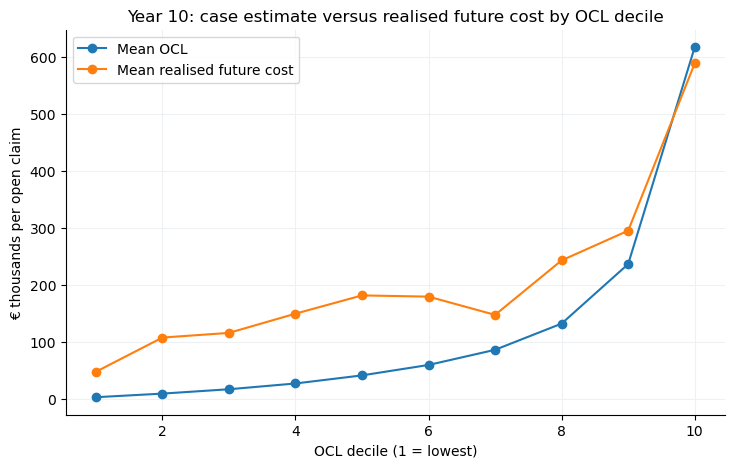

In [69]:
# CELL 68 · §23 · visual OCL calibration by decile

if RUN_CASE_ESTIMATE_STUDY and RUN_CASE_DIAGNOSTICS:
    fig, ax = plt.subplots(figsize=(8.5, 5))

    ax.plot(
        ocl_deciles['OCL_decile'],
        ocl_deciles['mean_OCL'] / 1e3,
        marker='o',
        label='Mean OCL'
    )
    ax.plot(
        ocl_deciles['OCL_decile'],
        ocl_deciles['mean_future'] / 1e3,
        marker='o',
        label='Mean realised future cost'
    )

    ax.set_xlabel('OCL decile (1 = lowest)')
    ax.set_ylabel('€ thousands per open claim')
    ax.set_title('Year 10: case estimate versus realised future cost by OCL decile')
    ax.legend()
    plt.show()
else:
    print("Skipped §23.3 plot")


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>23.4 · Rolling predictive signal</h2>
<p>The terminal valuation is again not sufficient. We repeat the claim-level correlation test at years 6–10.</p>

<p>The key comparison is not whether OCL is perfectly calibrated, but whether its ranking signal is
<strong>consistently stronger than paid-to-date</strong>. That is the first controlled evidence for incremental
case-estimate information.</p>
</div>


In [70]:
# CELL 69 · §23 · rolling OCL vs paid predictive signal

if RUN_CASE_ESTIMATE_STUDY and RUN_CASE_DIAGNOSTICS:
    signal_rows = []

    for T_star in [24.0, 28.0, 32.0, 36.0, 40.0]:
        d = open_case_table(T_star)

        ocl_p = stats.pearsonr(d['OCL'], d['future_cost']).statistic
        ocl_s = stats.spearmanr(d['OCL'], d['future_cost']).statistic

        paid_p = stats.pearsonr(d['paid_to_date'], d['future_cost']).statistic
        paid_s = stats.spearmanr(d['paid_to_date'], d['future_cost']).statistic

        signal_rows.append({
            'T_years': T_star/4,
            'n_open': len(d),
            'OCL_Pearson': ocl_p,
            'OCL_Spearman': ocl_s,
            'Paid_Pearson': paid_p,
            'Paid_Spearman': paid_s,
            'OCL_level_error': d['OCL'].sum()/d['future_cost'].sum() - 1
        })

    case_signal = pd.DataFrame(signal_rows)

    print(case_signal.round({
        'OCL_Pearson':3,
        'OCL_Spearman':3,
        'Paid_Pearson':3,
        'Paid_Spearman':3,
        'OCL_level_error':3
    }).to_string(index=False))
else:
    print("Skipped §23.4 (case study or diagnostics switch is False)")


 T_years  n_open  OCL_Pearson  OCL_Spearman  Paid_Pearson  Paid_Spearman  OCL_level_error
     6.0     865        0.525         0.555         0.030          0.179           -0.454
     7.0     847        0.552         0.598         0.035          0.197           -0.428
     8.0     824        0.682         0.609         0.026          0.188           -0.359
     9.0     799        0.668         0.593         0.016          0.156           -0.374
    10.0     846        0.604         0.599        -0.029          0.157           -0.401


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>23.5 · Does OCL add information after paid-to-date?</h2>
<p>A stronger test than comparing two separate correlations is to ask whether OCL improves prediction
<strong>conditional on paid history</strong>.</p>

<p>We deliberately keep this diagnostic simple and interpretable. Fit two out-of-time benchmark regressions on
historical open claims:</p>

<ul>
<li><strong>paid-only:</strong> future cost from claim age, report age and paid-to-date;</li>
<li><strong>case-aware:</strong> the same predictors plus OCL.</li>
</ul>

<p>The purpose is not yet to declare a final micro reserving model. It is to test whether adding OCL reduces prediction
error when everything else is held constant.</p>
</div>


In [71]:
# CELL 70 · §23 · simple rolling paid-only vs case-aware regression diagnostic

if RUN_CASE_ESTIMATE_STUDY and RUN_CASE_DIAGNOSTICS:
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import GammaRegressor

    evaluation_dates = [28.0, 32.0, 36.0, 40.0]
    regression_rows = []

    for T_star in evaluation_dates:
        # Train only on earlier valuation snapshots whose future is fully known by T_star.
        train_dates = [s for s in [16.0, 20.0, 24.0, 28.0, 32.0] if s <= T_star - 8.0]

        train_parts = []
        for s in train_dates:
            d = open_case_table(s).copy()

            # Keep only claims closed by T_star so their full post-s future is observable by that horizon.
            status_horizon, _, _, _, _, _ = make_truth_at(T_star)
            closed_by_horizon = (
                status_horizon.set_index('claim_no')['closure_time'] <= T_star
            )
            d = d[d.index.isin(closed_by_horizon[closed_by_horizon].index)].copy()
            train_parts.append(d)

        train = pd.concat(train_parts, axis=0)
        test = open_case_table(T_star).copy()

        paid_features = ['claim_age','report_age','paid_to_date']
        case_features = paid_features + ['OCL']

        paid_model = make_pipeline(
            StandardScaler(),
            GammaRegressor(alpha=0.20, max_iter=5000)
        )
        case_model = make_pipeline(
            StandardScaler(),
            GammaRegressor(alpha=0.20, max_iter=5000)
        )

        # Remaining cost is positive for genuine open claims; floor only for numerical safety.
        y_train = np.maximum(train['future_cost'].to_numpy(), 1.0)

        paid_model.fit(train[paid_features], y_train)
        case_model.fit(train[case_features], y_train)

        pred_paid = paid_model.predict(test[paid_features])
        pred_case = case_model.predict(test[case_features])

        actual = test['future_cost'].to_numpy()

        mae_paid = np.mean(np.abs(pred_paid - actual))
        mae_case = np.mean(np.abs(pred_case - actual))

        regression_rows.append({
            'T_years': T_star/4,
            'n_train_states': len(train),
            'n_test_open': len(test),
            'paid_total': pred_paid.sum(),
            'case_total': pred_case.sum(),
            'truth_total': actual.sum(),
            'paid_rel_error': pred_paid.sum()/actual.sum() - 1,
            'case_rel_error': pred_case.sum()/actual.sum() - 1,
            'paid_MAE': mae_paid,
            'case_MAE': mae_case,
            'MAE_improvement': 1 - mae_case/mae_paid
        })

    case_regression_diag = pd.DataFrame(regression_rows)

    print(
        case_regression_diag.round({
            'paid_total':0,
            'case_total':0,
            'truth_total':0,
            'paid_rel_error':3,
            'case_rel_error':3,
            'paid_MAE':0,
            'case_MAE':0,
            'MAE_improvement':3
        }).to_string(index=False)
    )
else:
    print("Skipped §23.5 (case study or diagnostics switch is False)")


 T_years  n_train_states  n_test_open  paid_total  case_total  truth_total  paid_rel_error  case_rel_error  paid_MAE  case_MAE  MAE_improvement
     7.0            1006          847 148720267.0 164348101.0  190034473.0          -0.217          -0.135  189461.0  175275.0            0.075
     8.0            1745          824 136948028.0 866271763.0  181685033.0          -0.246           3.768  172029.0 1003066.0           -4.831
     9.0            2552          799 139556475.0 192269744.0  179444132.0          -0.222           0.071  174207.0  181836.0           -0.044
    10.0            3380          846 159319451.0 161670322.0  173999071.0          -0.084          -0.071  166494.0  139503.0            0.162


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>23.6 · Decision rule for the next model</h2>
<p>Section §23 is a gate before building model D.</p>

<ul>
<li>If OCL has materially stronger and stable rank correlation than paid-to-date, and the simple case-aware regression
improves out-of-time MAE, then the next step is justified: build a proper case-aware micro reserving model using
<strong>OCL level + OCL revision history + paid history</strong>.</li>
<li>If OCL is merely biased but strongly predictive, focus on calibration rather than replacing it.</li>
<li>If OCL adds little incremental signal, then the limitation lies in the SPLICE case-estimate process itself, and a
more elaborate case-aware model would be hard to justify.</li>
</ul>

<p>The diagnostic therefore separates a scientifically interesting question — <em>does the additional information
help?</em> — from the later engineering question of how sophisticated the final model should be.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§24 · From prediction to recalibration: exploiting OCL without explosive extrapolation</h2>
<p>Section §23 established two facts that must be reconciled. Current OCL has a stable claim-level association with
future RBNS cost (Spearman about 0.56–0.61), yet its aggregate level is systematically too low. A raw-OCL Gamma
regression then failed dramatically at year 8, predicting about €866m against €182m of true RBNS.</p>

<p>That failure is retained as evidence. It does not show that OCL lacks information; it shows that an inappropriate
functional form can turn useful information into unstable extrapolation.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
The objective of §24 is calibration, not reconstruction: start from the case reserve and learn a stable correction.
</div>

<p>We first diagnose the year-8 explosion. We then replace raw monetary predictors by logarithmic transforms and use a
bounded, piecewise calibration of OCL. All choices are estimated from historical snapshots only; hidden future payments
at the evaluation date remain validation truth.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>24.1 · Reproduce and diagnose the year-8 failure</h2>
<p>The first question is mechanical: did the year-8 Gamma model encounter OCL values or combinations of covariates
outside the region represented in its training snapshots? Because a Gamma GLM uses an exponential inverse link, modest
linear-predictor extrapolation can become a very large monetary forecast.</p>
</div>


In [72]:
# CELL 71 · §24 · year-8 pathology diagnostic

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_RECALIBRATION:
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import GammaRegressor

    T_FAIL = 32.0
    train_dates = [s for s in [16.0, 20.0, 24.0] if s <= T_FAIL - 8.0]

    train_parts = []
    for s in train_dates:
        d = open_case_table(s).copy()
        status_horizon, _, _, _, _, _ = make_truth_at(T_FAIL)
        closed = status_horizon.set_index('claim_no')['closure_time'] <= T_FAIL
        d = d[d.index.isin(closed[closed].index)].copy()
        d['snapshot'] = s
        train_parts.append(d)

    train8 = pd.concat(train_parts, axis=0)
    test8 = open_case_table(T_FAIL).copy()

    raw_features = ['claim_age','report_age','paid_to_date','OCL']
    raw_model8 = make_pipeline(
        StandardScaler(),
        GammaRegressor(alpha=0.20, max_iter=5000)
    )
    raw_model8.fit(train8[raw_features],
                   np.maximum(train8['future_cost'].to_numpy(), 1.0))
    test8['raw_gamma_pred'] = raw_model8.predict(test8[raw_features])

    print("Year-8 raw Gamma pathology")
    print(f"  training states : {len(train8):,}")
    print(f"  test open claims: {len(test8):,}")
    print()
    for v in ['OCL','paid_to_date','claim_age','report_age']:
        print(f"{v}")
        print(f"  train min / p99 / max: {train8[v].min():,.2f} / {train8[v].quantile(.99):,.2f} / {train8[v].max():,.2f}")
        print(f"  test  min / p99 / max: {test8[v].min():,.2f} / {test8[v].quantile(.99):,.2f} / {test8[v].max():,.2f}")

    print()
    print("Top 15 year-8 raw-Gamma predictions")
    cols = ['raw_gamma_pred','future_cost','OCL','paid_to_date','claim_age','report_age']
    print(test8[cols].sort_values('raw_gamma_pred', ascending=False).head(15).round(0).to_string())
else:
    print("Skipped §24.1")


Year-8 raw Gamma pathology
  training states : 1,745
  test open claims: 824

OCL
  train min / p99 / max: 29.84 / 883,879.80 / 1,794,701.54
  test  min / p99 / max: 368.44 / 1,314,142.62 / 3,262,699.14
paid_to_date
  train min / p99 / max: 0.00 / 315,815.50 / 3,507,220.30
  test  min / p99 / max: 0.00 / 349,594.92 / 1,255,575.47
claim_age
  train min / p99 / max: 0.44 / 21.43 / 23.75
  test  min / p99 / max: 0.19 / 31.02 / 31.83
report_age
  train min / p99 / max: 0.00 / 19.93 / 23.30
  test  min / p99 / max: 0.01 / 30.23 / 31.43

Top 15 year-8 raw-Gamma predictions
          raw_gamma_pred  future_cost        OCL  paid_to_date  claim_age  report_age
claim_no                                                                             
1423         476258410.0    2957600.0  3262699.0      109247.0       17.0        15.0
2109         220037916.0    2187675.0  2950919.0       62735.0        9.0         8.0
364            9206123.0    1500635.0  1729687.0       47367.0       28.0        2

<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>24.2 · A safer target: calibrate the case reserve</h2>
<p>The decile diagnostic showed that a single multiplicative uplift is inappropriate: small OCL values require much
larger corrections than large OCL values. We therefore model the <strong>logarithm of future cost</strong> as a smooth,
regularised function of logarithmic monetary predictors and ages.</p>

<p>The monetary transforms are:</p>
<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
x<sub>OCL</sub> = log(1 + OCL), &nbsp;&nbsp; x<sub>paid</sub> = log(1 + paid-to-date)
</div>

<p>Log transformation compresses the extreme monetary range and prevents the exponential-link instability seen in the
raw Gamma specification. A spline in log-OCL allows the correction to change with reserve size without forcing the
14×-to-1× decile pattern into a single straight line.</p>
</div>


In [73]:
# CELL 72 · §24 · stable case-calibration model

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

def add_stable_case_features(d):
    x = d.copy()
    x['log_OCL'] = np.log1p(np.maximum(x['OCL'], 0.0))
    x['log_paid'] = np.log1p(np.maximum(x['paid_to_date'], 0.0))
    return x

def fit_stable_case_model(train):
    z = add_stable_case_features(train)

    # Flexible only in log-OCL; ages and log-paid remain linear.
    pre = ColumnTransformer([
        ('ocl_spline',
         SplineTransformer(n_knots=4, degree=2, include_bias=False),
         ['log_OCL']),
        ('other',
         StandardScaler(),
         ['log_paid','claim_age','report_age'])
    ])

    model = Pipeline([
        ('features', pre),
        ('ridge', Ridge(alpha=10.0))
    ])

    # Model log future cost; expm1 converts predictions back to euros.
    y = np.log1p(np.maximum(z['future_cost'].to_numpy(), 0.0))
    model.fit(z[['log_OCL','log_paid','claim_age','report_age']], y)
    return model

def predict_stable_case_model(model, test):
    z = add_stable_case_features(test)
    pred_log = model.predict(z[['log_OCL','log_paid','claim_age','report_age']])

    # Numerical guard only: future cost cannot be negative.
    pred = np.maximum(np.expm1(pred_log), 0.0)
    return pred


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>24.3 · Rolling validation of the stable recalibration</h2>
<p>The stable model is evaluated at years 7–10 with exactly the same historical-training rule used in §23.5. It is
compared against the paid-only Gamma benchmark from that section and against raw OCL itself.</p>

<p>The relevant criteria are both <strong>portfolio-level reserve error</strong> and <strong>claim-level MAE</strong>.
A model that achieves a good aggregate total by offsetting enormous individual errors is not satisfactory.</p>
</div>


In [74]:
# CELL 73 · §24 · rolling stable OCL recalibration

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_RECALIBRATION:
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import GammaRegressor

    eval_dates = [28.0, 32.0, 36.0, 40.0]
    stable_rows = []

    for T_star in eval_dates:
        train_dates = [s for s in [16.0,20.0,24.0,28.0,32.0] if s <= T_star - 8.0]

        parts = []
        for s in train_dates:
            d = open_case_table(s).copy()
            status_horizon, _, _, _, _, _ = make_truth_at(T_star)
            closed = status_horizon.set_index('claim_no')['closure_time'] <= T_star
            d = d[d.index.isin(closed[closed].index)].copy()
            parts.append(d)

        train = pd.concat(parts, axis=0)
        test = open_case_table(T_star).copy()

        # Paid-only benchmark retained from §23.5.
        paid_features = ['claim_age','report_age','paid_to_date']
        paid_model = make_pipeline(
            StandardScaler(),
            GammaRegressor(alpha=0.20, max_iter=5000)
        )
        paid_model.fit(
            train[paid_features],
            np.maximum(train['future_cost'].to_numpy(), 1.0)
        )
        pred_paid = paid_model.predict(test[paid_features])

        # Stable case-aware recalibration.
        stable_model = fit_stable_case_model(train)
        pred_case = predict_stable_case_model(stable_model, test)

        actual = test['future_cost'].to_numpy()
        raw_ocl = test['OCL'].to_numpy()

        def rel_total(pred):
            return pred.sum()/actual.sum() - 1

        def mae(pred):
            return np.mean(np.abs(pred-actual))

        stable_rows.append({
            'T_years': T_star/4,
            'n_train': len(train),
            'n_test': len(test),
            'truth': actual.sum(),
            'raw_OCL': raw_ocl.sum(),
            'paid_pred': pred_paid.sum(),
            'stable_case_pred': pred_case.sum(),
            'OCL_error': rel_total(raw_ocl),
            'paid_error': rel_total(pred_paid),
            'stable_case_error': rel_total(pred_case),
            'paid_MAE': mae(pred_paid),
            'stable_case_MAE': mae(pred_case),
            'MAE_improvement_vs_paid': 1 - mae(pred_case)/mae(pred_paid),
            'max_case_prediction': pred_case.max()
        })

    stable_bt = pd.DataFrame(stable_rows)

    print(stable_bt.round({
        'truth':0,'raw_OCL':0,'paid_pred':0,'stable_case_pred':0,
        'OCL_error':3,'paid_error':3,'stable_case_error':3,
        'paid_MAE':0,'stable_case_MAE':0,
        'MAE_improvement_vs_paid':3,'max_case_prediction':0
    }).to_string(index=False))

    print()
    print("Mean absolute portfolio error")
    print(f"  raw OCL     : {stable_bt['OCL_error'].abs().mean():.3f}")
    print(f"  paid-only   : {stable_bt['paid_error'].abs().mean():.3f}")
    print(f"  stable case : {stable_bt['stable_case_error'].abs().mean():.3f}")
    print()
    print("Mean claim-level MAE improvement of stable case model vs paid-only:")
    print(f"  {stable_bt['MAE_improvement_vs_paid'].mean():+.1%}")
else:
    print("Skipped §24.3")


 T_years  n_train  n_test       truth     raw_OCL   paid_pred  stable_case_pred  OCL_error  paid_error  stable_case_error  paid_MAE  stable_case_MAE  MAE_improvement_vs_paid  max_case_prediction
     7.0     1006     847 190034473.0 108702415.0 148720267.0        83156526.0     -0.428      -0.217             -0.562  189461.0         151607.0                    0.200             289521.0
     8.0     1745     824 181685033.0 116409855.0 136948028.0        84477678.0     -0.359      -0.246             -0.535  172029.0         148078.0                    0.139             299598.0
     9.0     2552     799 179444132.0 112406894.0 139556475.0        87682985.0     -0.374      -0.222             -0.511  174207.0         149426.0                    0.142             331176.0
    10.0     3380     846 173999071.0 104209954.0 159319451.0       101700635.0     -0.401      -0.084             -0.416  166494.0         128196.0                    0.230             468640.0

Mean absolute portfolio 

<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>24.4 · Calibration rather than black-box prediction</h2>
<p>If §24.3 is stable, the next refinement should preserve this interpretation. The case reserve is not discarded and
reconstructed from scratch; it is treated as a claims-handler signal whose systematic bias can be learned from historical
development.</p>

<p>A useful final case-aware model may therefore combine:</p>
<ul>
<li>current OCL level;</li>
<li>claim age and time since report;</li>
<li>paid-to-date;</li>
<li>number, direction and size of previous case-estimate revisions;</li>
<li>time since the most recent major/minor revision.</li>
</ul>

<p>Those trajectory variables are especially relevant because the §23 deciles suggest that low current OCL may identify
claims whose case estimate has not yet caught up with their later development.</p>
</div>


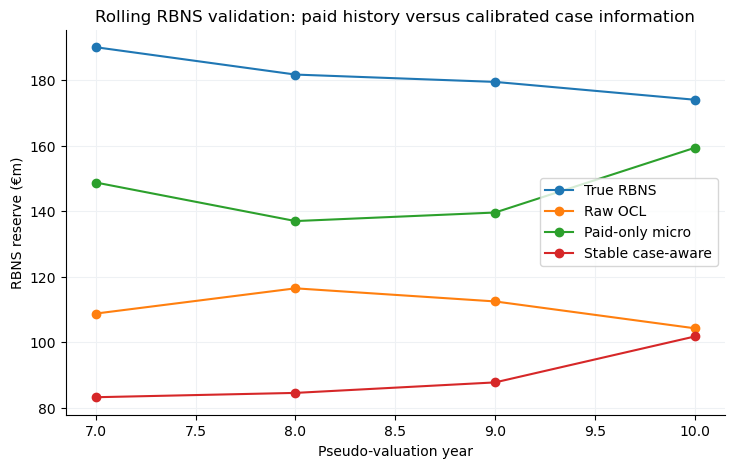

In [75]:
# CELL 74 · §24 · visual rolling comparison

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_RECALIBRATION:
    fig, ax = plt.subplots(figsize=(8.5,5))

    ax.plot(stable_bt['T_years'], stable_bt['truth']/1e6, marker='o', label='True RBNS')
    ax.plot(stable_bt['T_years'], stable_bt['raw_OCL']/1e6, marker='o', label='Raw OCL')
    ax.plot(stable_bt['T_years'], stable_bt['paid_pred']/1e6, marker='o', label='Paid-only micro')
    ax.plot(stable_bt['T_years'], stable_bt['stable_case_pred']/1e6, marker='o', label='Stable case-aware')

    ax.set_xlabel('Pseudo-valuation year')
    ax.set_ylabel('RBNS reserve (€m)')
    ax.set_title('Rolling RBNS validation: paid history versus calibrated case information')
    ax.legend()
    plt.show()
else:
    print("Skipped §24.4")


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>24.5 · Decision point</h2>
<p>We proceed to case-estimate trajectory features only if the stable model passes two tests:</p>
<ul>
<li>no recurrence of the explosive year-8 extrapolation;</li>
<li>a reasonably consistent out-of-time improvement over the paid-only benchmark, either in aggregate reserve error,
claim-level MAE, or preferably both.</li>
</ul>

<p>If it does not, the scientifically defensible conclusion is not to keep adding complexity until it wins. The result
would instead be that SPLICE OCL contains strong standalone ranking information, but extracting incremental predictive
value conditional on paid development is unstable in this experimental design.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§25 · From good individual predictions to an unbiased mean reserve</h2>
<p>Section §24 solved the instability problem. The log/spline case-aware model improved claim-level MAE by about
18% versus the paid-only benchmark, but its portfolio reserve remained systematically too low.</p>

<p>This is a standard consequence of modelling a transformed response. If</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
log(1 + Y) = m(X) + ε
</div>

<p>then simply using <code>exp(m(X)) − 1</code> does not generally estimate the arithmetic conditional mean
E[Y | X]. With a right-skewed residual distribution, the naive back-transform is biased downward.</p>

<p>§25 therefore applies <strong>Duan's smearing estimator</strong>: estimate the mean exponential residual on the
historical training data and use it when retranslating predictions into euros.</p>

<p>We test two variants:</p>
<ul>
<li><strong>Global smearing</strong> — one retransformation factor for all open claims;</li>
<li><strong>OCL-band smearing</strong> — separate historical factors by OCL quantile band, allowing residual
dispersion/miscalibration to differ by case-reserve size.</li>
</ul>

<p>Both factors are estimated strictly from historical training snapshots. The hidden future at the evaluation date is
never used for calibration.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>25.1 · Why smearing is not an arbitrary uplift</h2>
<p>A fixed multiplier chosen because it makes year 10 look right would be data leakage. Smearing is different: the
factor is estimated from <strong>training residuals only</strong>.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
smearing factor = mean[ exp(residual on log scale) ]
</div>

<p>For a test claim with predicted log-cost m̂, the mean-corrected prediction becomes approximately:</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
predicted mean future cost = exp(m̂) × smearing factor − 1
</div>

<p>The conditional/banded version estimates the factor separately for OCL groups. This is motivated by §23's strong
size-dependent calibration pattern, not by the hidden evaluation results.</p>
</div>


In [76]:
# CELL 75 · §25 · helpers for global and OCL-band smearing

def fit_stable_case_model_with_smearing(train, n_bands=5):
    z = add_stable_case_features(train)

    pre = ColumnTransformer([
        ('ocl_spline',
         SplineTransformer(n_knots=4, degree=2, include_bias=False),
         ['log_OCL']),
        ('other',
         StandardScaler(),
         ['log_paid','claim_age','report_age'])
    ])

    model = Pipeline([
        ('features', pre),
        ('ridge', Ridge(alpha=10.0))
    ])

    y_log = np.log1p(np.maximum(z['future_cost'].to_numpy(), 0.0))
    X = z[['log_OCL','log_paid','claim_age','report_age']]
    model.fit(X, y_log)

    fitted_log = model.predict(X)
    resid = y_log - fitted_log

    # Duan global smearing factor.
    global_smear = float(np.mean(np.exp(resid)))

    # OCL-band conditional smearing.
    band_source = z['log_OCL'].rank(method='first')
    bands = pd.qcut(band_source, q=n_bands, labels=False, duplicates='drop')

    band_table = pd.DataFrame({
        'log_OCL': z['log_OCL'].to_numpy(),
        'band': np.asarray(bands, dtype=int),
        'exp_resid': np.exp(resid)
    })

    band_smear = band_table.groupby('band')['exp_resid'].mean().to_dict()

    # Store band boundaries in original log-OCL scale.
    quantiles = np.quantile(
        z['log_OCL'].to_numpy(),
        np.linspace(0, 1, len(band_smear) + 1)
    )

    return model, global_smear, band_smear, quantiles


def predict_case_with_smearing(model, test, smear, band_smear=None, quantiles=None):
    z = add_stable_case_features(test)
    X = z[['log_OCL','log_paid','claim_age','report_age']]
    pred_log = model.predict(X)

    if band_smear is None:
        factor = np.full(len(z), float(smear))
    else:
        # Assign test claims to historical OCL bands using training boundaries.
        # Values outside support go to the nearest edge band.
        bins = np.asarray(quantiles, dtype=float).copy()
        bins[0] = -np.inf
        bins[-1] = np.inf
        band_idx = np.digitize(z['log_OCL'].to_numpy(), bins[1:-1], right=True)
        factor = np.array([band_smear.get(int(b), smear) for b in band_idx], dtype=float)

    pred = np.exp(pred_log) * factor - 1.0
    return np.maximum(pred, 0.0)


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>25.2 · Inspect the year-8 retransformation factors</h2>
<p>Before the rolling test, inspect the historical factors at the valuation date where the raw Gamma model previously
exploded. The point is not to obtain a “nice” factor, but to ensure the correction is numerically plausible and not
being driven by one extreme residual.</p>
</div>


In [77]:
# CELL 76 · §25 · year-8 smearing diagnostics

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING:
    T_CHECK = 32.0
    train_dates = [s for s in [16.0,20.0,24.0] if s <= T_CHECK - 8.0]

    parts = []
    for s in train_dates:
        d = open_case_table(s).copy()
        status_horizon, _, _, _, _, _ = make_truth_at(T_CHECK)
        closed = status_horizon.set_index('claim_no')['closure_time'] <= T_CHECK
        d = d[d.index.isin(closed[closed].index)].copy()
        parts.append(d)

    train_check = pd.concat(parts, axis=0)

    model_check, global_smear_check, band_smear_check, band_edges_check = (
        fit_stable_case_model_with_smearing(train_check, n_bands=5)
    )

    print(f"training states              : {len(train_check):,}")
    print(f"global smearing factor       : {global_smear_check:.3f}")
    print("OCL-band smearing factors")
    for b, v in sorted(band_smear_check.items()):
        print(f"  band {b+1}: {v:.3f}")
else:
    print("Skipped §25.2")


training states              : 1,745
global smearing factor       : 2.038
OCL-band smearing factors
  band 1: 3.580
  band 2: 2.601
  band 3: 1.251
  band 4: 1.146
  band 5: 1.611


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>25.3 · Rolling comparison: naive back-transform vs smearing</h2>
<p>The decisive test repeats years 7–10. We compare five quantities on the same open-claim populations:</p>
<ul>
<li>raw OCL;</li>
<li>paid-only micro benchmark;</li>
<li>stable case-aware model with naive back-transform;</li>
<li>stable case-aware + global smearing;</li>
<li>stable case-aware + OCL-band smearing.</li>
</ul>

<p>We judge both aggregate RBNS error and claim-level MAE. Smearing succeeds only if it improves portfolio mean
calibration without destroying the individual-prediction advantage discovered in §24.</p>
</div>


In [78]:
# CELL 77 · §25 · rolling smearing validation

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING:
    eval_dates = [28.0, 32.0, 36.0, 40.0]
    smear_rows = []

    for T_star in eval_dates:
        train_dates = [s for s in [16.0,20.0,24.0,28.0,32.0] if s <= T_star - 8.0]

        parts = []
        for s in train_dates:
            d = open_case_table(s).copy()
            status_horizon, _, _, _, _, _ = make_truth_at(T_star)
            closed = status_horizon.set_index('claim_no')['closure_time'] <= T_star
            d = d[d.index.isin(closed[closed].index)].copy()
            parts.append(d)

        train = pd.concat(parts, axis=0)
        test = open_case_table(T_star).copy()
        actual = test['future_cost'].to_numpy()

        # Paid-only benchmark.
        paid_features = ['claim_age','report_age','paid_to_date']
        paid_model = make_pipeline(
            StandardScaler(),
            GammaRegressor(alpha=0.20, max_iter=5000)
        )
        paid_model.fit(
            train[paid_features],
            np.maximum(train['future_cost'].to_numpy(), 1.0)
        )
        pred_paid = paid_model.predict(test[paid_features])

        # Stable case model.
        model, global_smear, band_smear, band_edges = (
            fit_stable_case_model_with_smearing(train, n_bands=5)
        )

        # Naive retransformation from §24.
        pred_naive = predict_stable_case_model(model, test)

        # Mean corrections.
        pred_global = predict_case_with_smearing(
            model, test, global_smear
        )
        pred_banded = predict_case_with_smearing(
            model, test, global_smear,
            band_smear=band_smear,
            quantiles=band_edges
        )

        raw_ocl = test['OCL'].to_numpy()

        def rel_err(pred):
            return pred.sum()/actual.sum() - 1.0

        def mae(pred):
            return np.mean(np.abs(pred - actual))

        smear_rows.append({
            'T_years': T_star/4,
            'n_train': len(train),
            'n_test': len(test),
            'truth': actual.sum(),
            'raw_OCL': raw_ocl.sum(),
            'paid_pred': pred_paid.sum(),
            'naive_case': pred_naive.sum(),
            'global_smear_case': pred_global.sum(),
            'band_smear_case': pred_banded.sum(),
            'OCL_error': rel_err(raw_ocl),
            'paid_error': rel_err(pred_paid),
            'naive_case_error': rel_err(pred_naive),
            'global_smear_error': rel_err(pred_global),
            'band_smear_error': rel_err(pred_banded),
            'paid_MAE': mae(pred_paid),
            'naive_case_MAE': mae(pred_naive),
            'global_smear_MAE': mae(pred_global),
            'band_smear_MAE': mae(pred_banded),
            'global_smear_factor': global_smear,
            'max_global_prediction': pred_global.max(),
            'max_banded_prediction': pred_banded.max()
        })

    smear_bt = pd.DataFrame(smear_rows)

    print(smear_bt.round({
        'truth':0,'raw_OCL':0,'paid_pred':0,'naive_case':0,
        'global_smear_case':0,'band_smear_case':0,
        'OCL_error':3,'paid_error':3,'naive_case_error':3,
        'global_smear_error':3,'band_smear_error':3,
        'paid_MAE':0,'naive_case_MAE':0,'global_smear_MAE':0,'band_smear_MAE':0,
        'global_smear_factor':3,'max_global_prediction':0,'max_banded_prediction':0
    }).to_string(index=False))
else:
    print("Skipped §25.3")


 T_years  n_train  n_test       truth     raw_OCL   paid_pred  naive_case  global_smear_case  band_smear_case  OCL_error  paid_error  naive_case_error  global_smear_error  band_smear_error  paid_MAE  naive_case_MAE  global_smear_MAE  band_smear_MAE  global_smear_factor  max_global_prediction  max_banded_prediction
     7.0     1006     847 190034473.0 108702415.0 148720267.0  83156526.0        166067748.0      132527344.0     -0.428      -0.217            -0.562              -0.126            -0.303  189461.0        151607.0          167760.0        153814.0                1.997               578187.0               472972.0
     8.0     1745     824 181685033.0 116409855.0 136948028.0  84477678.0        172147858.0      132292717.0     -0.359      -0.246            -0.535              -0.052            -0.272  172029.0        148078.0          168537.0        146933.0                2.038               610516.0               482638.0
     9.0     2552     799 179444132.0 112406894.0 13

<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>25.4 · Summary scorecard</h2>
<p>The summary separates <strong>portfolio calibration</strong> from <strong>claim-level accuracy</strong>.</p>
<p>The preferred method should have low mean absolute portfolio error and should retain at least some of the
claim-level MAE advantage of the stable case-aware specification.</p>
</div>


In [79]:
# CELL 78 · §25 · smearing scorecard

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING:
    methods = [
        ('Raw OCL', 'OCL_error', None),
        ('Paid-only micro', 'paid_error', 'paid_MAE'),
        ('Naive stable case', 'naive_case_error', 'naive_case_MAE'),
        ('Global smearing', 'global_smear_error', 'global_smear_MAE'),
        ('OCL-band smearing', 'band_smear_error', 'band_smear_MAE')
    ]

    rows = []
    for label, err_col, mae_col in methods:
        row = {
            'method': label,
            'mean_relative_bias': smear_bt[err_col].mean(),
            'MAPE_portfolio': smear_bt[err_col].abs().mean()
        }
        if mae_col is not None:
            row['mean_claim_MAE'] = smear_bt[mae_col].mean()
        else:
            row['mean_claim_MAE'] = np.nan
        rows.append(row)

    smear_score = pd.DataFrame(rows)
    print(smear_score.round({
        'mean_relative_bias':3,
        'MAPE_portfolio':3,
        'mean_claim_MAE':0
    }).to_string(index=False))
else:
    print("Skipped §25.4")


           method  mean_relative_bias  MAPE_portfolio  mean_claim_MAE
          Raw OCL              -0.390           0.390             NaN
  Paid-only micro              -0.193           0.193        175548.0
Naive stable case              -0.506           0.506        144327.0
  Global smearing              -0.001           0.092        168756.0
OCL-band smearing              -0.230           0.230        145723.0


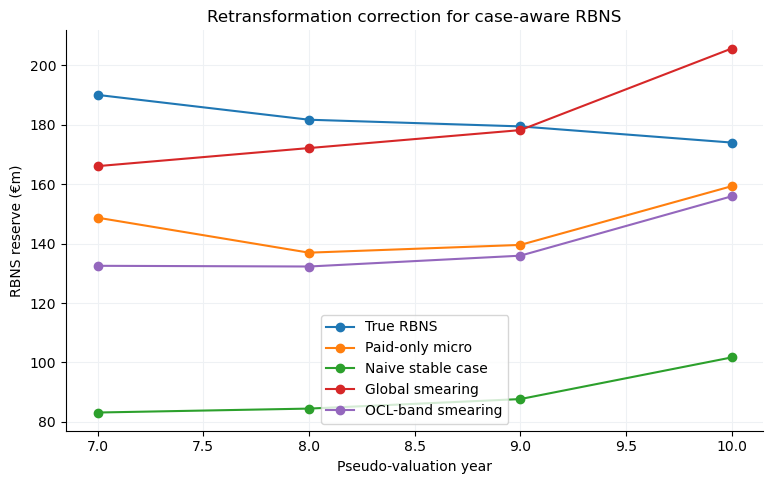

In [80]:
# CELL 79 · §25 · rolling visual comparison

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING:
    fig, ax = plt.subplots(figsize=(9,5.2))

    ax.plot(smear_bt['T_years'], smear_bt['truth']/1e6, marker='o', label='True RBNS')
    ax.plot(smear_bt['T_years'], smear_bt['paid_pred']/1e6, marker='o', label='Paid-only micro')
    ax.plot(smear_bt['T_years'], smear_bt['naive_case']/1e6, marker='o', label='Naive stable case')
    ax.plot(smear_bt['T_years'], smear_bt['global_smear_case']/1e6, marker='o', label='Global smearing')
    ax.plot(smear_bt['T_years'], smear_bt['band_smear_case']/1e6, marker='o', label='OCL-band smearing')

    ax.set_xlabel('Pseudo-valuation year')
    ax.set_ylabel('RBNS reserve (€m)')
    ax.set_title('Retransformation correction for case-aware RBNS')
    ax.legend()
    plt.show()
else:
    print("Skipped §25.5")


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>25.5 · Decision rule</h2>
<p>If global or banded smearing materially reduces portfolio MAPE while preserving the case-aware claim-level MAE
advantage, we have a coherent case-aware reserving benchmark. Only then should we consider richer OCL revision-history
features.</p>

<p>If smearing fixes the mean but destroys claim-level accuracy, the case-aware model is learning the wrong conditional
shape. If it fails to fix the mean at all, the log/spline response model is not an adequate basis for a best-estimate
reserve despite its lower individual MAE.</p>

<p>Again, no factor in this section is estimated from the hidden evaluation reserve itself.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§26 · Common-window horse race: one truth, one horizon, one scorecard</h2>
<p>The preceding sections produced several reserving estimators, but some summary statistics were calculated over
different pseudo-valuation windows. A direct ranking requires an identical evaluation sample.</p>

<p>§26 therefore restricts every method to <strong>years 7–10</strong>, the four dates for which the case-aware
smearing model is genuinely out-of-time. No method receives an additional valuation date.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
Comparison window: T = 28, 32, 36, 40 quarters (years 7, 8, 9, 10)
</div>

<p>The common target is the hidden <strong>total reserve = RBNS + IBNR</strong> when the estimator is a total-reserve
method. For RBNS-only estimators, the already validated causal IBNR estimate is added so that all methods are compared
on the same liability. This avoids penalising a case-reserve model merely because it is designed for reported open
claims rather than unreported claims.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>26.1 · Assemble the common-window estimates</h2>
<p>The comparison includes:</p>
<ul>
<li><strong>Paid Chain Ladder</strong> — aggregate paid-triangle benchmark;</li>
<li><strong>Incurred Chain Ladder</strong> — aggregate incurred-triangle benchmark;</li>
<li><strong>Raw OCL + causal IBNR</strong> — direct use of case reserves;</li>
<li><strong>Paid-only micro + causal IBNR</strong> — claim-level paid-history benchmark;</li>
<li><strong>Global-smearing case-aware + causal IBNR</strong> — the §25 mean-calibrated case model.</li>
</ul>

<p>The causal IBNR component is common to the three RBNS-only methods. Consequently, differences among those methods
are attributable to their treatment of reported open claims.</p>
</div>


In [81]:
# CELL 80 · §26 · common-window horse race

if RUN_CASE_ESTIMATE_STUDY and RUN_COMMON_WINDOW_HORSERACE:

    COMMON_YEARS = [7.0, 8.0, 9.0, 10.0]

    # bt is the original rolling backtest:
    # truth = hidden total reserve, truth_RBNS, truth_IBNR,
    # CL_mean = paid Chain Ladder, micro_IBNR = causal IBNR estimate.
    base_common = (
        bt[bt['T_years'].isin(COMMON_YEARS)]
        [['T_years','truth','truth_RBNS','truth_IBNR','CL_mean','micro_IBNR']]
        .copy()
        .rename(columns={'truth':'truth_total', 'CL_mean':'paid_CL'})
    )

    # case_bt supplies the rolling incurred Chain-Ladder estimate.
    incurred_common = (
        case_bt[case_bt['T_years'].isin(COMMON_YEARS)]
        [['T_years','incurred_CL']]
        .copy()
    )

    # smear_bt supplies the RBNS-only claim-level estimators.
    case_common = (
        smear_bt[smear_bt['T_years'].isin(COMMON_YEARS)]
        [['T_years','raw_OCL','paid_pred','global_smear_case']]
        .copy()
    )

    common = (
        base_common
        .merge(incurred_common, on='T_years', how='inner')
        .merge(case_common, on='T_years', how='inner')
        .sort_values('T_years')
        .reset_index(drop=True)
    )

    # Put RBNS-only estimators on the same total-reserve target by adding
    # exactly the same causal IBNR estimate to each.
    common['raw_OCL_total'] = common['raw_OCL'] + common['micro_IBNR']
    common['paid_micro_total'] = common['paid_pred'] + common['micro_IBNR']
    common['case_smear_total'] = common['global_smear_case'] + common['micro_IBNR']

    # Truth reconciliation.
    common['truth_check'] = common['truth_RBNS'] + common['truth_IBNR']
    assert np.allclose(common['truth_total'], common['truth_check'])

    print("Common-window total reserve comparison")
    print("Years 7–10 only\n")
    show = common[[
        'T_years','truth_total','paid_CL','incurred_CL',
        'raw_OCL_total','paid_micro_total','case_smear_total'
    ]]
    print(show.round(0).to_string(index=False))
else:
    print("Skipped §26.1")


Common-window total reserve comparison
Years 7–10 only

 T_years  truth_total     paid_CL  incurred_CL  raw_OCL_total  paid_micro_total  case_smear_total
     7.0  209873594.0 172948533.0   97634362.0    126798391.0       166816243.0       184163724.0
     8.0  202377244.0 224763552.0  115864513.0    134602328.0       155140501.0       190340331.0
     9.0  203049774.0 199884028.0  101002864.0    131540181.0       158689762.0       197324798.0
    10.0  193959141.0 237781966.0  103911308.0    124362530.0       179472027.0       225797385.0


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>26.2 · Year-by-year relative errors</h2>
<p>All relative errors below use exactly the same denominator: the hidden total reserve at the pseudo-valuation date.
This is the most transparent comparison because it shows whether a good average score is hiding a single severe miss.</p>
</div>


In [82]:
# CELL 81 · §26 · year-by-year errors

if RUN_CASE_ESTIMATE_STUDY and RUN_COMMON_WINDOW_HORSERACE:
    method_cols = {
        'Paid Chain Ladder': 'paid_CL',
        'Incurred Chain Ladder': 'incurred_CL',
        'Raw OCL + IBNR': 'raw_OCL_total',
        'Paid-only micro + IBNR': 'paid_micro_total',
        'Case-aware global smear + IBNR': 'case_smear_total'
    }

    error_table = common[['T_years','truth_total']].copy()
    for label, col in method_cols.items():
        error_table[label] = common[col] / common['truth_total'] - 1.0

    print("Relative error by pseudo-valuation year")
    print(error_table.round(3).to_string(index=False))
else:
    print("Skipped §26.2")


Relative error by pseudo-valuation year
 T_years  truth_total  Paid Chain Ladder  Incurred Chain Ladder  Raw OCL + IBNR  Paid-only micro + IBNR  Case-aware global smear + IBNR
     7.0 2.098736e+08             -0.176                 -0.535          -0.396                  -0.205                          -0.123
     8.0 2.023772e+08              0.111                 -0.427          -0.335                  -0.233                          -0.059
     9.0 2.030498e+08             -0.016                 -0.503          -0.352                  -0.218                          -0.028
    10.0 1.939591e+08              0.226                 -0.464          -0.359                  -0.075                           0.164


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>26.3 · Common-window scorecard</h2>
<p>For each estimator we report mean relative bias, MAPE, RMSE in euros and maximum absolute percentage error.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
MAPE measures typical proportional miss; RMSE penalises large euro errors; mean bias shows systematic direction.
</div>

<p>Because there are only four common evaluation dates, these statistics are descriptive evidence rather than a claim
of universal model superiority.</p>
</div>


In [83]:
# CELL 82 · §26 · apples-to-apples scorecard

if RUN_CASE_ESTIMATE_STUDY and RUN_COMMON_WINDOW_HORSERACE:
    score_rows = []

    for label, col in method_cols.items():
        err_eur = common[col].to_numpy() - common['truth_total'].to_numpy()
        rel = err_eur / common['truth_total'].to_numpy()

        score_rows.append({
            'method': label,
            'mean_relative_bias': rel.mean(),
            'MAPE': np.mean(np.abs(rel)),
            'RMSE_EUR': np.sqrt(np.mean(err_eur**2)),
            'max_abs_pct_error': np.max(np.abs(rel))
        })

    common_score = (
        pd.DataFrame(score_rows)
        .sort_values(['MAPE','RMSE_EUR'])
        .reset_index(drop=True)
    )

    print(common_score.round({
        'mean_relative_bias':3,
        'MAPE':3,
        'RMSE_EUR':0,
        'max_abs_pct_error':3
    }).to_string(index=False))
else:
    print("Skipped §26.3")


                        method  mean_relative_bias  MAPE   RMSE_EUR  max_abs_pct_error
Case-aware global smear + IBNR              -0.012 0.094 21519374.0              0.164
             Paid Chain Ladder               0.036 0.132 30802065.0              0.226
        Paid-only micro + IBNR              -0.183 0.183 39569346.0              0.233
                Raw OCL + IBNR              -0.360 0.360 73232914.0              0.396
         Incurred Chain Ladder              -0.482 0.482 98239862.0              0.535


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>26.4 · Isolate the RBNS question</h2>
<p>The total-reserve comparison is operationally fair, but Denuit's observation concerns open reported claims.
Accordingly, we also compare the RBNS estimators alone against hidden RBNS truth. Paid and incurred Chain Ladder are
not included in this second table because their outputs are total IBNR-style triangle reserves and cannot be cleanly
decomposed into the same claim-status target without changing the experiment.</p>

<p>This second scorecard asks the narrower question: <strong>given a reported open claim, does retaining case-reserve
information improve prediction of its remaining payments?</strong></p>
</div>


In [84]:
# CELL 83 · §26 · RBNS-only micro comparison

if RUN_CASE_ESTIMATE_STUDY and RUN_COMMON_WINDOW_HORSERACE:

    rbns_methods = {
        'Raw OCL': 'raw_OCL',
        'Paid-only micro': 'paid_pred',
        'Case-aware global smear': 'global_smear_case'
    }

    truth = common['truth_RBNS'].to_numpy()
    rbns_rows = []

    for label, col in rbns_methods.items():
        pred = common[col].to_numpy()
        rel = pred / truth - 1.0
        rbns_rows.append({
            'method': label,
            'mean_relative_bias': rel.mean(),
            'MAPE_RBNS': np.mean(np.abs(rel)),
            'RMSE_RBNS_EUR': np.sqrt(np.mean((pred - truth)**2)),
            'max_abs_pct_error': np.max(np.abs(rel))
        })

    rbns_score = (
        pd.DataFrame(rbns_rows)
        .sort_values(['MAPE_RBNS','RMSE_RBNS_EUR'])
        .reset_index(drop=True)
    )

    print("RBNS-only comparison — years 7–10\n")
    print(rbns_score.round({
        'mean_relative_bias':3,
        'MAPE_RBNS':3,
        'RMSE_RBNS_EUR':0,
        'max_abs_pct_error':3
    }).to_string(index=False))
else:
    print("Skipped §26.4")


RBNS-only comparison — years 7–10

                 method  mean_relative_bias  MAPE_RBNS  RMSE_RBNS_EUR  max_abs_pct_error
Case-aware global smear              -0.001      0.092     20422924.0              0.182
        Paid-only micro              -0.193      0.193     37130781.0              0.246
                Raw OCL              -0.390      0.390     71134142.0              0.428


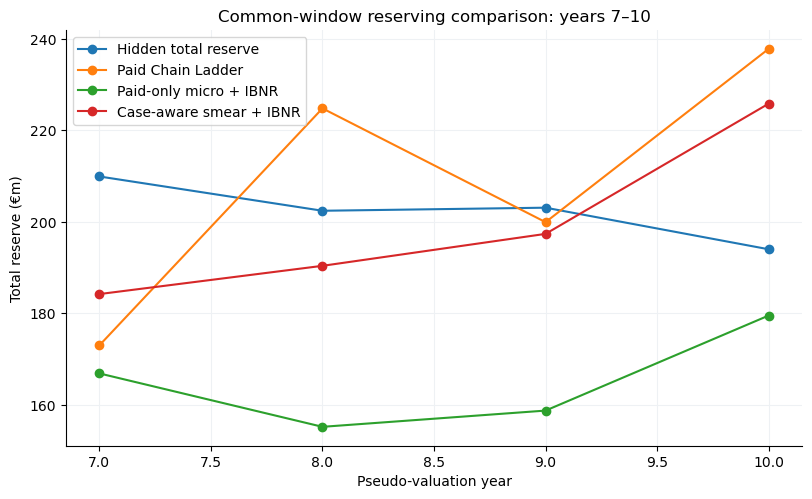

In [85]:
# CELL 84 · §26 · principal common-window figure

if RUN_CASE_ESTIMATE_STUDY and RUN_COMMON_WINDOW_HORSERACE:
    fig, ax = plt.subplots(figsize=(9.5,5.4))

    ax.plot(common['T_years'], common['truth_total']/1e6,
            marker='o', label='Hidden total reserve')
    ax.plot(common['T_years'], common['paid_CL']/1e6,
            marker='o', label='Paid Chain Ladder')
    ax.plot(common['T_years'], common['paid_micro_total']/1e6,
            marker='o', label='Paid-only micro + IBNR')
    ax.plot(common['T_years'], common['case_smear_total']/1e6,
            marker='o', label='Case-aware smear + IBNR')

    ax.set_xlabel('Pseudo-valuation year')
    ax.set_ylabel('Total reserve (€m)')
    ax.set_title('Common-window reserving comparison: years 7–10')
    ax.legend()
    plt.show()
else:
    print("Skipped §26.5")


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>26.5 · Interpretation discipline</h2>
<p>The common-window table is the point at which a headline can be stated, but only at the strength supported by the
experiment. If the case-aware estimator wins, the defensible statement is that <strong>in this controlled synthetic
portfolio</strong>, retaining and mean-calibrating claim-level case-reserve information improved out-of-time reserve
accuracy over the specified benchmarks.</p>

<p>It would not establish that micro reserving generally dominates Chain Ladder. The portfolio is synthetic, the
evaluation window contains four dates, and the case-estimate process is generated by SPLICE. Those limitations belong
in the eventual technical note alongside the result.</p>

<p>If the case-aware method does not win on the common window, the study remains informative: OCL demonstrably contains
stable claim-level signal, while aggregation and retransformation determine whether that signal translates into a
better portfolio reserve.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§27 · Audit, interpretation and stopping rule</h2>
<p>The common-window result is the endpoint of the present experiment, not an invitation to keep tuning until one
method wins by more. The main comparison uses four out-of-time pseudo-valuations on one synthetic portfolio.</p>

<p><strong>Central result.</strong> Over years 7–10, the case-aware mean-calibrated model has 9.4% total-reserve
MAPE versus 13.2% for paid Chain Ladder. On RBNS alone, adding the recalibrated case estimate reduces MAPE from
19.3% for the paid-only micro model to 9.2%.</p>

<p><strong>Interpretation.</strong> The case estimate (OCL) is informative but badly calibrated in level. Raw OCL
therefore under-reserves, and incurred Chain Ladder inherits the quality of that provision process. Retaining OCL at
claim level and recalibrating it can exploit information that simple aggregation does not.</p>

<p><strong>Negative result retained.</strong> The elaborate paid-process branch (§20–§21) did not produce a competitive
reserve and is disabled by default. Its failures remain documented because they reveal censoring, extrapolation and
long-tail modelling problems rather than being silently discarded.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>27.1 · Leakage and as-of-time audit</h2>
<p>The winning specification must obey a strict <strong>as-of-T</strong> discipline. At each pseudo-valuation date,
features for an open claim are constructed from information available by that date. OCL is the case estimate current
at the valuation cut; future OCL revisions and future payments are not features.</p>

<p>The global Duan smearing factor is estimated from historical training residuals only. It is not chosen to match the
hidden reserve at the evaluation date. The rolling code below prints the historical factor used at each date and checks
that the common-window tables contain the expected four valuation dates.</p>
</div>


In [86]:
# CELL 85 · §27 · audit the final comparison and historical smearing factors

if RUN_CASE_ESTIMATE_STUDY and RUN_COMMON_WINDOW_HORSERACE:
    expected_years = np.array([7.0, 8.0, 9.0, 10.0])
    assert np.array_equal(common['T_years'].to_numpy(), expected_years)
    assert np.array_equal(smear_bt['T_years'].to_numpy(), expected_years)

    audit = smear_bt[[
        'T_years','n_train','n_test','global_smear_factor',
        'global_smear_error','max_global_prediction'
    ]].copy()

    print("Out-of-time smearing audit")
    print(audit.round({
        'global_smear_factor':3,
        'global_smear_error':3,
        'max_global_prediction':0
    }).to_string(index=False))

    print("\nThe smearing factor is estimated inside each rolling training sample;")
    print("the hidden evaluation reserve is used only for scoring.")
else:
    print("Skipped §27.1")


Out-of-time smearing audit
 T_years  n_train  n_test  global_smear_factor  global_smear_error  max_global_prediction
     7.0     1006     847                1.997              -0.126               578187.0
     8.0     1745     824                2.038              -0.052               610516.0
     9.0     2552     799                2.032              -0.007               673021.0
    10.0     3380     846                2.022               0.182               947615.0

The smearing factor is estimated inside each rolling training sample;
the hidden evaluation reserve is used only for scoring.


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>27.2 · Limits of the result</h2>
<ul>
<li><strong>One simulated book.</strong> The four valuation dates are correlated observations from the same portfolio,
not four independent portfolios.</li>
<li><strong>Provision regime dependence.</strong> Incurred Chain Ladder performs badly here because the SPLICE case
estimates are materially under-reserved. The robust conclusion is not that incurred Chain Ladder is generally poor,
but that it inherits provision quality.</li>
<li><strong>Paid-process branch.</strong> Long-horizon recursion uses a finite future-quarter cap and clips features to
training support. Those safeguards can create downward bias when claims remain open beyond the fitted support. Results
from that exploratory branch should therefore not be presented as a clean information comparison with Chain Ladder.</li>
<li><strong>Next validation.</strong> Before generalising the ranking, repeat the complete experiment on independently
simulated portfolios and, ideally, under a second claim/case-reserve generator.</li>
</ul>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>27.3 · Result to carry into the technical note</h2>
<p>In this controlled experiment, case reserves were a <strong>strong but miscalibrated signal</strong>. Their raw
aggregate level substantially understated future RBNS, and aggregating them into an incurred triangle did not repair
that defect. A claim-level model that retained the case estimate and corrected its mean calibration reduced RBNS MAPE
from 19.3% (paid-only micro) to 9.2%, and total-reserve MAPE from 13.2% for paid Chain Ladder to 9.4%.</p>

<p>This is evidence about the mechanism behind bottom-up/top-down divergence, not a general claim that micro reserving
dominates Chain Ladder.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§28 · Year-10 error anatomy</h2>
<p>The final common-window result contains one conspicuous miss: at year 10 the case-aware global-smearing RBNS
estimate overshoots hidden RBNS by about 18.2%, despite a smearing factor close to the factors estimated at years 7–9.</p>

<p>This section does <strong>not</strong> retune the model. It diagnoses the fixed year-10 prediction claim by claim.
The question is whether the excess reserve is concentrated in a handful of claims, associated with particular OCL
bands, or broadly distributed. This distinguishes a tail/composition event from a general retransformation-level
problem.</p>
</div>


In [87]:
# CELL 86 · §28 · exactly reproduce the fixed year-10 prediction

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING and RUN_YEAR10_DIAGNOSTIC:

    T10 = 40.0

    # IMPORTANT:
    # This reproduces the exact historical-training rule used in CELL 77 (§25.3).
    # Do not simplify or alter it here; the diagnostic is valid only if it first
    # reproduces the published year-10 forecast exactly.

    train_dates_10 = [
        s for s in [16.0, 20.0, 24.0, 28.0, 32.0]
        if s <= T10 - 8.0
    ]

    parts10 = []

    for s in train_dates_10:
        d = open_case_table(s).copy()

        # Exact §25.3 rule:
        # retain only states whose claim is closed by the evaluation horizon T10,
        # so the full future from historical snapshot s is observable by T10.
        status_horizon, _, _, _, _, _ = make_truth_at(T10)

        closed = (
            status_horizon
            .set_index('claim_no')['closure_time']
            <= T10
        )

        d = d[
            d.index.isin(
                closed[closed].index
            )
        ].copy()

        parts10.append(d)

    train10 = pd.concat(parts10, axis=0)

    # Year-10 evaluation population.
    test10 = open_case_table(T10).copy()

    # Fit exactly the same case-aware smearing model as §25.3.
    model10, smear10, band_smear10, band_edges10 = (
        fit_stable_case_model_with_smearing(
            train10,
            n_bands=5
        )
    )

    test10['pred_naive'] = predict_stable_case_model(
        model10,
        test10
    )

    test10['pred_smear'] = predict_case_with_smearing(
        model10,
        test10,
        smear10
    )

    test10['error_smear'] = (
        test10['pred_smear']
        - test10['future_cost']
    )

    test10['abs_error_smear'] = (
        test10['error_smear'].abs()
    )

    test10['OCL_decile'] = pd.qcut(
        test10['OCL'].rank(method='first'),
        10,
        labels=False
    ) + 1

    total_truth10 = test10['future_cost'].sum()
    total_pred10 = test10['pred_smear'].sum()
    total_error10 = total_pred10 - total_truth10

    # ------------------------------------------------------------
    # Reproduction assertions
    # These must pass before §28.2 / §28.3 are interpreted.
    # ------------------------------------------------------------
    expected_train_states = 3380
    expected_smear = 2.022
    expected_pred = 205_644_808.0
    expected_truth = 173_999_071.0

    assert len(train10) == expected_train_states, (
        f"Training-state mismatch: {len(train10):,} "
        f"vs expected {expected_train_states:,}"
    )

    assert np.isclose(
        smear10,
        expected_smear,
        atol=0.001
    ), (
        f"Smearing-factor mismatch: {smear10:.6f} "
        f"vs expected ≈ {expected_smear:.3f}"
    )

    assert np.isclose(
        total_truth10,
        expected_truth,
        rtol=1e-8
    ), (
        f"Truth mismatch: {total_truth10:,.0f} "
        f"vs expected {expected_truth:,.0f}"
    )

    assert np.isclose(
        total_pred10,
        expected_pred,
        rtol=1e-5
    ), (
        f"Prediction mismatch: {total_pred10:,.0f} "
        f"vs expected {expected_pred:,.0f}"
    )

    print("Year-10 reproduction check: PASSED")
    print(f"year-10 open claims            : {len(test10):,}")
    print(f"historical training states     : {len(train10):,}")
    print(f"global smearing factor         : {smear10:.3f}")
    print(f"hidden RBNS                    : {total_truth10:,.0f}")
    print(f"case-aware RBNS                : {total_pred10:,.0f}")
    print(f"aggregate error                : {total_error10:,.0f}")
    print(f"relative error                 : {total_error10/total_truth10:+.1%}")

else:
    print("Skipped §28.1")


Year-10 reproduction check: PASSED
year-10 open claims            : 846
historical training states     : 3,380
global smearing factor         : 2.022
hidden RBNS                    : 173,999,071
case-aware RBNS                : 205,644,808
aggregate error                : 31,645,738
relative error                 : +18.2%


In [88]:
# CELL 87 · §28 · concentration and OCL-decile anatomy

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING and RUN_YEAR10_DIAGNOSTIC:

    # Guard: Cell 86 must first reproduce the published year-10 fit.
    assert len(train10) == 3380 and np.isclose(
        smear10, 2.022, atol=0.001
    ), "Run Cell 86 successfully first."

    # ------------------------------------------------------------
    # 1. Aggregate the year-10 prediction error by OCL decile
    # ------------------------------------------------------------
    dec10 = (
        test10
        .groupby('OCL_decile', observed=True)
        .agg(
            claims=('future_cost', 'size'),
            OCL=('OCL', 'sum'),
            truth=('future_cost', 'sum'),
            prediction=('pred_smear', 'sum'),
            error=('error_smear', 'sum')
        )
        .reset_index()
    )

    dec10['relative_error'] = dec10['error'] / dec10['truth']

    dec10['share_of_total_error'] = (
        dec10['error'] / total_error10
        if total_error10 != 0
        else np.nan
    )

    print("Year-10 error by OCL decile")
    print()

    print(
        dec10.round({
            'OCL': 0,
            'truth': 0,
            'prediction': 0,
            'error': 0,
            'relative_error': 3,
            'share_of_total_error': 3
        }).to_string(index=False)
    )

    # ------------------------------------------------------------
    # 2. Claim-level positive-error concentration
    #
    # claim_no is the INDEX in test10, hence reset_index().
    # ------------------------------------------------------------
    top20 = (
        test10
        .sort_values('error_smear', ascending=False)
        .reset_index()
        [
            [
                'claim_no',
                'OCL_decile',
                'OCL',
                'paid_to_date',
                'future_cost',
                'pred_naive',
                'pred_smear',
                'error_smear'
            ]
        ]
        .head(20)
        .copy()
    )

    positive_errors = (
        test10.loc[
            test10['error_smear'] > 0,
            'error_smear'
        ]
        .sort_values(ascending=False)
    )

    negative_errors = (
        test10.loc[
            test10['error_smear'] < 0,
            'error_smear'
        ]
    )

    positive_total = positive_errors.sum()
    negative_total = negative_errors.sum()

    print()
    print("Concentration of positive prediction error")

    if len(positive_errors) > 0:
        for k in [1, 5, 10, 20]:
            kk = min(k, len(positive_errors))
            contribution = positive_errors.iloc[:kk].sum()
            share = (
                contribution / positive_total
                if positive_total != 0
                else np.nan
            )

            print(
                f"  top {kk:>2} claims: "
                f"{contribution:,.0f} "
                f"({share:.1%} of positive error)"
            )

    print()
    print(f"  positive error : {positive_total:,.0f}")
    print(f"  negative error : {negative_total:,.0f}")
    print(f"  net error      : {total_error10:,.0f}")

    # Reconciliation check.
    assert np.isclose(
        positive_total + negative_total,
        total_error10
    ), "Positive and negative claim errors do not reconcile to total error."

    # ------------------------------------------------------------
    # 3. Top 20 individual overpredictions
    # ------------------------------------------------------------
    print()
    print("Top 20 positive year-10 errors")
    print()

    print(
        top20.round({
            'OCL': 0,
            'paid_to_date': 0,
            'future_cost': 0,
            'pred_naive': 0,
            'pred_smear': 0,
            'error_smear': 0
        }).to_string(index=False)
    )

    # ------------------------------------------------------------
    # 4. Top positive errors relative to NET overshoot
    # ------------------------------------------------------------
    print()
    print("Top-claim positive error relative to NET portfolio overshoot")

    for k in [1, 5, 10, 20]:
        kk = min(k, len(positive_errors))
        contribution = positive_errors.iloc[:kk].sum()

        print(
            f"  top {kk:>2} claims: "
            f"{contribution / total_error10:.1%} "
            f"of net overshoot"
        )

else:
    print("Skipped §28.2")


Year-10 error by OCL decile

 OCL_decile  claims        OCL      truth  prediction      error  relative_error  share_of_total_error
          1      85   283040.0  4068508.0   2590412.0 -1478095.0          -0.363                -0.047
          2      85   821791.0  9162090.0   4276883.0 -4885208.0          -0.533                -0.154
          3      84  1451695.0  9741627.0   6238516.0 -3503111.0          -0.360                -0.111
          4      85  2329230.0 12720992.0   8920281.0 -3800711.0          -0.299                -0.120
          5      84  3491886.0 15254861.0  12268410.0 -2986451.0          -0.196                -0.094
          6      85  5086060.0 15256342.0  16573668.0  1317326.0           0.086                 0.042
          7      84  7255434.0 12392442.0  23891911.0 11499469.0           0.928                 0.363
          8      85 11242505.0 20653050.0  33547633.0 12894582.0           0.624                 0.407
          9      84 19867292.0 24776501.0  4

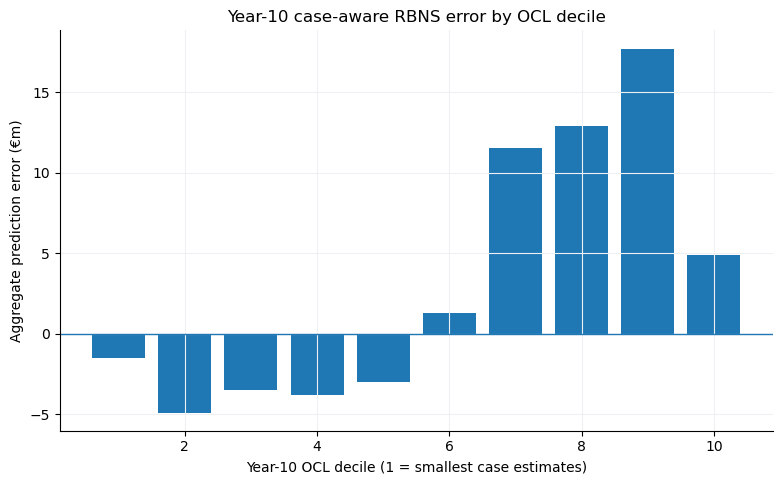

In [89]:
# CELL 88 · §28 · diagnostic graph

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING and RUN_YEAR10_DIAGNOSTIC:
    assert len(train10) == 3380 and np.isclose(smear10, 2.022, atol=0.001), "Run Cell 86 successfully first."
    fig, ax = plt.subplots(figsize=(9.2,5.2))
    ax.bar(dec10['OCL_decile'], dec10['error']/1e6)
    ax.axhline(0, linewidth=1)
    ax.set_xlabel('Year-10 OCL decile (1 = smallest case estimates)')
    ax.set_ylabel('Aggregate prediction error (€m)')
    ax.set_title('Year-10 case-aware RBNS error by OCL decile')
    plt.show()
else:
    print("Skipped §28.3")


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>28.4 · How to read the diagnostic</h2>
<p>If a few claims or one/two OCL deciles account for most of the positive error, the year-10 miss is primarily a
<strong>tail/composition problem</strong>: a stable global retransformation factor is being applied to a particular
open-claim mix whose realised future differs from the historical residual distribution.</p>

<p>If instead most deciles overshoot by similar proportions and the error is diffuse, the evidence points more strongly
to a <strong>global retransformation-level mismatch</strong> at year 10. Either result is scientifically useful. No
diagnostic in this section is used to refit the reported year-10 estimate.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§29 · Where does year-10 miscalibration enter: mean function or retransformation?</h2>
<p>Section §28 established that the year-10 error is diffuse and strongly dependent on OCL region. That evidence does
<strong>not</strong> by itself identify the mechanism. Two different failures can produce the same euro-scale pattern.</p>

<ul>
<li><strong>Mean-function misspecification:</strong> the fitted log-scale mean <code>m(X)</code> is too low in some
regions and too high in others.</li>
<li><strong>Retransformation heterogeneity:</strong> the log-scale mean is adequate, but
<code>E[exp(ε) | X]</code> varies across claim states, so one global Duan factor is insufficient.</li>
</ul>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
rᵢ = log(1 + Yᵢ) − m̂(Xᵢ)
</div>

<p>We therefore examine the frozen year-10 model on the <strong>log scale before smearing</strong>. This is a diagnostic,
not a refit.</p>
</div>


In [90]:
# CELL 89 · §29 · compute year-10 log-scale residuals from the frozen model

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING and RUN_LOG_RESIDUAL_DIAGNOSTIC:

    # §29 is valid only after §28 reproduced the exact year-10 model.
    assert len(train10) == 3380
    assert np.isclose(smear10, 2.022, atol=0.001)

    z10 = add_stable_case_features(test10)
    X10 = z10[['log_OCL','log_paid','claim_age','report_age']]

    # Frozen model prediction on the transformed scale.
    test10['pred_log'] = model10.predict(X10)

    # Observed future cost is validation truth only.
    test10['actual_log'] = np.log1p(
        np.maximum(test10['future_cost'].to_numpy(), 0.0)
    )

    test10['log_resid'] = (
        test10['actual_log'] - test10['pred_log']
    )

    test10['exp_log_resid'] = np.exp(test10['log_resid'])

    print("Year-10 log-residual diagnostic")
    print(f"claims                         : {len(test10):,}")
    print(f"mean log residual              : {test10['log_resid'].mean():+.4f}")
    print(f"median log residual            : {test10['log_resid'].median():+.4f}")
    print(f"std log residual               : {test10['log_resid'].std():.4f}")
    print(f"mean exp(log residual)         : {test10['exp_log_resid'].mean():.3f}")
    print(f"historical global smear factor : {smear10:.3f}")
else:
    print("Skipped §29.1")


Year-10 log-residual diagnostic
claims                         : 846
mean log residual              : +0.1844
median log residual            : -0.1212
std log residual               : 1.1051
mean exp(log residual)         : 2.328
historical global smear factor : 2.022


In [91]:
# CELL 90 · §29 · log residuals by OCL decile

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING and RUN_LOG_RESIDUAL_DIAGNOSTIC:

    resid_dec10 = (
        test10
        .groupby('OCL_decile', observed=True)
        .agg(
            claims=('log_resid','size'),
            mean_log_resid=('log_resid','mean'),
            median_log_resid=('log_resid','median'),
            sd_log_resid=('log_resid','std'),
            mean_exp_resid=('exp_log_resid','mean'),
            mean_OCL=('OCL','mean'),
            mean_future=('future_cost','mean')
        )
        .reset_index()
    )

    # Compare conditional retransformation need with historical global factor.
    resid_dec10['smear_ratio_vs_global'] = (
        resid_dec10['mean_exp_resid'] / smear10
    )

    print("Year-10 residual structure by OCL decile")
    print()
    print(
        resid_dec10.round({
            'mean_log_resid':3,
            'median_log_resid':3,
            'sd_log_resid':3,
            'mean_exp_resid':3,
            'mean_OCL':0,
            'mean_future':0,
            'smear_ratio_vs_global':3
        }).to_string(index=False)
    )
else:
    print("Skipped §29.2")


Year-10 residual structure by OCL decile

 OCL_decile  claims  mean_log_resid  median_log_resid  sd_log_resid  mean_exp_resid  mean_OCL  mean_future  smear_ratio_vs_global
          1      85          -0.273            -1.186         1.831           3.428    3330.0      47865.0                  1.695
          2      85           0.623             1.094         1.390           4.188    9668.0     107789.0                  2.071
          3      84           0.435            -0.003         1.236           3.161   17282.0     115972.0                  1.563
          4      85           0.407             0.365         1.140           2.868   27403.0     149659.0                  1.419
          5      84           0.423             0.081         1.018           2.504   41570.0     181605.0                  1.239
          6      85           0.101            -0.353         0.910           1.856   59836.0     179486.0                  0.918
          7      84          -0.252            -

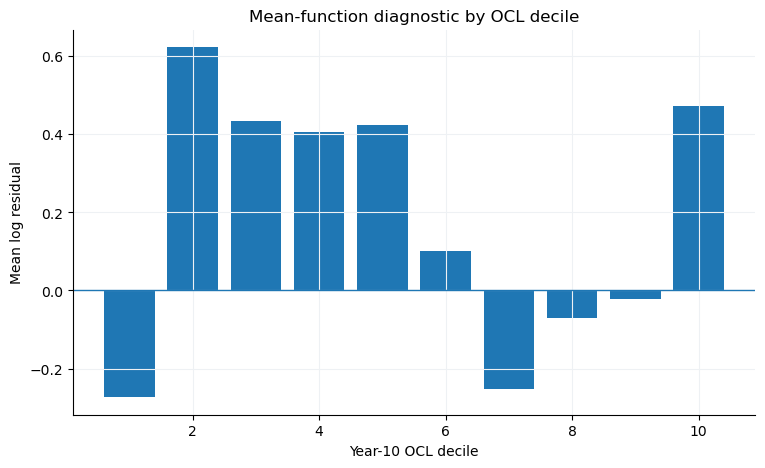

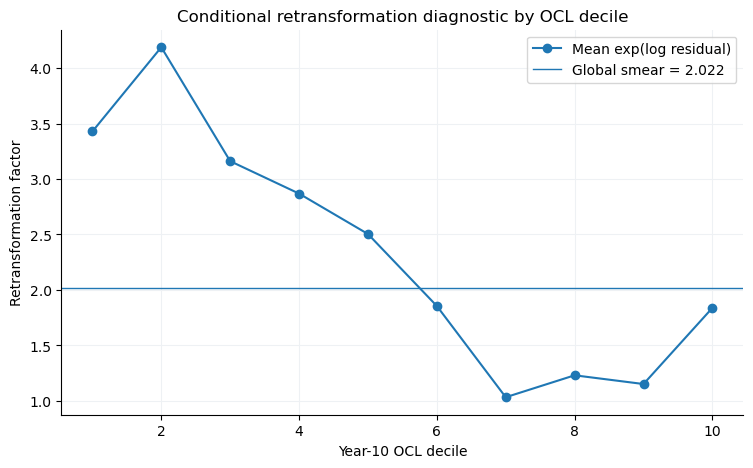

Mechanism summary
mean |decile mean log residual| : 0.308
SD of decile mean exp residual  : 1.075

Interpretation:
  • systematic non-zero mean log residuals by decile -> mean-function misspecification
  • near-zero mean log residuals but varying mean exp residuals -> retransformation heterogeneity
  • both patterns -> both mechanisms matter


In [92]:
# CELL 91 · §29 · diagnostic plots and mechanism summary

if RUN_CASE_ESTIMATE_STUDY and RUN_OCL_SMEARING and RUN_LOG_RESIDUAL_DIAGNOSTIC:

    # Plot 1: mean log residual by OCL decile.
    fig, ax = plt.subplots(figsize=(8.8,5.0))
    ax.bar(resid_dec10['OCL_decile'], resid_dec10['mean_log_resid'])
    ax.axhline(0, linewidth=1)
    ax.set_xlabel('Year-10 OCL decile')
    ax.set_ylabel('Mean log residual')
    ax.set_title('Mean-function diagnostic by OCL decile')
    plt.show()

    # Plot 2: conditional smearing need versus global factor.
    fig, ax = plt.subplots(figsize=(8.8,5.0))
    ax.plot(
        resid_dec10['OCL_decile'],
        resid_dec10['mean_exp_resid'],
        marker='o',
        label='Mean exp(log residual)'
    )
    ax.axhline(smear10, linewidth=1, label=f'Global smear = {smear10:.3f}')
    ax.set_xlabel('Year-10 OCL decile')
    ax.set_ylabel('Retransformation factor')
    ax.set_title('Conditional retransformation diagnostic by OCL decile')
    ax.legend()
    plt.show()

    # Compact interpretation aid.
    mean_abs_log_bias = resid_dec10['mean_log_resid'].abs().mean()
    smear_dispersion = resid_dec10['mean_exp_resid'].std()

    print("Mechanism summary")
    print(f"mean |decile mean log residual| : {mean_abs_log_bias:.3f}")
    print(f"SD of decile mean exp residual  : {smear_dispersion:.3f}")
    print()
    print("Interpretation:")
    print("  • systematic non-zero mean log residuals by decile -> mean-function misspecification")
    print("  • near-zero mean log residuals but varying mean exp residuals -> retransformation heterogeneity")
    print("  • both patterns -> both mechanisms matter")
else:
    print("Skipped §29.3")


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>29.4 · Interpretation discipline</h2>
<p>This section does not select a new model. It only determines where the frozen specification fails.</p>

<ul>
<li>If the log residual means are systematically positive at low OCL and negative at high OCL, the conditional
mean function itself is too steep or otherwise misspecified.</li>
<li>If log residual means are close to zero but <code>mean exp(residual)</code> varies materially across deciles,
conditional retransformation is the main issue.</li>
<li>If both occur, future work should distinguish modelling the conditional mean from modelling the conditional
retransformation factor rather than treating “smearing” as a single remedy.</li>
</ul>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>§30 · Does OCL add information beyond what the paid-only model already knows?</h2>
<p>The earlier comparison established that OCL is strongly associated with future RBNS. That raw association is not,
however, a clean measure of <em>incremental</em> information: OCL is itself related to claim age, reporting age and
paid-to-date.</p>

<p>This final diagnostic therefore uses an added-variable / partial-correlation construction. At each common-window
valuation date, current OCL is first predicted from the same paid-state features available to the paid-only benchmark.
The residual component of OCL is denoted <strong>OCL⊥</strong>: the part of the case estimate not explained by those
paid features.</p>

<div style="background-color:#FFF4D6 !important;border:1px solid #D9C18D !important;border-radius:7px !important;padding:9px 12px !important;margin:10px auto !important;text-align:center !important;font-family:Georgia,'Times New Roman',serif !important;font-size:1.08em !important;max-width:92% !important;">
OCL⊥ = log(1 + OCL) − E[log(1 + OCL) | paid-state features]
</div>

<p>We then ask whether OCL⊥ predicts errors of the frozen paid-only model. This is an information diagnostic only.
It neither changes the paid model nor feeds OCL back into a new reserving model.</p>
</div>


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>30.1 · Two channels: level and uncertainty</h2>
<p>Two error channels are separated.</p>
<ul>
<li><strong>Mean / level channel.</strong> Signed paid-only residuals are centred within valuation date before testing
incremental OCL. This removes the date-level under-reserving bias from the diagnostic target.</li>
<li><strong>Dispersion / uncertainty channel.</strong> We examine the magnitude of that centred residual. This asks
whether incremental OCL predicts how difficult the claim is to forecast.</li>
</ul>
<p>The uncertainty channel is the cleaner test of the hypothesis that the case estimate carries information about
predictability, because it is less contaminated by the known level bias of the paid-only benchmark.</p>
</div>


In [93]:
# CELL 92 · §30 · build out-of-time incremental-information panel

if RUN_CASE_ESTIMATE_STUDY and RUN_INCREMENTAL_OCL_INFO:

    from sklearn.linear_model import LinearRegression
    from scipy import stats

    INFO_DATES = [28.0, 32.0, 36.0, 40.0]
    info_parts = []

    for T_star in INFO_DATES:

        train_dates = [
            s for s in [16.0, 20.0, 24.0, 28.0, 32.0]
            if s <= T_star - 8.0
        ]

        parts = []
        for s in train_dates:
            d = open_case_table(s).copy()

            status_horizon, _, _, _, _, _ = make_truth_at(T_star)
            closed = (
                status_horizon
                .set_index('claim_no')['closure_time']
                <= T_star
            )

            d = d[
                d.index.isin(closed[closed].index)
            ].copy()

            parts.append(d)

        train = pd.concat(parts, axis=0)
        test = open_case_table(T_star).copy()

        paid_features = [
            'claim_age',
            'report_age',
            'paid_to_date'
        ]

        paid_model = make_pipeline(
            StandardScaler(),
            GammaRegressor(alpha=0.20, max_iter=5000)
        )

        paid_model.fit(
            train[paid_features],
            np.maximum(train['future_cost'].to_numpy(), 1.0)
        )

        test['paid_prediction'] = paid_model.predict(
            test[paid_features]
        )

        test['paid_residual'] = (
            test['future_cost']
            - test['paid_prediction']
        )

        train_r = train.copy()
        test_r = test.copy()

        train_r['log_paid'] = np.log1p(
            np.maximum(train_r['paid_to_date'], 0.0)
        )
        test_r['log_paid'] = np.log1p(
            np.maximum(test_r['paid_to_date'], 0.0)
        )

        train_r['log_OCL'] = np.log1p(
            np.maximum(train_r['OCL'], 0.0)
        )
        test_r['log_OCL'] = np.log1p(
            np.maximum(test_r['OCL'], 0.0)
        )

        residualise_features = [
            'claim_age',
            'report_age',
            'log_paid'
        ]

        ocl_projection = make_pipeline(
            StandardScaler(),
            LinearRegression()
        )

        ocl_projection.fit(
            train_r[residualise_features],
            train_r['log_OCL']
        )

        expected_log_ocl = ocl_projection.predict(
            test_r[residualise_features]
        )

        test['OCL_perp'] = (
            test_r['log_OCL'].to_numpy()
            - expected_log_ocl
        )

        out = (
            test
            .reset_index()
            [[
                'claim_no',
                'future_cost',
                'paid_prediction',
                'paid_residual',
                'OCL',
                'OCL_perp',
                'claim_age',
                'report_age',
                'paid_to_date'
            ]]
            .copy()
        )

        out['T_years'] = T_star / 4
        out['n_train'] = len(train)

        info_parts.append(out)

    incremental_info = pd.concat(
        info_parts,
        ignore_index=True
    )

    incremental_info['signed_resid_debiased'] = (
        incremental_info['paid_residual']
        - incremental_info.groupby('T_years')['paid_residual'].transform('mean')
    )

    incremental_info['abs_resid_debiased'] = (
        incremental_info['signed_resid_debiased'].abs()
    )

    incremental_info['log_abs_resid'] = np.log1p(
        incremental_info['abs_resid_debiased']
    )

    print("Incremental-information panel")
    print(f"rows / open-claim states : {len(incremental_info):,}")
    print(f"valuation dates          : {sorted(incremental_info['T_years'].unique())}")
    print()
    print(
        incremental_info.groupby('T_years')
        .agg(
            claims=('claim_no','size'),
            mean_paid_residual=('paid_residual','mean'),
            sd_OCL_perp=('OCL_perp','std'),
            mean_abs_debiased_error=('abs_resid_debiased','mean')
        )
        .round({
            'mean_paid_residual':0,
            'sd_OCL_perp':3,
            'mean_abs_debiased_error':0
        })
        .to_string()
    )

else:
    print("Skipped §30.1")


Incremental-information panel
rows / open-claim states : 3,316
valuation dates          : [np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]

         claims  mean_paid_residual  sd_OCL_perp  mean_abs_debiased_error
T_years                                                                  
7.0         847             48777.0        1.511                 200055.0
8.0         824             54292.0        1.431                 185971.0
9.0         799             49922.0        1.429                 187035.0
10.0        846             17352.0        1.437                 171834.0


In [94]:
# CELL 93 · §30 · partial association: level and uncertainty channels

if RUN_CASE_ESTIMATE_STUDY and RUN_INCREMENTAL_OCL_INFO:

    def diagnostic_stats(d, target):
        x = d['OCL_perp'].to_numpy()
        y = d[target].to_numpy()

        pearson = stats.pearsonr(x, y).statistic
        spearman = stats.spearmanr(x, y).statistic

        lm = LinearRegression().fit(
            x.reshape(-1, 1),
            y
        )

        return {
            'Pearson_partial': pearson,
            'Spearman_partial': spearman,
            'partial_R2_linear': lm.score(
                x.reshape(-1, 1),
                y
            )
        }

    rows = []

    for label, target in [
        ('Signed residual, date-debiased', 'signed_resid_debiased'),
        ('Error magnitude, log scale', 'log_abs_resid')
    ]:
        result = diagnostic_stats(
            incremental_info,
            target
        )
        rows.append({
            'scope': 'pooled years 7-10',
            'channel': label,
            **result
        })

    for year, d in incremental_info.groupby('T_years'):
        for label, target in [
            ('Signed residual, date-debiased', 'signed_resid_debiased'),
            ('Error magnitude, log scale', 'log_abs_resid')
        ]:
            result = diagnostic_stats(d, target)
            rows.append({
                'scope': f'year {year:g}',
                'channel': label,
                **result
            })

    partial_info_score = pd.DataFrame(rows)

    print("Incremental OCL information after partialling out paid-state features")
    print()
    print(
        partial_info_score.round({
            'Pearson_partial':3,
            'Spearman_partial':3,
            'partial_R2_linear':3
        }).to_string(index=False)
    )

else:
    print("Skipped §30.2")


Incremental OCL information after partialling out paid-state features

            scope                        channel  Pearson_partial  Spearman_partial  partial_R2_linear
pooled years 7-10 Signed residual, date-debiased            0.384             0.544              0.147
pooled years 7-10     Error magnitude, log scale           -0.031            -0.147              0.001
           year 7 Signed residual, date-debiased            0.296             0.557              0.087
           year 7     Error magnitude, log scale           -0.067            -0.186              0.004
           year 8 Signed residual, date-debiased            0.440             0.546              0.194
           year 8     Error magnitude, log scale           -0.024            -0.166              0.001
           year 9 Signed residual, date-debiased            0.451             0.534              0.204
           year 9     Error magnitude, log scale           -0.008            -0.106              0.000
  

<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>30.2 · Reading partial R² correctly</h2>
<p>Because OCL⊥ is the residual component of OCL after projection on the paid-state features, its linear association
with a diagnostic target is an added-variable measure. The reported <strong>partial R²</strong> is descriptive: it is
the fraction of variation in that target explained by a one-variable linear projection on OCL⊥.</p>

<p>A small partial R² can coexist with a meaningful monotone relationship, hence Pearson and Spearman partial
correlations are reported together. These are descriptive measurements from one correlated synthetic portfolio,
not inferential estimates.</p>
</div>


In [95]:
# CELL 94 · §30 · binned incremental-information table

if RUN_CASE_ESTIMATE_STUDY and RUN_INCREMENTAL_OCL_INFO:

    d = incremental_info.copy()

    d['OCL_perp_decile'] = pd.qcut(
        d['OCL_perp'].rank(method='first'),
        10,
        labels=False
    ) + 1

    info_deciles = (
        d.groupby('OCL_perp_decile', observed=True)
        .agg(
            claims=('claim_no','size'),
            mean_OCL_perp=('OCL_perp','mean'),
            mean_signed_error=('signed_resid_debiased','mean'),
            mean_abs_error=('abs_resid_debiased','mean'),
            median_abs_error=('abs_resid_debiased','median')
        )
        .reset_index()
    )

    print("Incremental OCL signal by OCL⊥ decile — pooled years 7–10")
    print()
    print(
        info_deciles.round({
            'mean_OCL_perp':3,
            'mean_signed_error':0,
            'mean_abs_error':0,
            'median_abs_error':0
        }).to_string(index=False)
    )

else:
    print("Skipped §30.3")


Incremental OCL signal by OCL⊥ decile — pooled years 7–10

 OCL_perp_decile  claims  mean_OCL_perp  mean_signed_error  mean_abs_error  median_abs_error
               1     332         -2.977          -184086.0        200237.0          193052.0
               2     332         -1.535          -122432.0        168806.0          159193.0
               3     331         -0.812           -52811.0        156321.0          148051.0
               4     332         -0.343           -52044.0        158900.0          152819.0
               5     331          0.031           -39419.0        198744.0          152094.0
               6     332          0.348           -27002.0        144254.0          133749.0
               7     331          0.666             5798.0        158808.0          115848.0
               8     332          1.002            22686.0        149028.0           99214.0
               9     331          1.396           122987.0        185158.0           76517.0
           

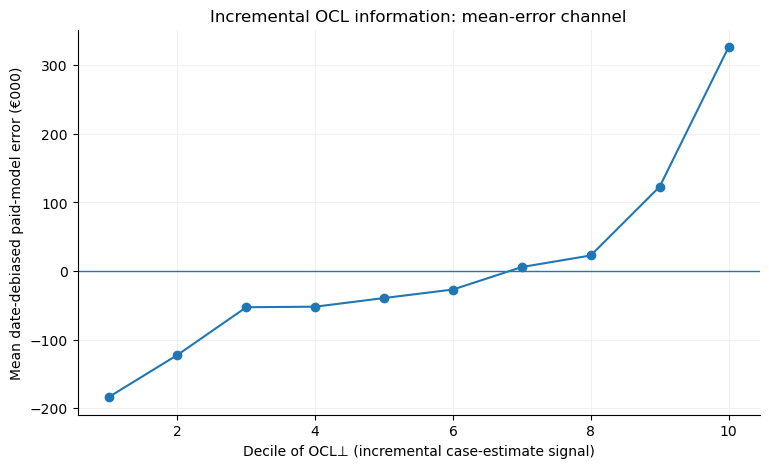

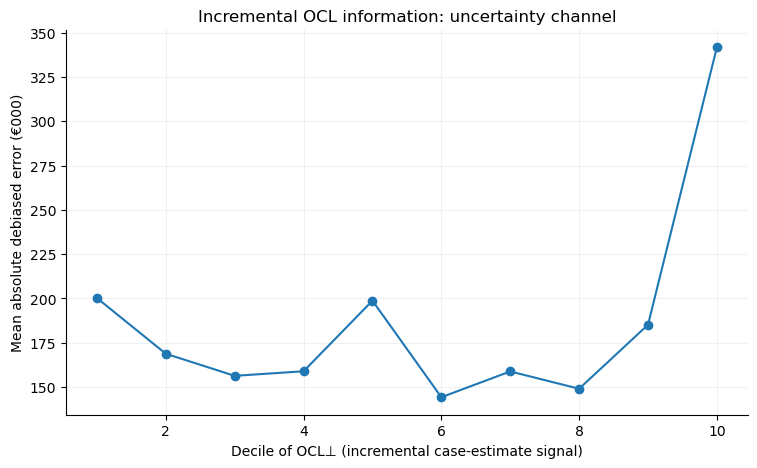

In [96]:
# CELL 95 · §30 · explanatory figures

if RUN_CASE_ESTIMATE_STUDY and RUN_INCREMENTAL_OCL_INFO:

    fig, ax = plt.subplots(figsize=(8.8,5.0))
    ax.plot(
        info_deciles['OCL_perp_decile'],
        info_deciles['mean_signed_error'] / 1e3,
        marker='o'
    )
    ax.axhline(0, linewidth=1)
    ax.set_xlabel('Decile of OCL⊥ (incremental case-estimate signal)')
    ax.set_ylabel('Mean date-debiased paid-model error (€000)')
    ax.set_title('Incremental OCL information: mean-error channel')
    plt.show()

    fig, ax = plt.subplots(figsize=(8.8,5.0))
    ax.plot(
        info_deciles['OCL_perp_decile'],
        info_deciles['mean_abs_error'] / 1e3,
        marker='o'
    )
    ax.set_xlabel('Decile of OCL⊥ (incremental case-estimate signal)')
    ax.set_ylabel('Mean absolute debiased error (€000)')
    ax.set_title('Incremental OCL information: uncertainty channel')
    plt.show()

else:
    print("Skipped §30.4")


<div style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h2 style='color:#253746;margin-top:0'>30.3 · What this diagnostic can and cannot claim</h2>
<p>The clean measurable question is <strong>F<sub>P</sub> → F<sub>C</sub></strong>: does the individual case estimate
add information beyond the paid-state information already available to the paid-only model?</p>

<p>The experiment does not assign a numerical “information loss” to the subsequent move from claim-level data to a
development triangle. That move changes both the information set and the modelling method, so a single number would
conflate aggregation loss with model-class differences.</p>

<p>If OCL⊥ is associated with paid-model error magnitude, the defensible conceptual conclusion is that the case estimate
contains incremental information about <strong>predictability/uncertainty</strong>, not merely claim level. The
signed-error channel is interpreted more cautiously because the paid-only model has known structural level issues.</p>

<p>No model is fitted to exploit this diagnostic. Nonlinear mean functions, distributional regression/GAMLSS,
conditional smearing, boosting and similar performance-oriented extensions are explicitly reserved for fresh data.</p>
</div>


<div class="phnx-card" style="background-color:#F3E3BF !important;border:1px solid #D6BE91 !important;border-left:6px solid #A86F44 !important;border-radius:10px !important;padding:15px 19px 13px 19px !important;margin:10px 0 17px 0 !important;line-height:1.55 !important;color:#2B2B2B !important;">
<h3>Reproducibility note</h3>
<p>The CSV is a frozen export of the SynthETIC 1.1.1 standard example. Its default <code>time_unit = 1/4</code>, so the 40 occurrence
periods represent ten calendar years. Keeping the CSV beside the notebook makes the Python analysis reproducible without
requiring R at run time. The original <code>.rds</code> claims object can be retained as provenance but is not read by this notebook.</p>

</div>